In [1]:
# Основные библиотеки
import numpy as np
import matplotlib.pyplot as plt
import random

# PyTorch
import torch
from torch import nn
from torch.functional import F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

# Обработка данных
import polars as pl
import os
from PIL import Image
from pathlib import Path

# Метрики
from sklearn.metrics import normalized_mutual_info_score

# Прогресс-бары
from tqdm.notebook import tqdm

# Загрузка датасетов
import kagglehub

import torch
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

## Загрузка датасета EuroSAT

In [2]:
# Download latest version
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print("Path to dataset files:", path)
img_path = os.path.join(path, "EuroSAT")

Path to dataset files: /home/mihalko711/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6


## Создание Dataset класса

In [3]:
class EuroSATDataset(Dataset):
    def __init__(self, csv_path, image_root, filt_class=None, return_label=False):
        self.df = pl.read_csv(csv_path).drop(pl.read_csv(csv_path).columns[0])
        self.image_root = Path(image_root)
        self.return_label = return_label

        self.transform = T.Compose([
            T.Resize((64, 64)),  # Гарантируем размер 64x64
            T.ToTensor(),        # Переводит [0, 255] -> [0.0, 1.0]
            T.Normalize(
                mean=[0.5, 0.5, 0.5], # (x - 0.5) / 0.5
                std=[0.5, 0.5, 0.5]   # Результат: [-1.0, 1.0]
            )
        ])

        if filt_class is not None:
            self.df = self.df.filter(pl.col("Label")==filt_class)
            
    def __len__(self):
        return self.df.height

    def __getitem__(self, idx):
        row = self.df.row(idx, named=True)

        img_path = self.image_root / row["Filename"]
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        if self.return_label:
            return image, row["Label"], row["ClassName"]

        return image

## Создание датасетов

In [4]:
# Создаем тренировочный и валидационный датасеты
train_dataset = EuroSATDataset(
    csv_path=os.path.join(img_path, "train.csv"),
    image_root=os.path.join(img_path),
    return_label=True
)

val_dataset = EuroSATDataset(
    csv_path=os.path.join(img_path, "validation.csv"),
    image_root=os.path.join(img_path),
    return_label=True
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 18900
Validation dataset size: 5400


## Демонстрация изображений

Image shape: torch.Size([3, 64, 64])
Label: 4 (Industrial)


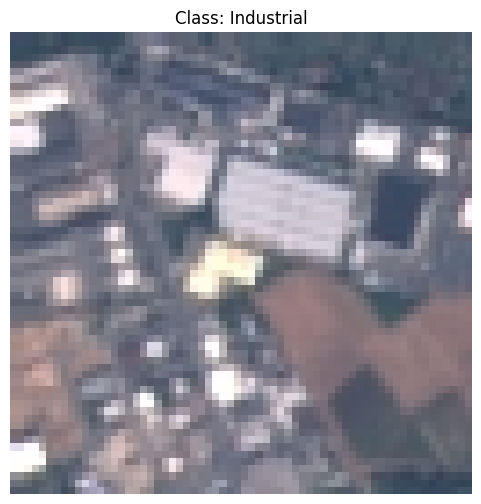

In [5]:
# Показываем случайное изображение из тренировочного датасета
idx = np.random.randint(len(train_dataset))
x, label, name = train_dataset[idx]

print(f"Image shape: {x.shape}")
print(f"Label: {label} ({name})")

# Денормализация для отображения
img_display = x.permute(1, 2, 0) * 0.5 + 0.5
plt.figure(figsize=(6, 6))
plt.imshow(img_display)
plt.title(f"Class: {name}")
plt.axis('off')
plt.show()

## Просмотр примеров по классам

Classes in dataset: shape: (10,)
Series: 'ClassName' [str]
[
	"PermanentCrop"
	"SeaLake"
	"AnnualCrop"
	"Residential"
	"Pasture"
	"River"
	"Highway"
	"Forest"
	"Industrial"
	"HerbaceousVegetation"
]


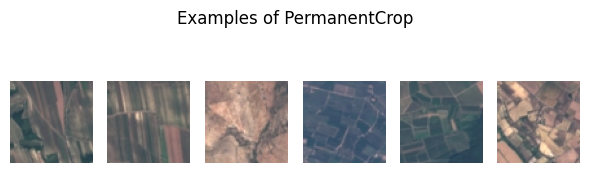

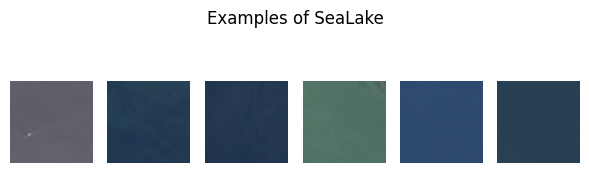

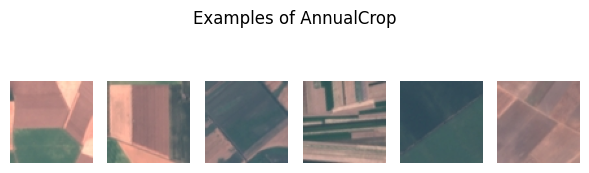

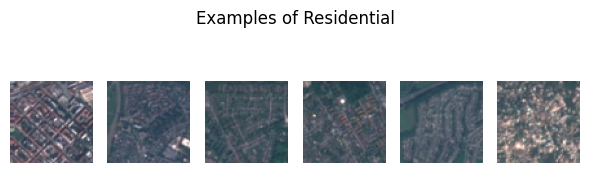

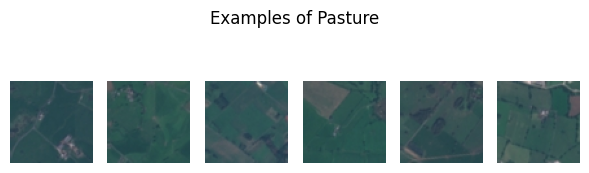

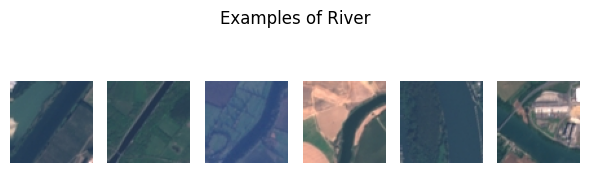

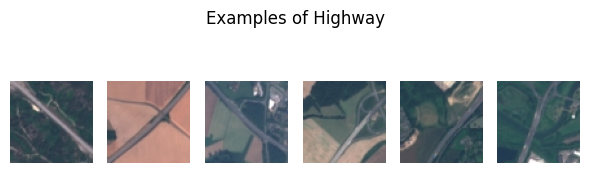

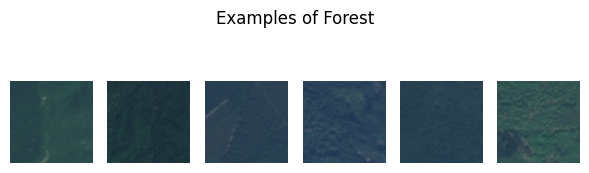

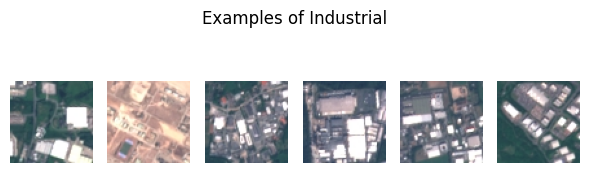

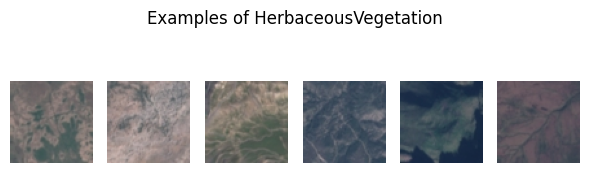

In [6]:
def plot_n_rand_class(dataset, class_name, n=8):
    """Показывает n случайных изображений указанного класса"""
    idxs = dataset.df \
        .with_columns(
            pl.arange(0, pl.len()).alias("idx")
        ) \
        .filter(
            pl.col("ClassName") == class_name
        ) \
        .select("idx").to_numpy().ravel()
    
    n_rand_idxs = np.random.choice(idxs, size=min(n, len(idxs)), replace=False)
    
    fig = plt.figure(figsize=(n, 2))
    fig.suptitle(f"Examples of {class_name}")
    for i, idx in enumerate(n_rand_idxs):
        x, label, class_name = dataset[idx]
        ax = fig.add_subplot(1, len(n_rand_idxs), i + 1)
        ax.imshow(x.permute(1, 2, 0) * 0.5 + 0.5)
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

# Показываем примеры для каждого класса
unique_classes = train_dataset.df["ClassName"].unique()
print(f"Classes in dataset: {unique_classes}")

for class_name in unique_classes:
    plot_n_rand_class(train_dataset, class_name, n=6)

## Статистика датасета

Class distribution:
shape: (10, 2)
┌──────────────────────┬───────┐
│ ClassName            ┆ count │
│ ---                  ┆ ---   │
│ str                  ┆ u32   │
╞══════════════════════╪═══════╡
│ AnnualCrop           ┆ 2100  │
│ Forest               ┆ 2100  │
│ HerbaceousVegetation ┆ 2100  │
│ Highway              ┆ 1750  │
│ Industrial           ┆ 1750  │
│ Pasture              ┆ 1400  │
│ PermanentCrop        ┆ 1750  │
│ Residential          ┆ 2100  │
│ River                ┆ 1750  │
│ SeaLake              ┆ 2100  │
└──────────────────────┴───────┘


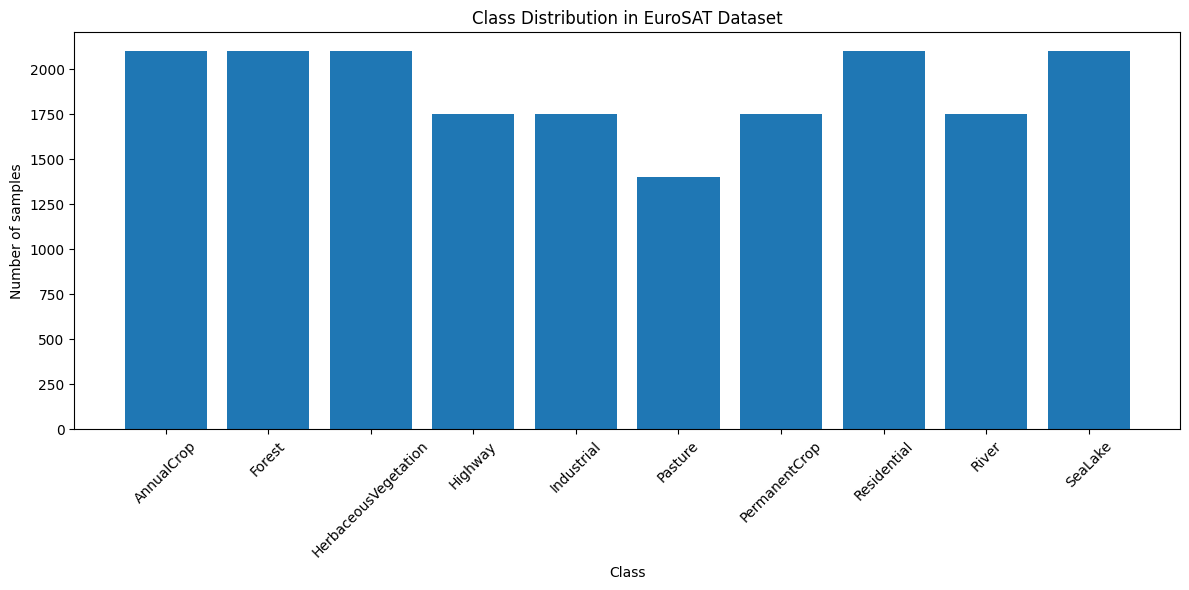

In [7]:
# Анализ распределения классов
class_counts = train_dataset.df["ClassName"].value_counts().sort("ClassName")
print("Class distribution:")
print(class_counts)

# Визуализация распределения
plt.figure(figsize=(12, 6))
plt.bar(class_counts["ClassName"], class_counts["count"])
plt.title("Class Distribution in EuroSAT Dataset")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Class distribution:
shape: (10, 2)
┌──────────────────────┬───────┐
│ ClassName            ┆ count │
│ ---                  ┆ ---   │
│ str                  ┆ u32   │
╞══════════════════════╪═══════╡
│ AnnualCrop           ┆ 600   │
│ Forest               ┆ 600   │
│ HerbaceousVegetation ┆ 600   │
│ Highway              ┆ 500   │
│ Industrial           ┆ 500   │
│ Pasture              ┆ 400   │
│ PermanentCrop        ┆ 500   │
│ Residential          ┆ 600   │
│ River                ┆ 500   │
│ SeaLake              ┆ 600   │
└──────────────────────┴───────┘


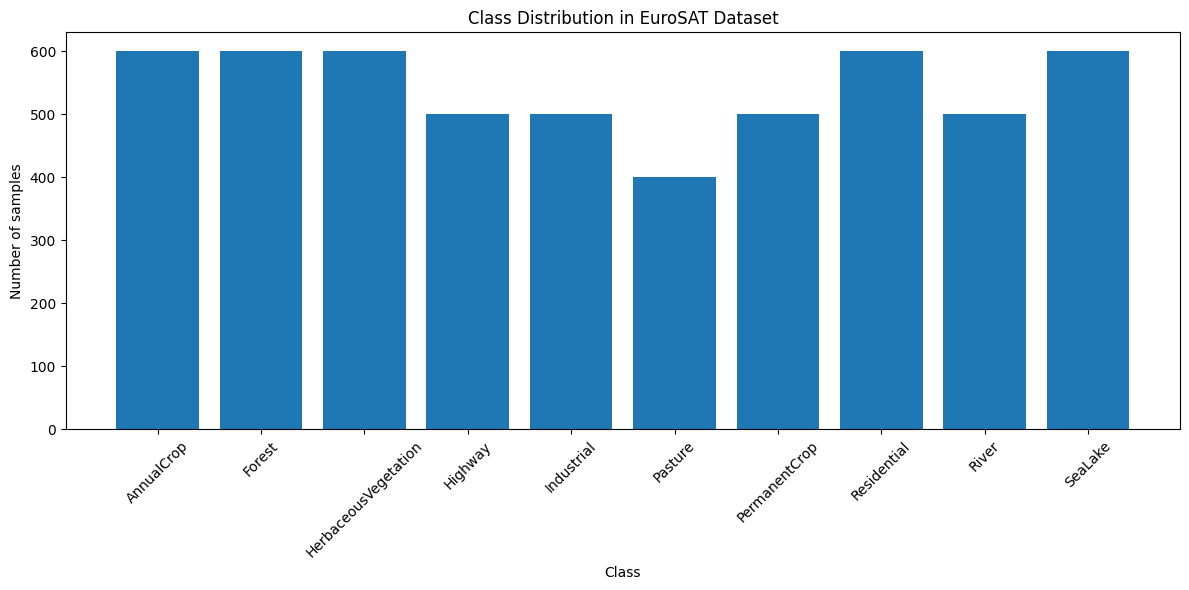

In [8]:
# Анализ распределения классов
class_counts = val_dataset.df["ClassName"].value_counts().sort("ClassName")
print("Class distribution:")
print(class_counts)

# Визуализация распределения
plt.figure(figsize=(12, 6))
plt.bar(class_counts["ClassName"], class_counts["count"])
plt.title("Class Distribution in EuroSAT Dataset")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
class GlobalSpatialSOMLayer(nn.Module):
    def __init__(self, grid_h, grid_w, channels, latent_h, latent_w):
        super().__init__()
        self.grid_h = grid_h
        self.grid_w = grid_w
        self.c, self.h, self.w = channels, latent_h, latent_w
        
        self.template_dim = channels * latent_h * latent_w
        
        self.embeddings = nn.Parameter(
            torch.randn(grid_h * grid_w, self.template_dim)
        )

    def forward(self, z_e):
        batch_size = z_e.size(0)

        z_e_flat = z_e.reshape(batch_size, -1)
        
        z_e_sq = torch.sum(z_e_flat**2, dim=1, keepdim=True)
        emb_sq = torch.sum(self.embeddings**2, dim=1)
        
        distances = (
            z_e_sq
            - 2 * torch.matmul(z_e_flat, self.embeddings.t())
            + emb_sq
        )
        
        indices = torch.argmin(distances, dim=1)
        
        z_q_flat = self.embeddings[indices]

        # FIX 2: reshape вместо view
        z_q = z_q_flat.reshape(batch_size, self.c, self.h, self.w)
        
        return z_q, indices

    def get_neighbors(self, indices):
        row = indices // self.grid_w
        col = indices % self.grid_w
        
        def get_idx(r, c):
            r = torch.clamp(r, 0, self.grid_h - 1)
            c = torch.clamp(c, 0, self.grid_w - 1)
            return r * self.grid_w + c

        return torch.stack([
            get_idx(row-1, col),
            get_idx(row+1, col),
            get_idx(row, col-1),
            get_idx(row, col+1)
        ], dim=1)

    def calc_activations(self, z_e, temperature=0.5):
        batch_size = z_e.size(0)

        # FIX 3: reshape вместо view
        z_e_flat = z_e.reshape(batch_size, -1)
        
        z_e_sq = torch.sum(z_e_flat**2, dim=1, keepdim=True)
        emb_sq = torch.sum(self.embeddings**2, dim=1)
        
        distances = (
            z_e_sq
            - 2 * torch.matmul(z_e_flat, self.embeddings.t())
            + emb_sq
        )
        
        # Softmax по отрицательным расстояниям = вероятности близости
        activations = torch.softmax(-distances / temperature, dim=1)
        return activations


## Model class

In [10]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import Resize

class EuroSAT_ResNet18_Simple(nn.Module):
    def __init__(
        self,
        latent_dim=64,          # размерность канала латентного пространства
        som_grid=(8, 8),        # размер SOM-сетки
        freeze_backbone=True,   # заморозить предобученные слои
        input_size=64,          # исходный размер изображения
        backbone_size=224       # размер для предобученного бэкбона
    ):
        super().__init__()
        self.input_size = input_size
        self.backbone_size = backbone_size
        self.resize_in = Resize((backbone_size, backbone_size))
        self.resize_out = Resize((input_size, input_size))

        # -----------------------------
        # 1. Предобученный ResNet18 (без fc и avgpool)
        # -----------------------------
        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.encoder = nn.Sequential(*list(backbone.children())[:-2])  # до [B, 512, 7, 7]
        
        if freeze_backbone:
            for p in self.encoder.parameters():
                p.requires_grad = False

        # -----------------------------
        # 2. Простая голова: 3×3 свёртка → латентное пространство
        # -----------------------------
        self.proj_head = nn.Conv2d(512, latent_dim, kernel_size=3, padding=1)  # [B, 512, 7, 7] → [B, C, 7, 7]

        # -----------------------------
        # 3. SOM слой (предполагается, что он у тебя уже есть)
        # -----------------------------
        self.som = GlobalSpatialSOMLayer(
            som_grid[0], som_grid[1], latent_dim, 7, 7
        )

        # -----------------------------
        # 4. Простой декодер: 3 транспонированных свёртки
        # -----------------------------
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, 4, stride=2, padding=1),  # 7→14
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),           # 14→28
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),            # 28→56
            nn.ReLU(),
            nn.Conv2d(32, 3, 9, padding=4),                                # 56→56 (затем ресайз до 64)
            nn.Tanh()
        )

    def encode(self, x):
        x = self.resize_in(x)          # [B, 3, 64, 64] → [B, 3, 224, 224]
        z = self.encoder(x)            # [B, 512, 7, 7]
        z_e = self.proj_head(z)        # [B, C, 7, 7]
        return z_e

    def decode(self, z):
        x_hat = self.decoder(z)        # [B, 3, 56, 56]
        return self.resize_out(x_hat)  # [B, 3, 64, 64]

    def forward(self, x):
        z_e = self.encode(x)
        z_q, indices = self.som(z_e)
        x_hat_e = self.decode(z_e)
        x_hat_q = self.decode(z_q)
        return x_hat_e, x_hat_q, z_e, z_q, indices

In [11]:
def som_vae_loss(x, x_hat_e, x_hat_q, z_e, z_q, indices, som_layer, 
                 alpha=1.0, beta=1.0, gamma=1.0):

    # 1. Reconstruction Loss
    l_rec_e = F.mse_loss(x_hat_e, x)
    l_rec_q = F.mse_loss(x_hat_q, x)
    l_reconstruction = l_rec_e + l_rec_q

    # 2. Commitment Loss
    l_commitment = F.mse_loss(z_e, z_q)

    # 3. SOM loss (neighbor consistency)
    neighbor_indices = som_layer.get_neighbors(indices)          # [B, 4]
    neighbors = som_layer.embeddings[neighbor_indices]          # [B, 4, D]

    z_e_flat = z_e.detach().reshape(z_e.shape[0], -1)           # [B, D]
    z_e_target = z_e_flat.unsqueeze(1)                          # [B, 1, D]

    l_som = torch.mean((neighbors - z_e_target) ** 2)

    total_loss = (
        l_reconstruction
        + alpha * l_commitment
        + beta * l_som
    )

    return total_loss, l_reconstruction, l_commitment, l_som


## Training Functions

In [12]:
def visualize_som_sample(model, dataset, device="cuda"):
    model.eval()

    # --- 1. Случайный пример ---
    idx = random.randint(0, len(dataset) - 1)

    sample = dataset[idx]
    if isinstance(sample, tuple):
        x = sample[0]
        label = sample[1] if len(sample) > 1 else None
    else:
        x = sample
        label = None

    x = x.unsqueeze(0).to(device)

    # --- 2. Прогон через модель ---
    with torch.no_grad():
        x_hat_e, x_hat_q, z_e, z_q, indices = model(x)

    # --- 3. Активации SOM ---
    activations = model.som.calc_activations(z_e)  # [1, K]
    grid_h, grid_w = model.som.grid_h, model.som.grid_w
    act_map = activations[0].reshape(grid_h, grid_w).cpu()  # <-- заменили view на reshape

    winner = indices[0].item()
    win_r = winner // grid_w
    win_c = winner % grid_w

    # --- 4. Победивший embedding ---
    emb = model.som.embeddings[winner]  # [C*H*W]
    emb = emb.reshape(1, model.som.c, model.som.h, model.som.w)  # <-- заменили view на reshape

    with torch.no_grad():
        winner_recon = model.decode(emb.to(device)).cpu()

    # --- 5. Денормализация ---
    def denorm(img):
        img = img.squeeze().permute(1, 2, 0)
        img = img * 0.5 + 0.5
        return img.clamp(0, 1)

    x = denorm(x.cpu())
    x_hat_e = denorm(x_hat_e.cpu())
    x_hat_q = denorm(x_hat_q.cpu())
    winner_recon = denorm(winner_recon)

    # --- 6. Визуализация ---
    fig, axs = plt.subplots(2, 3, figsize=(13, 9))

    axs[0, 0].imshow(x)
    axs[0, 0].set_title("Original")

    axs[0, 1].imshow(x_hat_e)
    axs[0, 1].set_title("Recon (z_e)")

    axs[0, 2].imshow(x_hat_q)
    axs[0, 2].set_title("Recon (z_q)")

    im = axs[1, 0].imshow(act_map.detach().cpu(), cmap="viridis")
    axs[1, 0].scatter(win_c, win_r, c="red", s=80)
    axs[1, 0].set_title("SOM activation map")
    plt.colorbar(im, ax=axs[1, 0], fraction=0.046)

    axs[1, 1].imshow(winner_recon)
    axs[1, 1].set_title("Winner node recon")

    axs[1, 2].axis("off")

    for ax in axs.flat:
        ax.axis("off")

    title = f"Sample #{idx}"
    if label is not None:
        title += f" | Label: {label}"
    plt.suptitle(title)

    plt.tight_layout()
    plt.show()

In [13]:
def train_som_vae(model, train_dataset, val_dataset, optimizer, device, 
                  epochs=50, batch_size=128, alpha=1.0, beta=1.0):
    """
    Обучение SOM-VAE модели
    """
    train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size)
    
    # История обучения для визуализации
    history = {
        'train_loss': [], 'val_loss': [], 'nmi': []
    }
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = {'total': 0, 'rec': 0, 'comm': 0, 'som': 0}
        train_correct = 0
        train_total = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]")
        
        for data, labels, _ in pbar:
            data, labels = data.to(device), labels.to(device)
            optimizer.zero_grad()
            
            # Прямой проход
            x_hat_e, x_hat_q, z_e, z_q, indices = model(data)
            
            # Расчет лосса
            loss, l_rec, l_comm, l_som = som_vae_loss(
                data, x_hat_e, x_hat_q, z_e, z_q, indices, model.som,
                alpha=alpha, beta=beta
            )
            
            loss.backward()
            optimizer.step()
            
            # Накопление лоссов
            train_losses['total'] += loss.item()
            train_losses['rec'] += l_rec.item()
            train_losses['comm'] += l_comm.item()
            train_losses['som'] += l_som.item()
            
            pbar.set_postfix({
                'L': f"{loss.item():.3f}",
                'Rec': f"{l_rec.item():.3f}",
                'Comm': f"{l_comm.item():.3f}",
                'som': f"{l_som.item():.3f}"
            })

        # --- ФАЗА ВАЛИДАЦИИ ---
        model.eval()
        val_total = 0
        val_total_loss = 0
        all_labels = []
        all_indices = []
        
        with torch.no_grad():
            for data, labels, _ in tqdm(val_loader, desc='Validation', leave=False):
                data, labels = data.to(device), labels.to(device)
                x_hat_e, x_hat_q, z_e, z_q, indices = model(data)
                
                # Расчет лосса для валидации
                loss, _, _, _ = som_vae_loss(
                    data, x_hat_e, x_hat_q, z_e, z_q, indices, model.som,
                    alpha=alpha, beta=beta
                )
                
                val_total_loss += loss.item()

                all_indices.append(indices.cpu().numpy())
                all_labels.append(labels.cpu().numpy())
                
        # Расчет метрик
        flat_indices = np.concatenate(all_indices).ravel()
        flat_labels = np.concatenate(all_labels).ravel()
        current_nmi = normalized_mutual_info_score(flat_labels, flat_indices)
        
        # Сохранение истории
        history['train_loss'].append(train_losses['total'] / len(train_loader))
        history['val_loss'].append(val_total_loss / len(val_loader))
        history['nmi'].append(current_nmi)
        
        tqdm.write(f"Summary Epoch {epoch}:")
        tqdm.write(f"Train: {train_losses['total'] / len(train_loader):.3f} | Val: {val_total_loss / len(val_loader)} | NMI: {current_nmi:.4f}")

        visualize_som_sample(model, train_dataset)
        visualize_som_sample(model, val_dataset)
        
    return history

In [14]:
import torch.nn.functional as F

def restart_som_with_data(model, train_loader, device):
    model.eval()
    with torch.no_grad():
        images, _, _ = next(iter(train_loader))
        # КРИТИЧЕСКИ ВАЖНО: ресайз до размера бэкбона (224), а не исходного (64)!
        images = F.interpolate(images, size=model.backbone_size, mode='bilinear', align_corners=False)
        z_e = model.encoder(images.to(device))          # [B, 512, 7, 7]
        z_e = model.proj_head(z_e)                      # [B, C, 7, 7]
        z_e_flat = z_e.view(z_e.size(0), -1)            # [B, 6272] при C=128
        
        # Согласование размерностей
        expected_dim = model.som.embeddings.size(1)
        actual_dim = z_e_flat.size(1)
        
        if actual_dim != expected_dim:
            raise ValueError(
                f"Несоответствие размерностей: энкодер выдаёт {actual_dim}, "
                f"SOM ожидает {expected_dim}. Проверь: "
                f"backbone_size={model.backbone_size}, latent_dim={model.proj_head.out_channels}"
            )
        
        # Инициализация весов
        num_embeddings = model.som.embeddings.size(0)
        indices = torch.arange(num_embeddings) % z_e_flat.size(0)
        model.som.embeddings.data.copy_(z_e_flat[indices])
    
    print(f"✅ SOM инициализирован {num_embeddings} векторами (размерность: {actual_dim})")

## Model Initialization and Training

In [15]:
# ------------------------
# Гиперпараметры модели
# ------------------------
grid_size = (8, 8)           # можно 4x4, но 8x8 лучше для ConvNeXt
latent_dim = (128, 8, 8)      # рекомендую 64×8×8 для pretrained backbone
num_classes = 10

# ------------------------
# Параметры обучения
# ------------------------
batch_size = 128
epochs = 50
learning_rate = 1e-4   # для finetune лучше меньше

# ------------------------
# Веса лоссов
# ------------------------
alpha = 1e-1     # commitment
beta = 1e-1      # SOM loss

# ------------------------
# Устройство
# ------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ------------------------
# Создание модели
# ------------------------
model = EuroSAT_ResNet18_Simple(
    latent_dim=latent_dim[0],      # достаточно для 10 классов EuroSAT
    som_grid=grid_size,    # 16 прототипов → покрывает 10 классов с запасом
    freeze_backbone=True
)

model.to(device)

# ------------------------
# Лог
# ------------------------
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"SOM grid size: {grid_size[0]}x{grid_size[1]} = {grid_size[0] * grid_size[1]} nodes")
print(f"Latent dimension: {latent_dim}")


Using device: cuda
Model parameters: 12,601,859
SOM grid size: 8x8 = 64 nodes
Latent dimension: (128, 8, 8)


In [16]:
dummy = torch.randn(1, 3, 64, 64).to(device)  # или 128×128
out = model.encoder(dummy)
print(f"Encoder output shape: {out.shape}")   # [1, C, H, W]
print(f"Flattened dim: {out.shape[1] * out.shape[2] * out.shape[3]}")

Encoder output shape: torch.Size([1, 512, 2, 2])
Flattened dim: 2048


In [17]:
# Инициализация SOM весами из данных
train_loader_init = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
restart_som_with_data(model, train_loader_init, device)

# Создание оптимизатора
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

print("Модель готова к обучению!")

✅ SOM инициализирован 64 векторами (размерность: 6272)
Модель готова к обучению!


Epoch 1/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 1:
Train: 0.237 | Val: 0.17670106471971023 | NMI: 0.2333


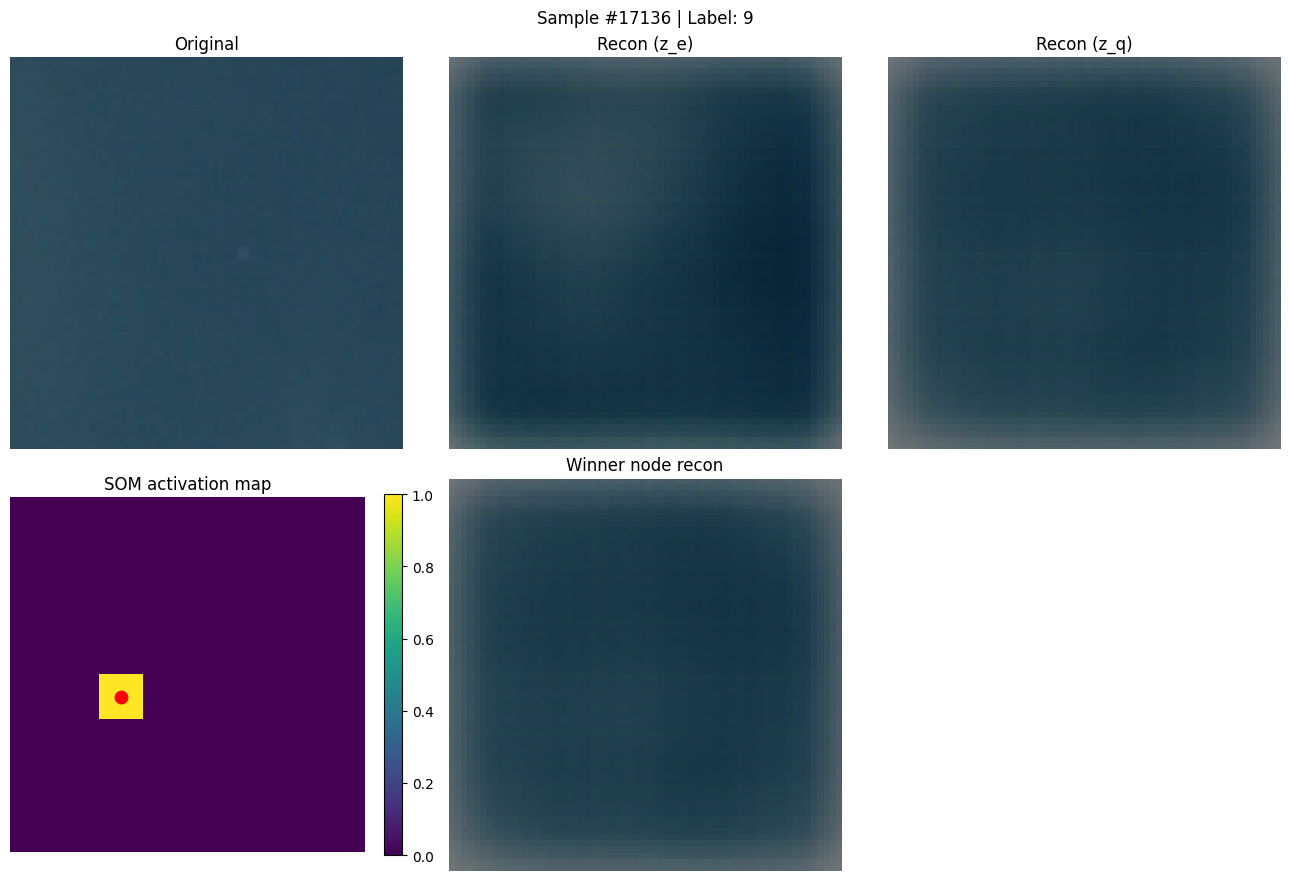

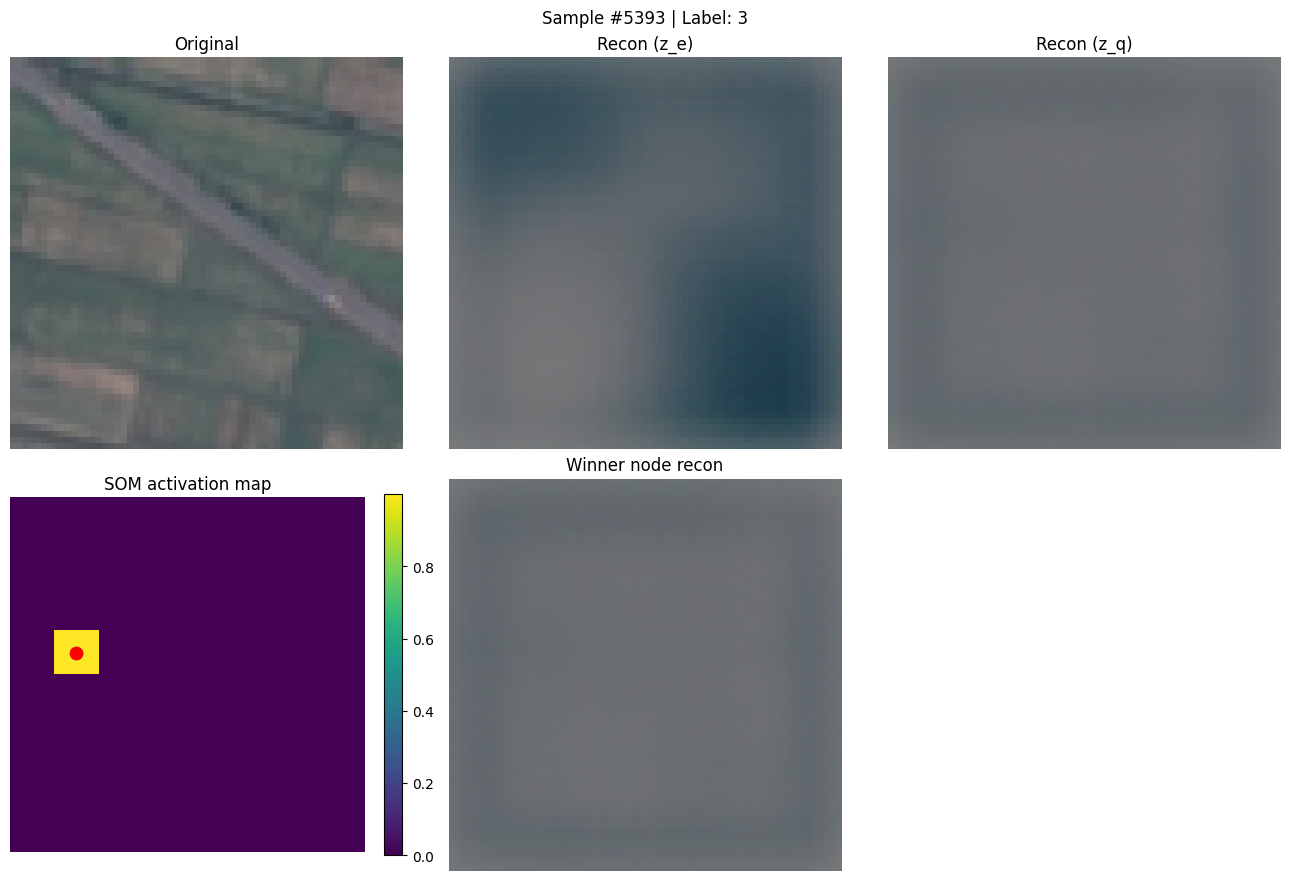

Epoch 2/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 2:
Train: 0.170 | Val: 0.16369686916817067 | NMI: 0.2382


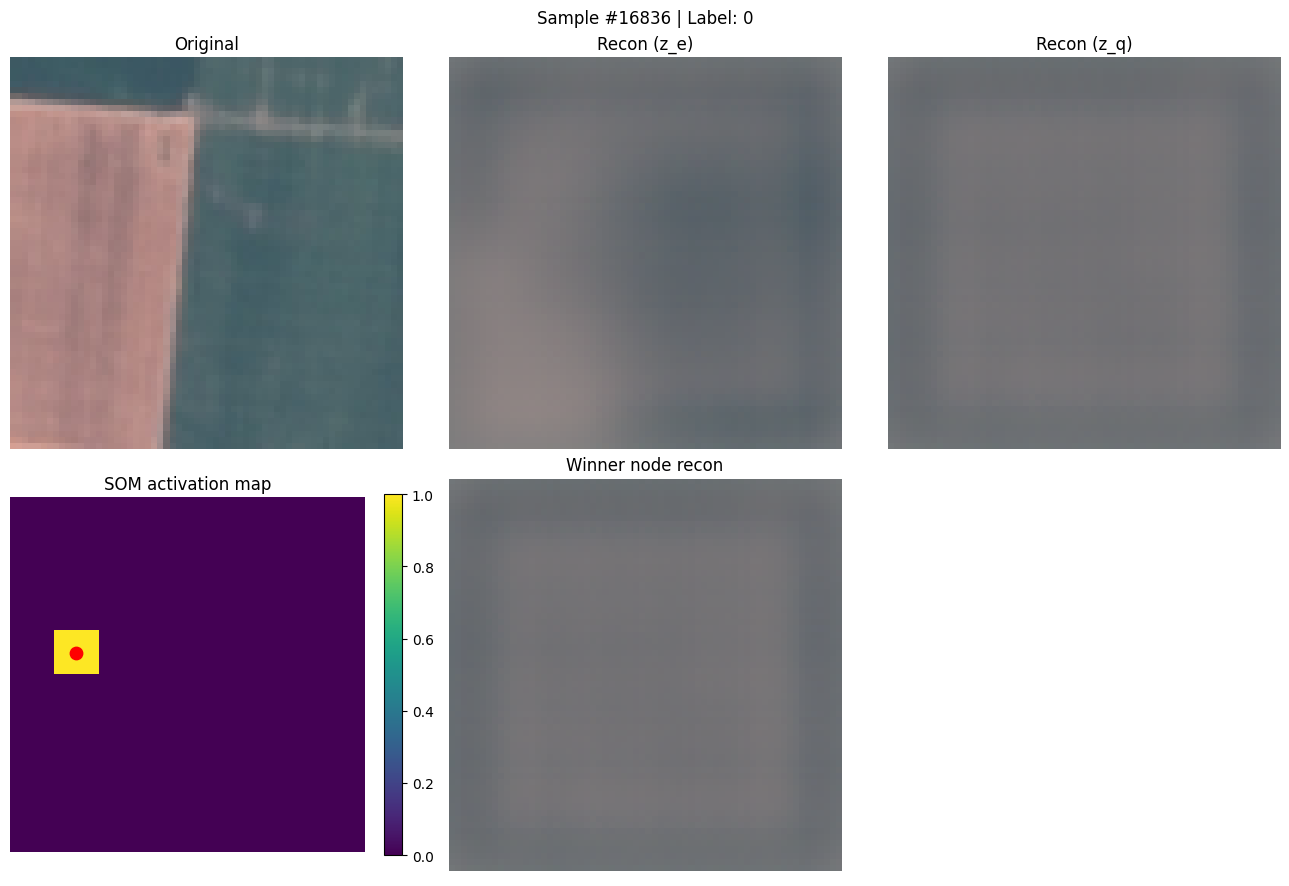

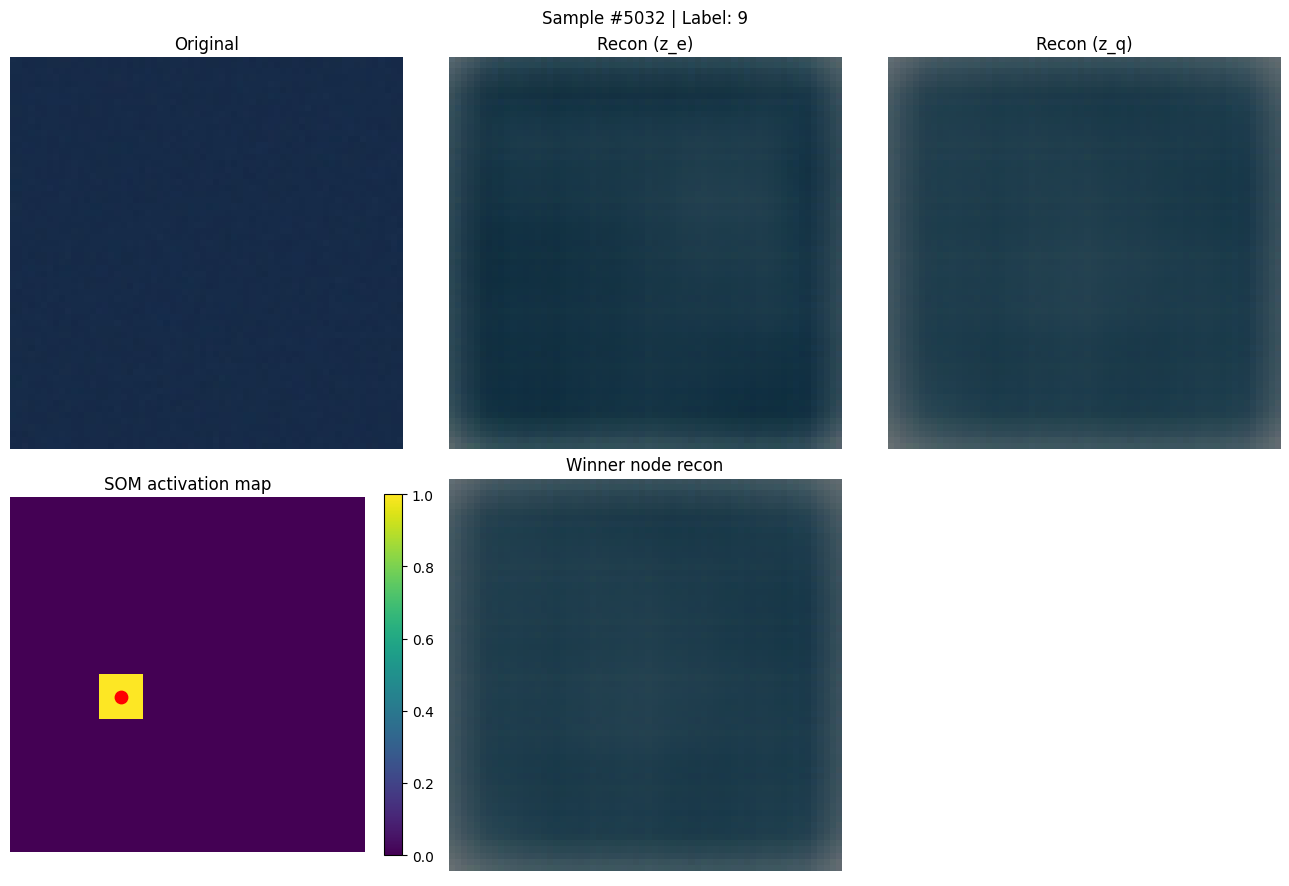

Epoch 3/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 3:
Train: 0.155 | Val: 0.1429193057986193 | NMI: 0.2625


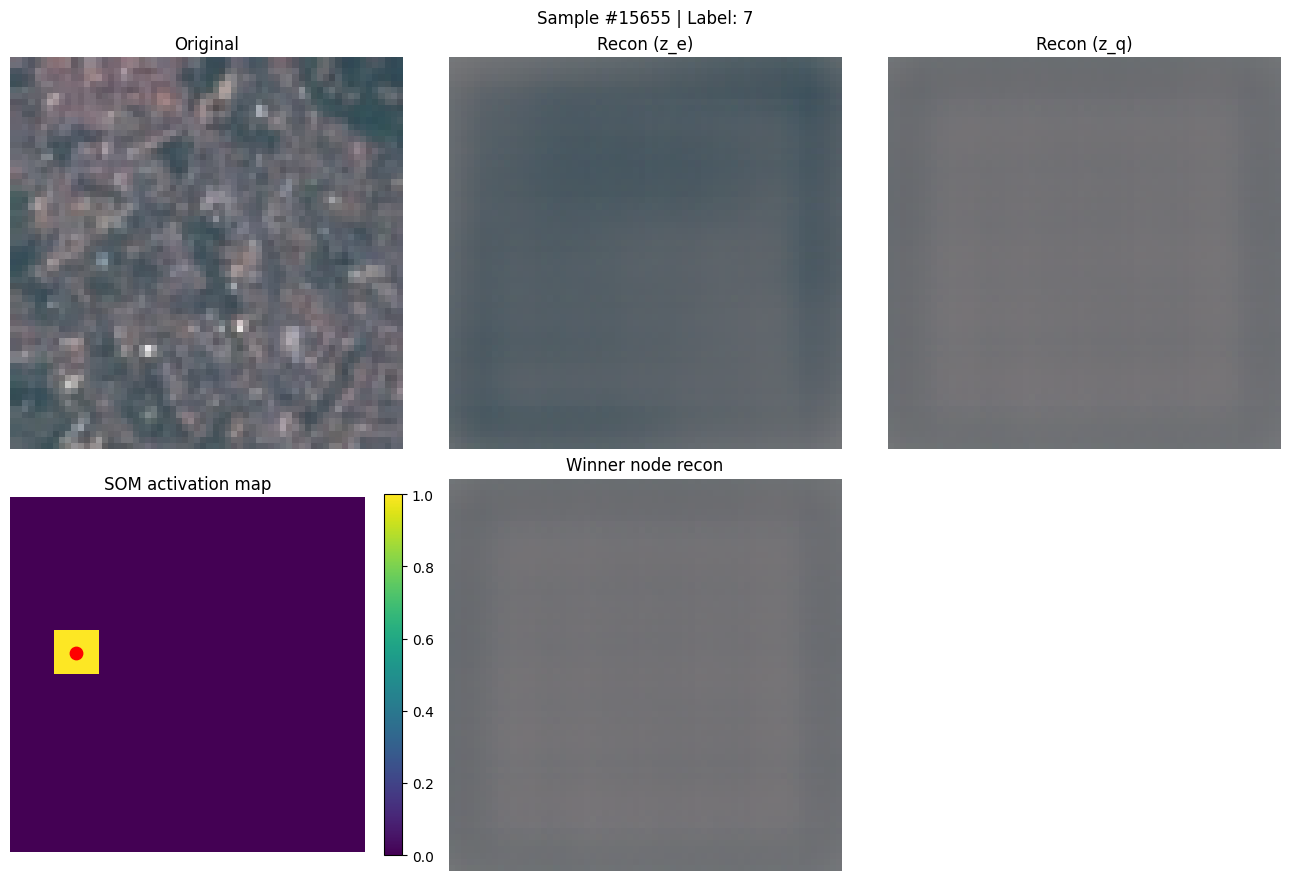

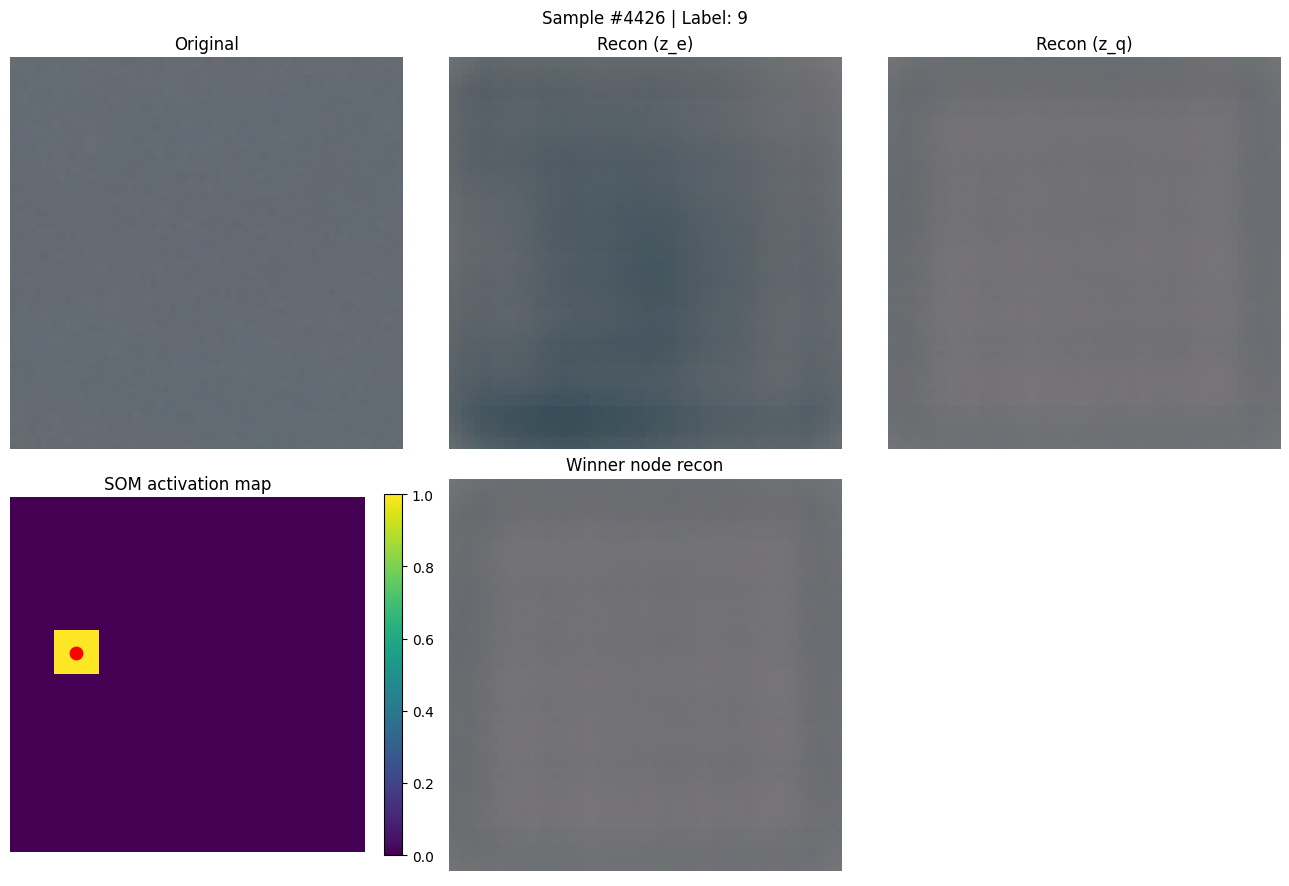

Epoch 4/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 4:
Train: 0.142 | Val: 0.135037382848041 | NMI: 0.2669


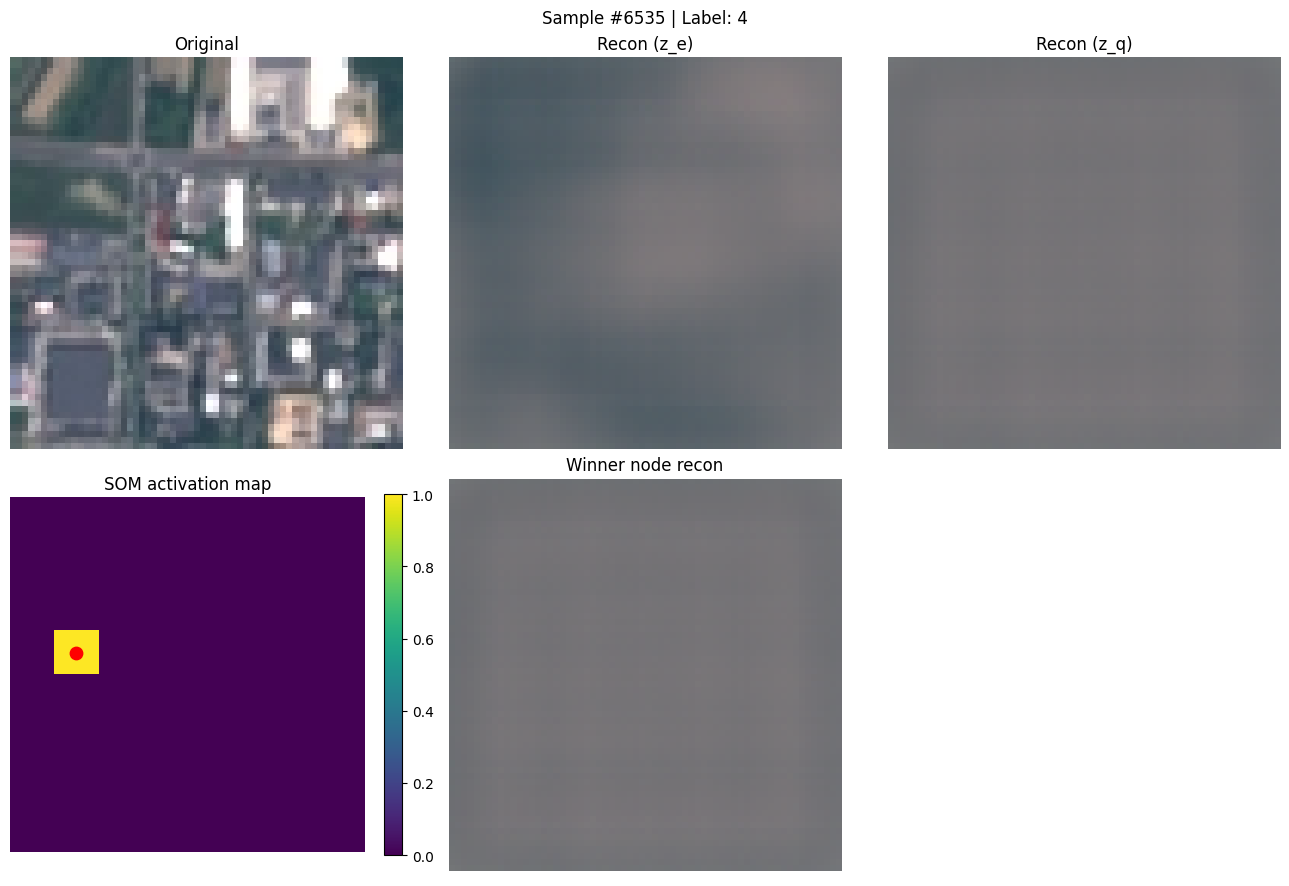

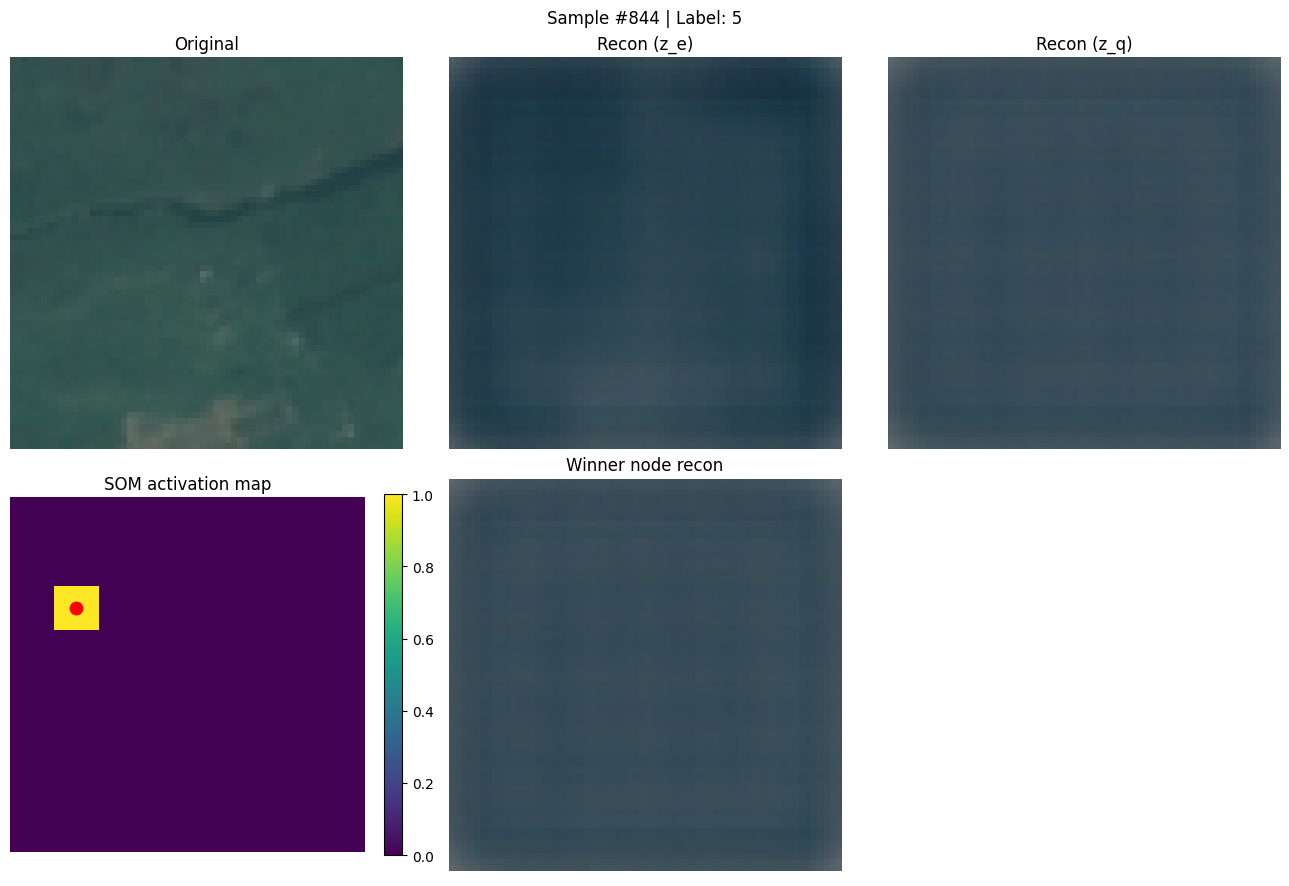

Epoch 5/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 5:
Train: 0.135 | Val: 0.13092427995315817 | NMI: 0.2571


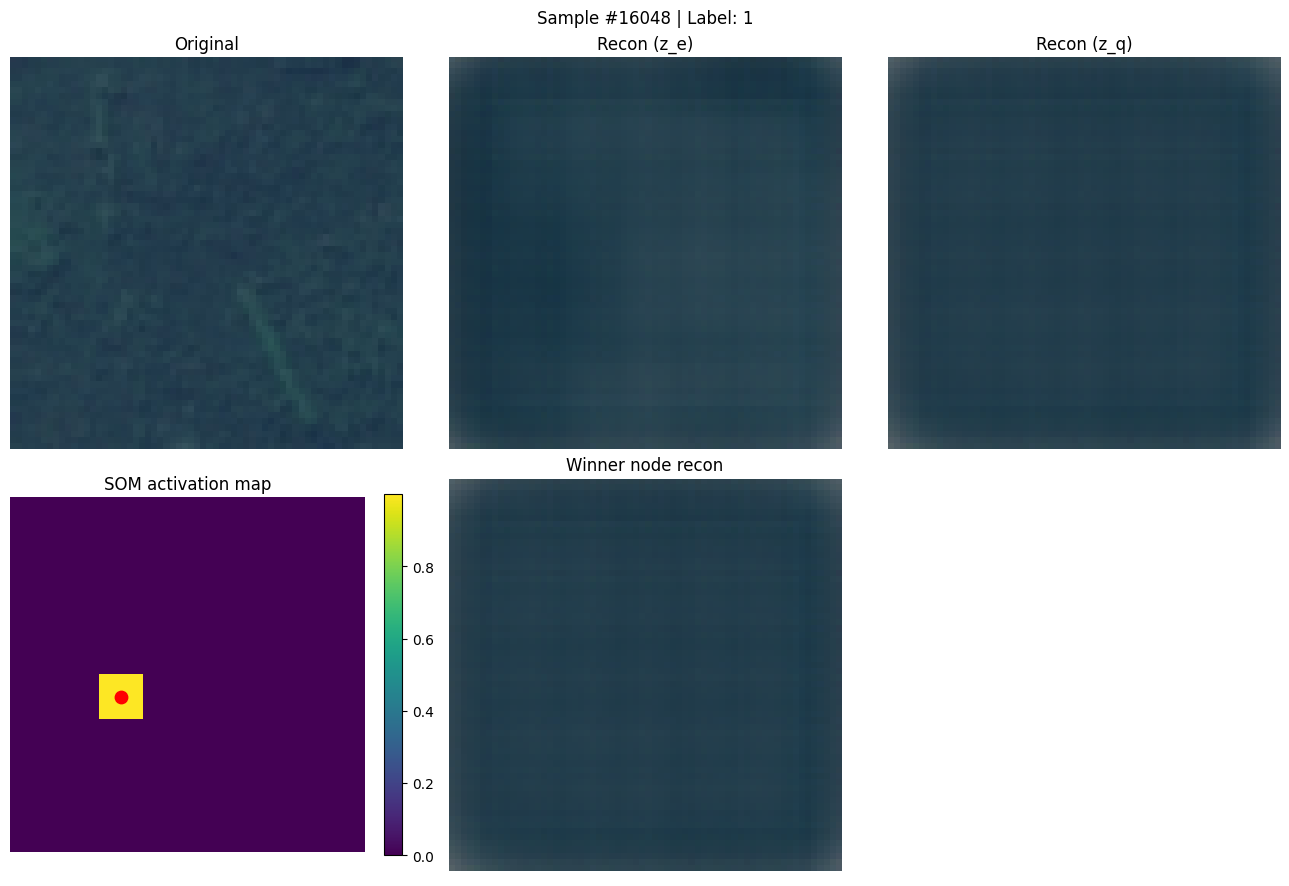

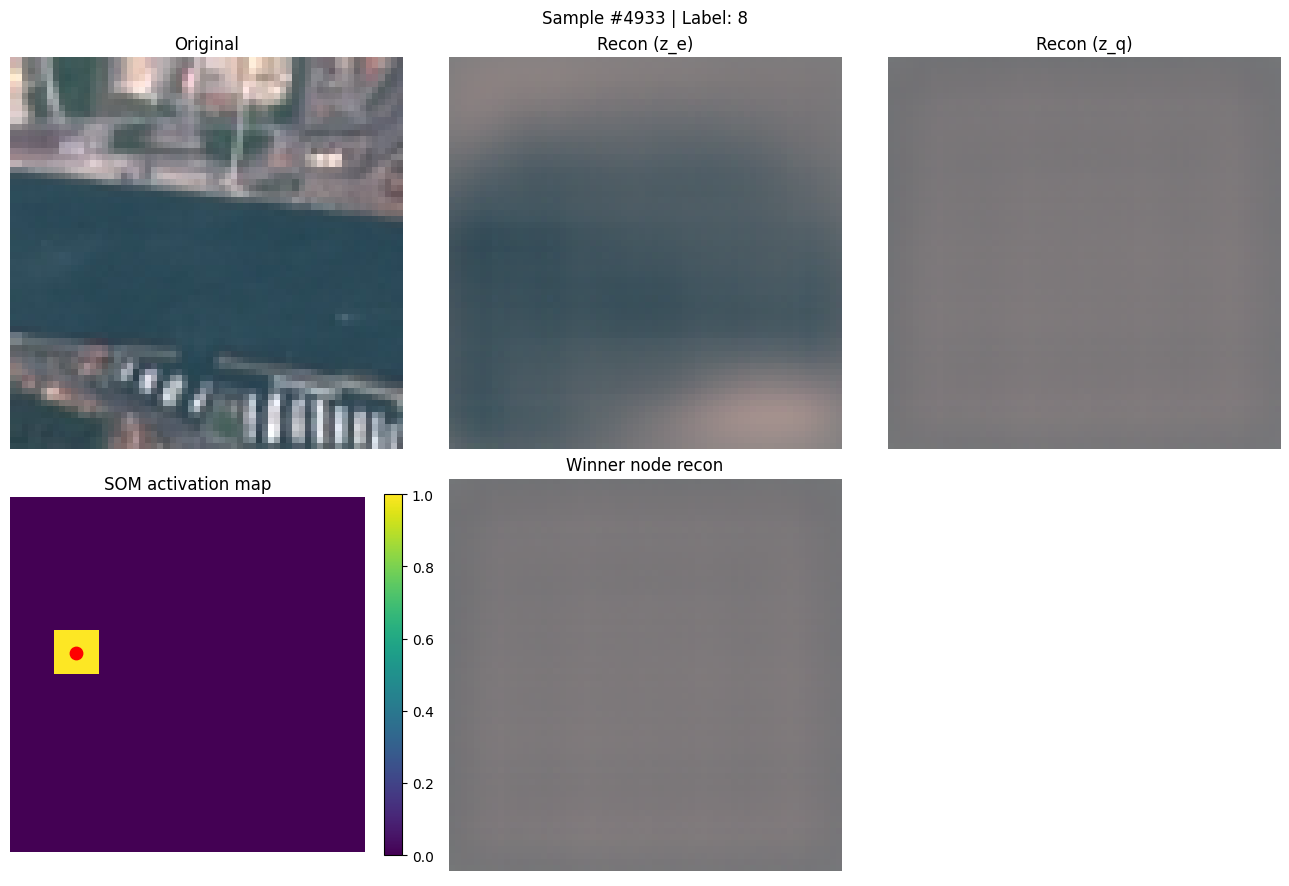

Epoch 6/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 6:
Train: 0.135 | Val: 0.1268153006947318 | NMI: 0.2488


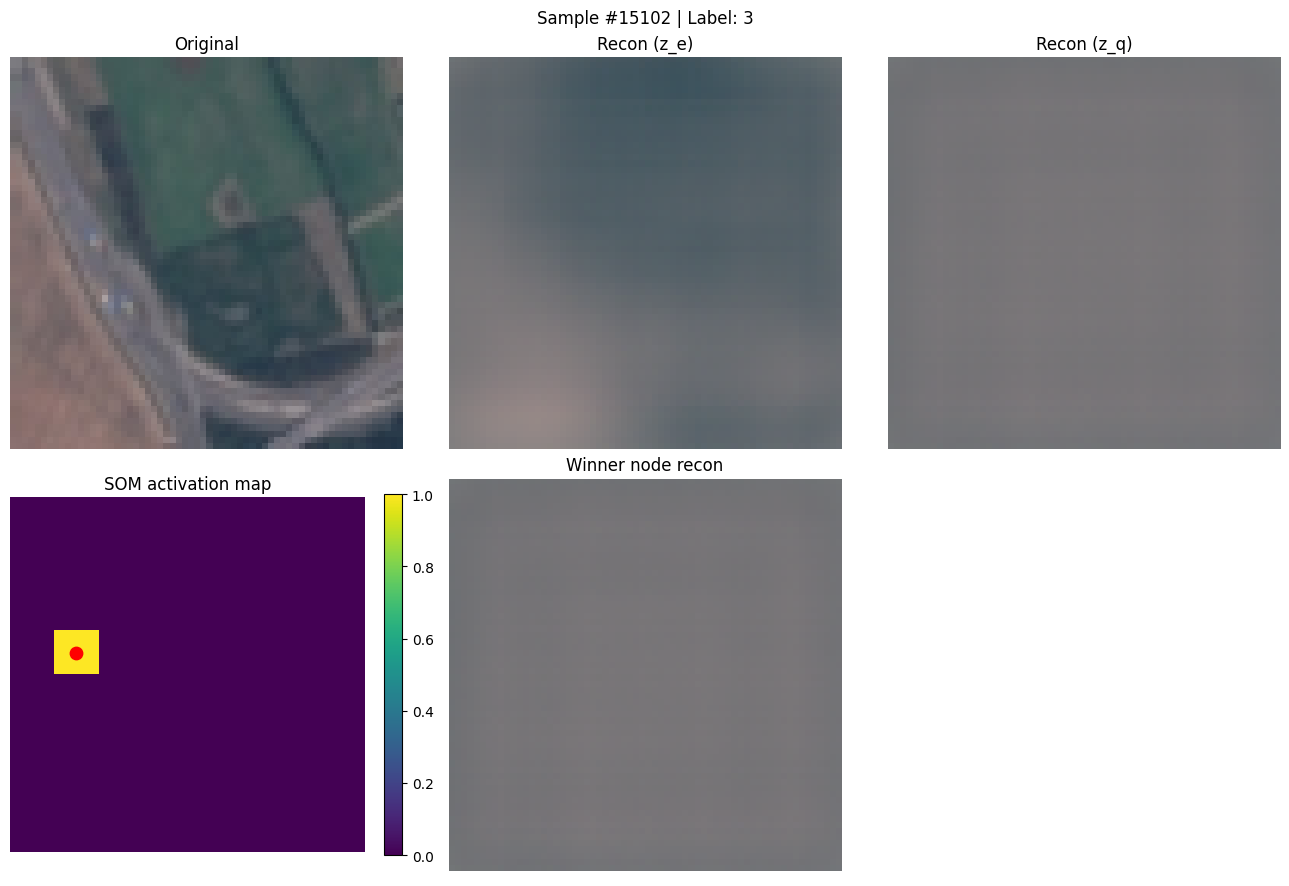

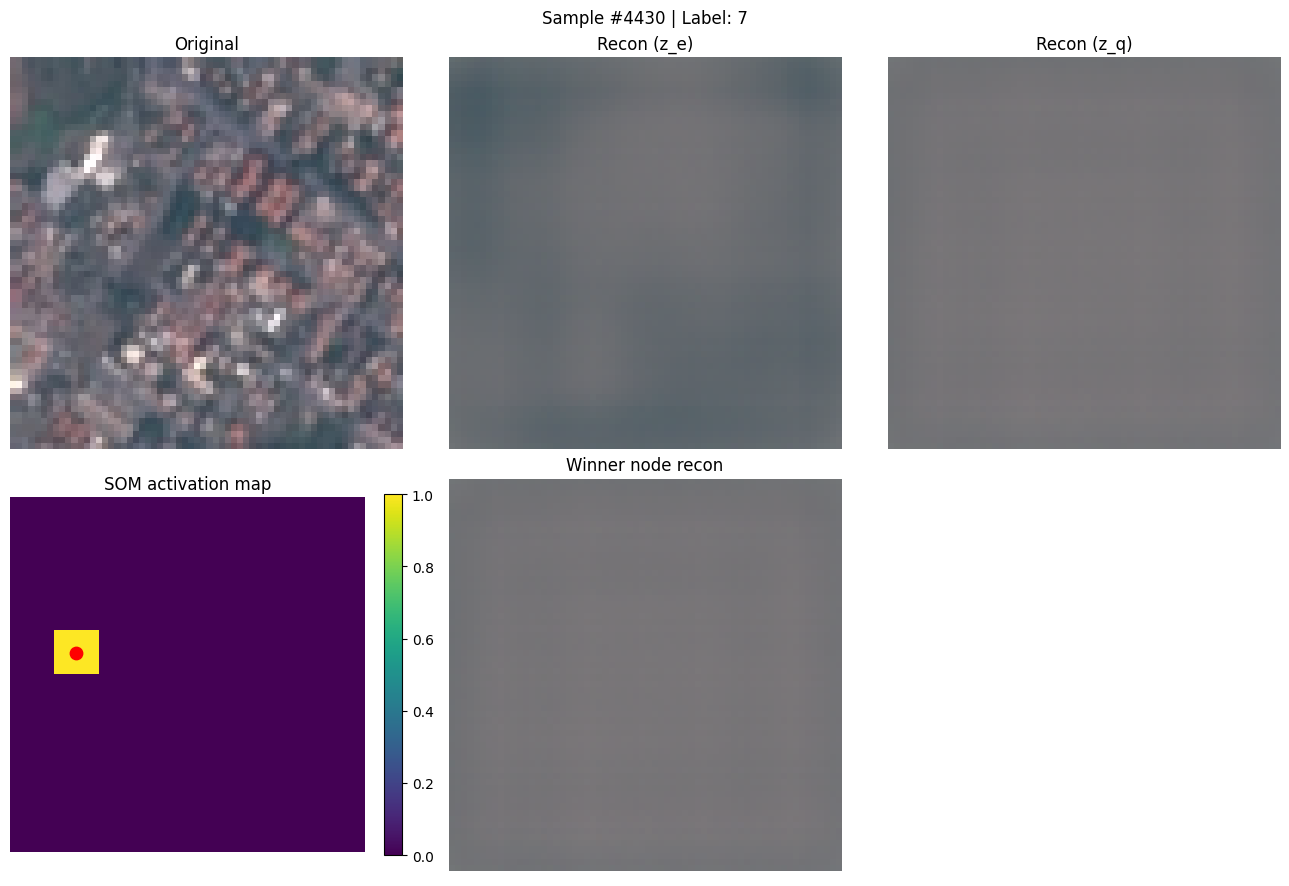

Epoch 7/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 7:
Train: 0.129 | Val: 0.13102432149787283 | NMI: 0.2572


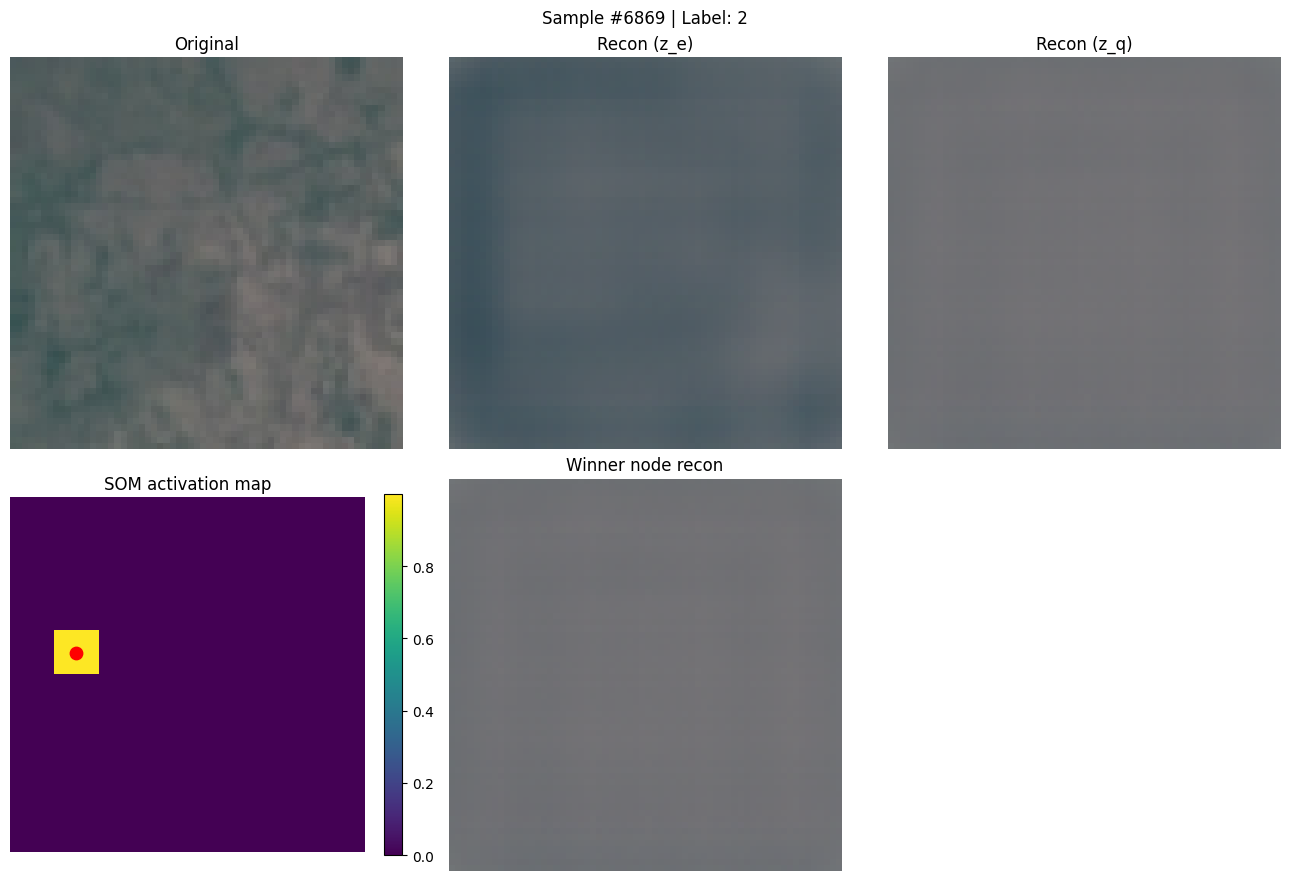

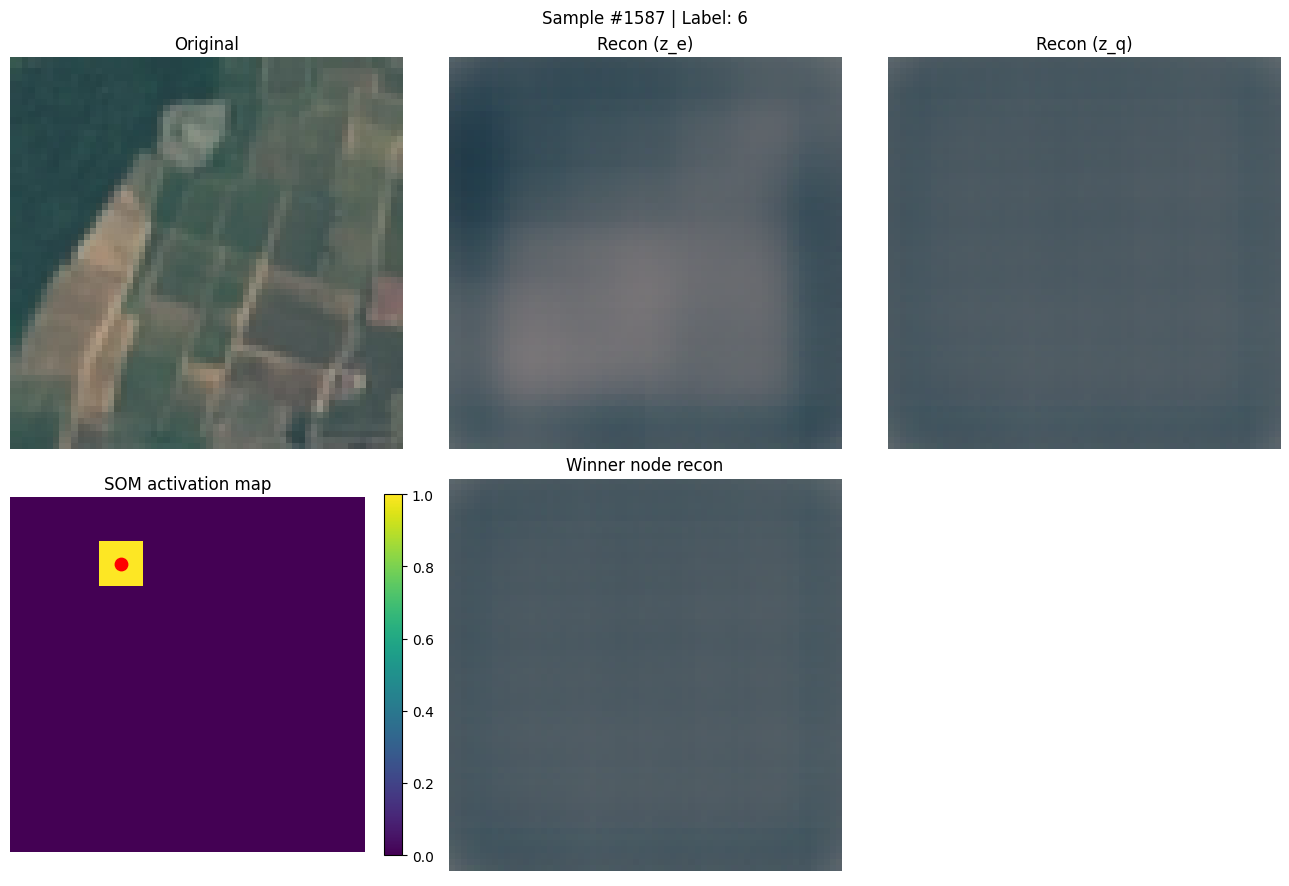

Epoch 8/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 8:
Train: 0.125 | Val: 0.12657336457524188 | NMI: 0.2250


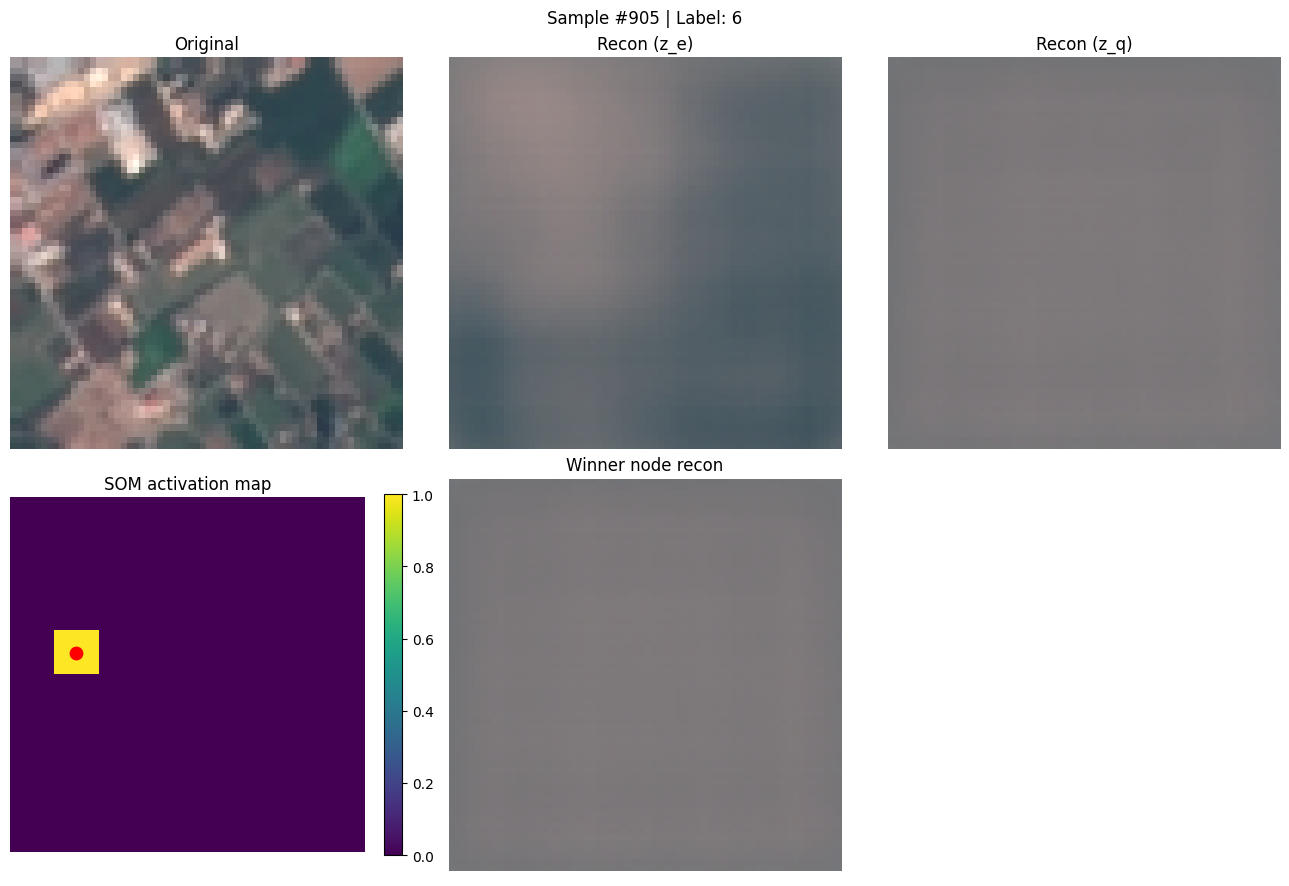

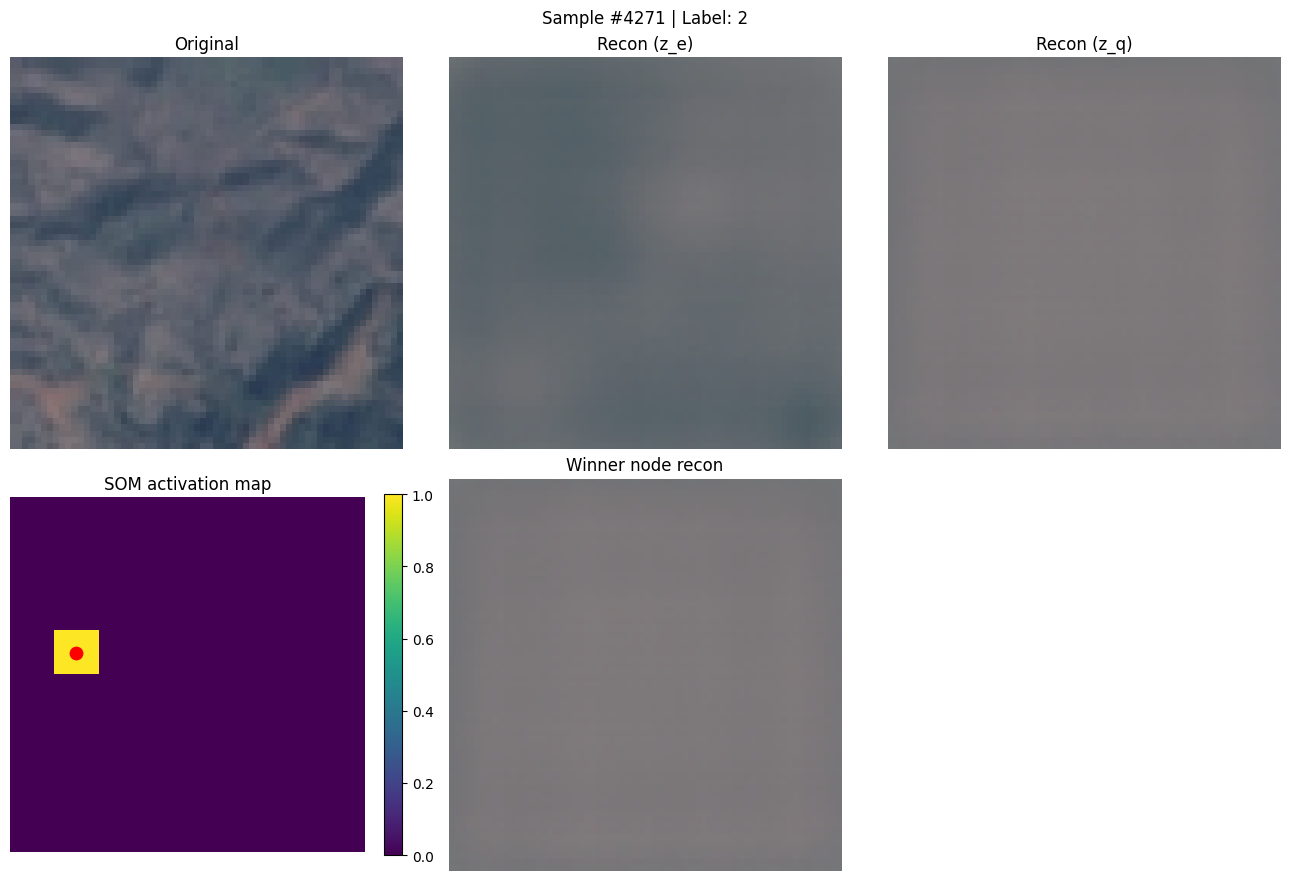

Epoch 9/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 9:
Train: 0.123 | Val: 0.12650795575491217 | NMI: 0.2445


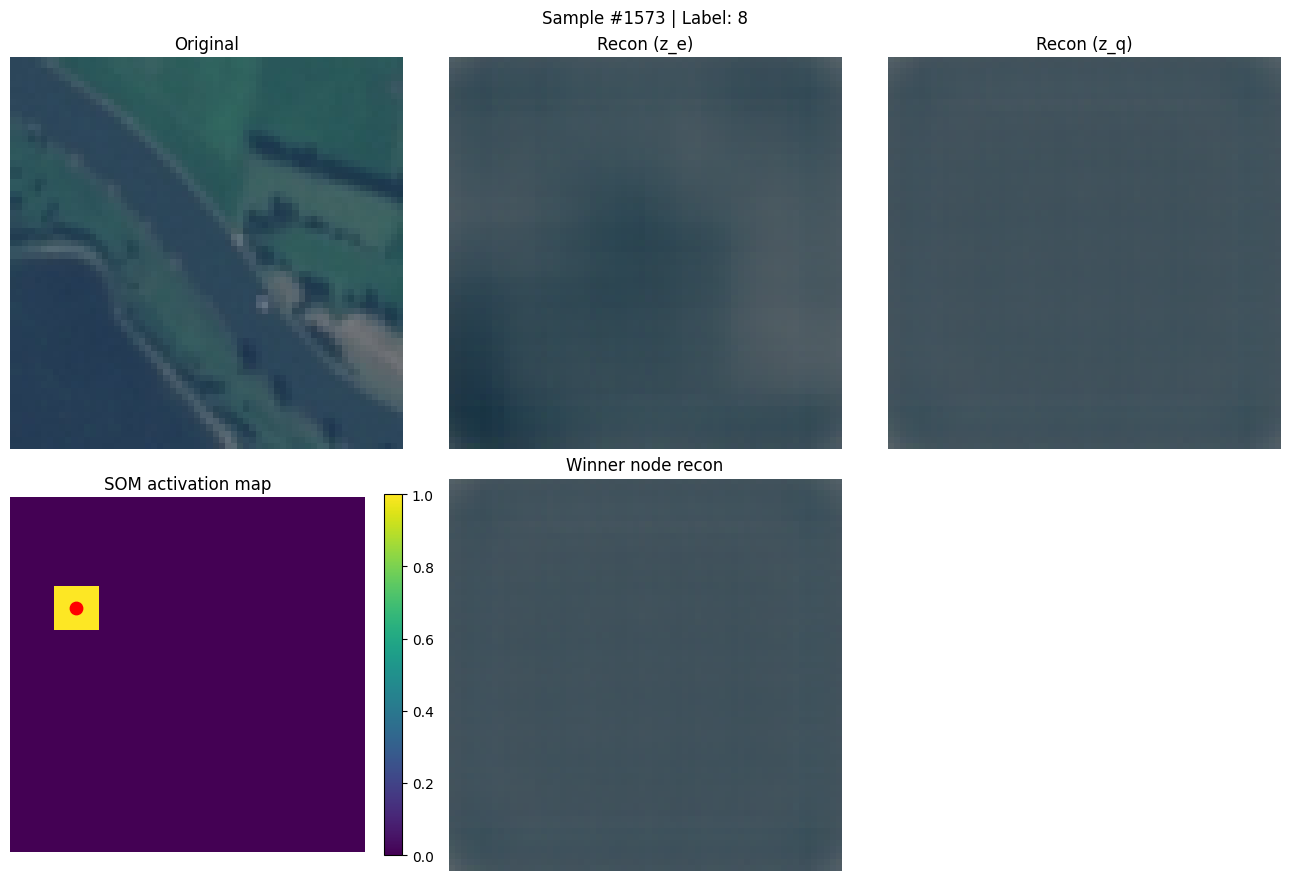

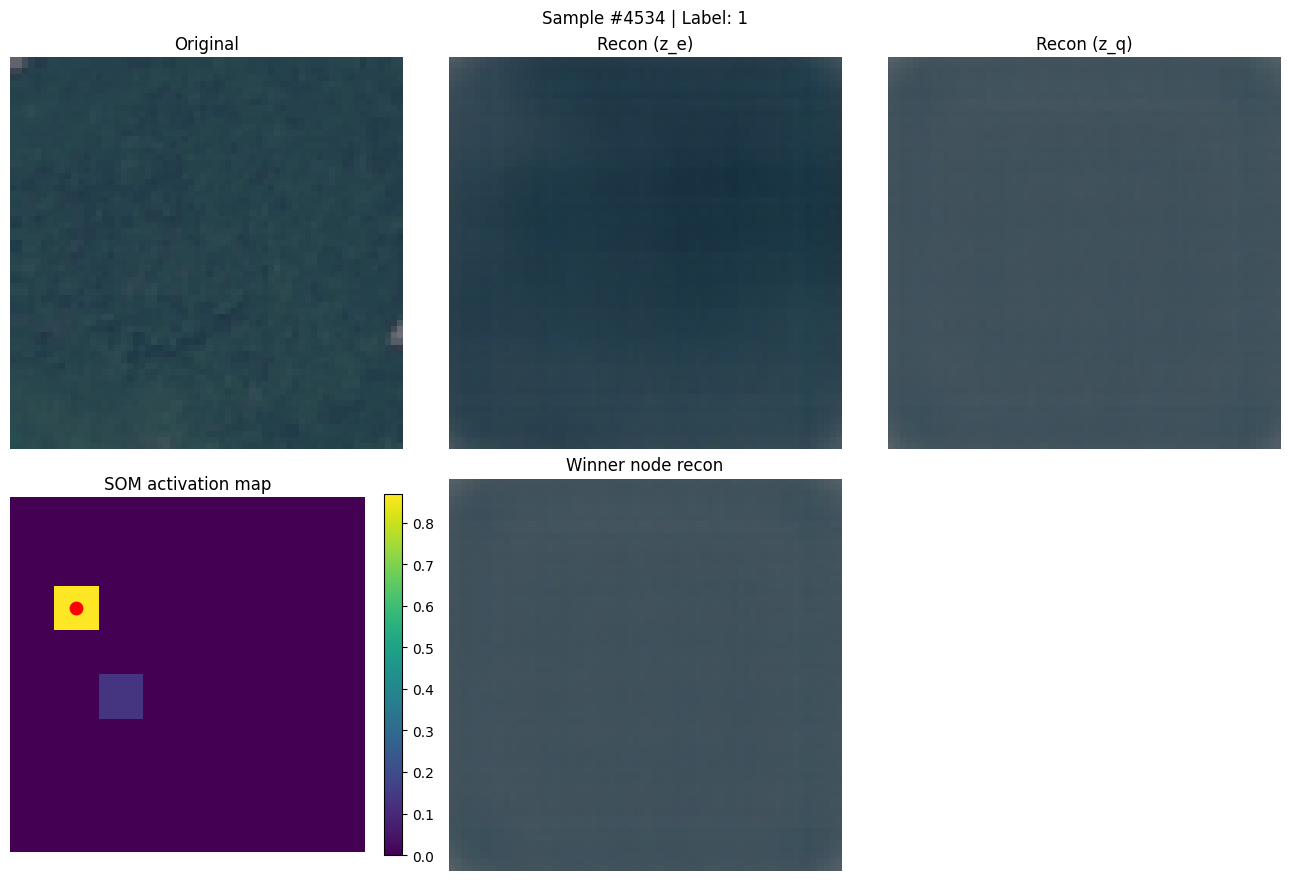

Epoch 10/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 10:
Train: 0.118 | Val: 0.11371592380279719 | NMI: 0.2460


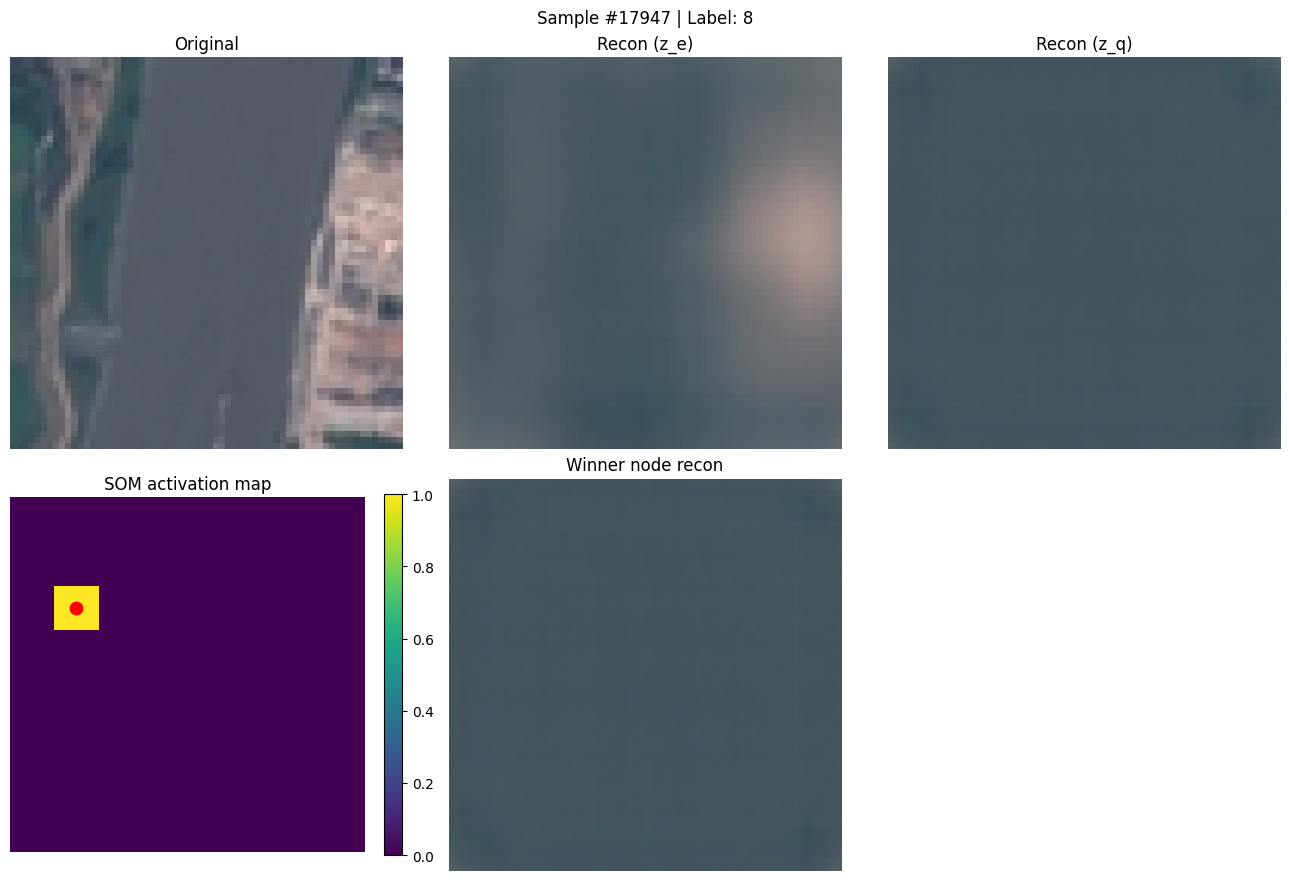

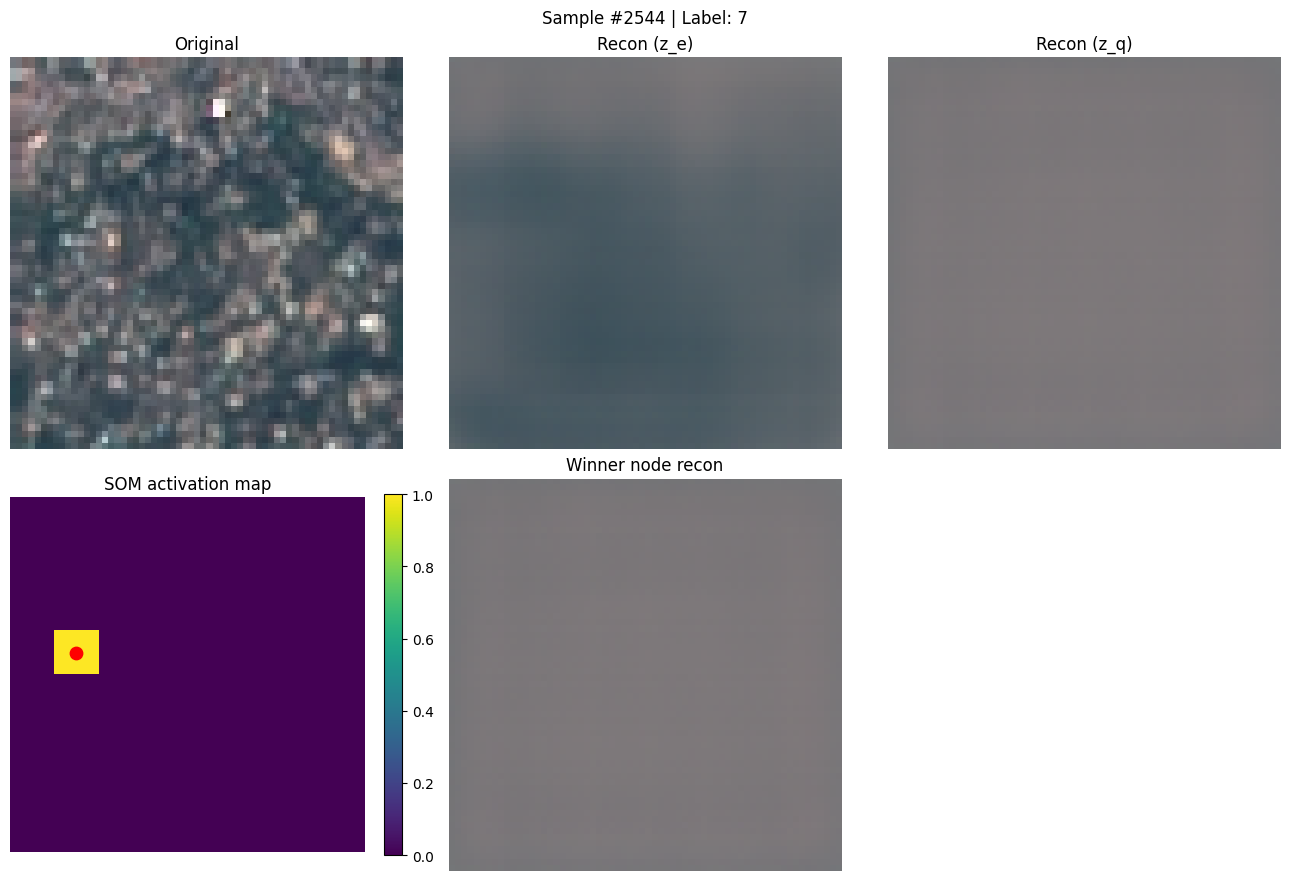

Epoch 11/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 11:
Train: 0.116 | Val: 0.1337240269017774 | NMI: 0.2220


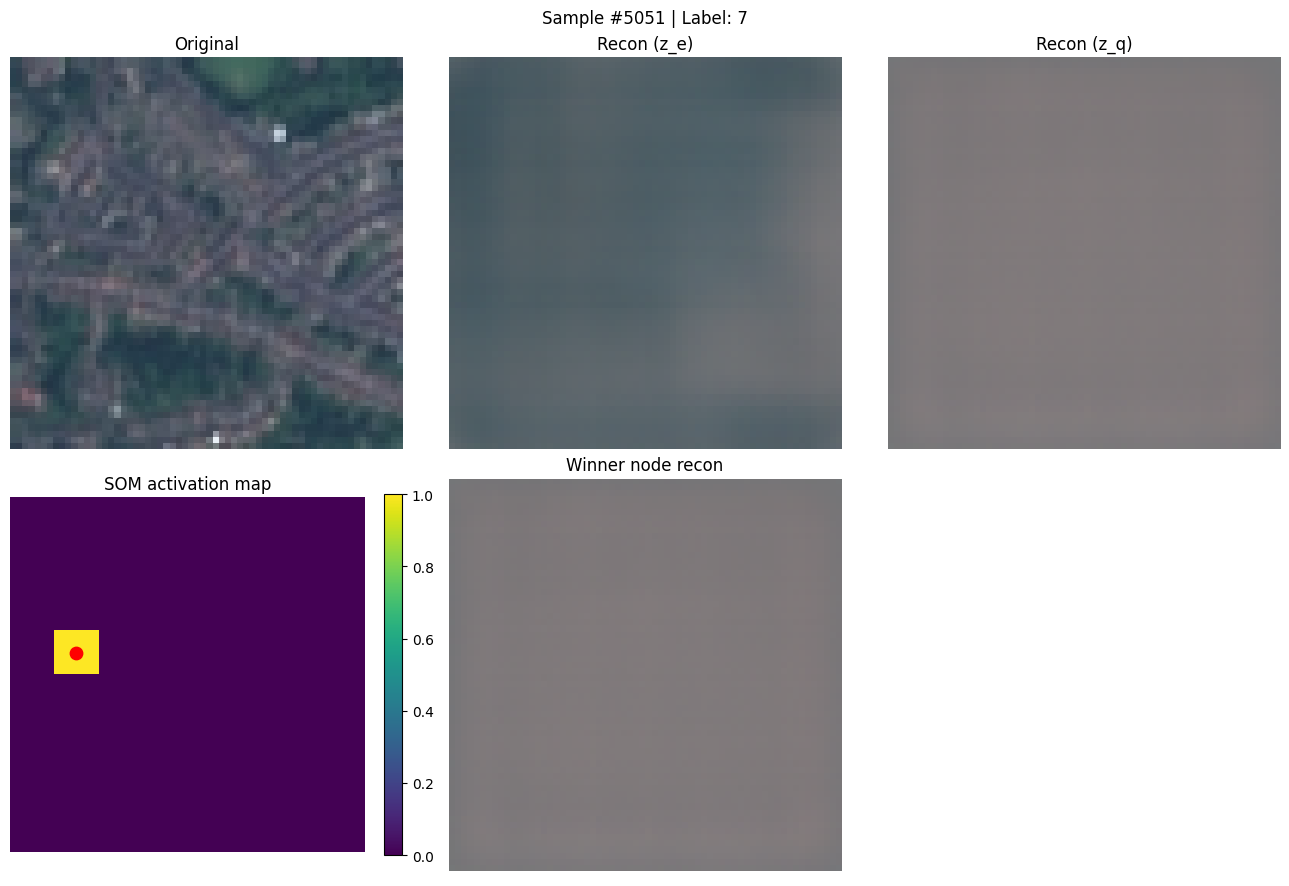

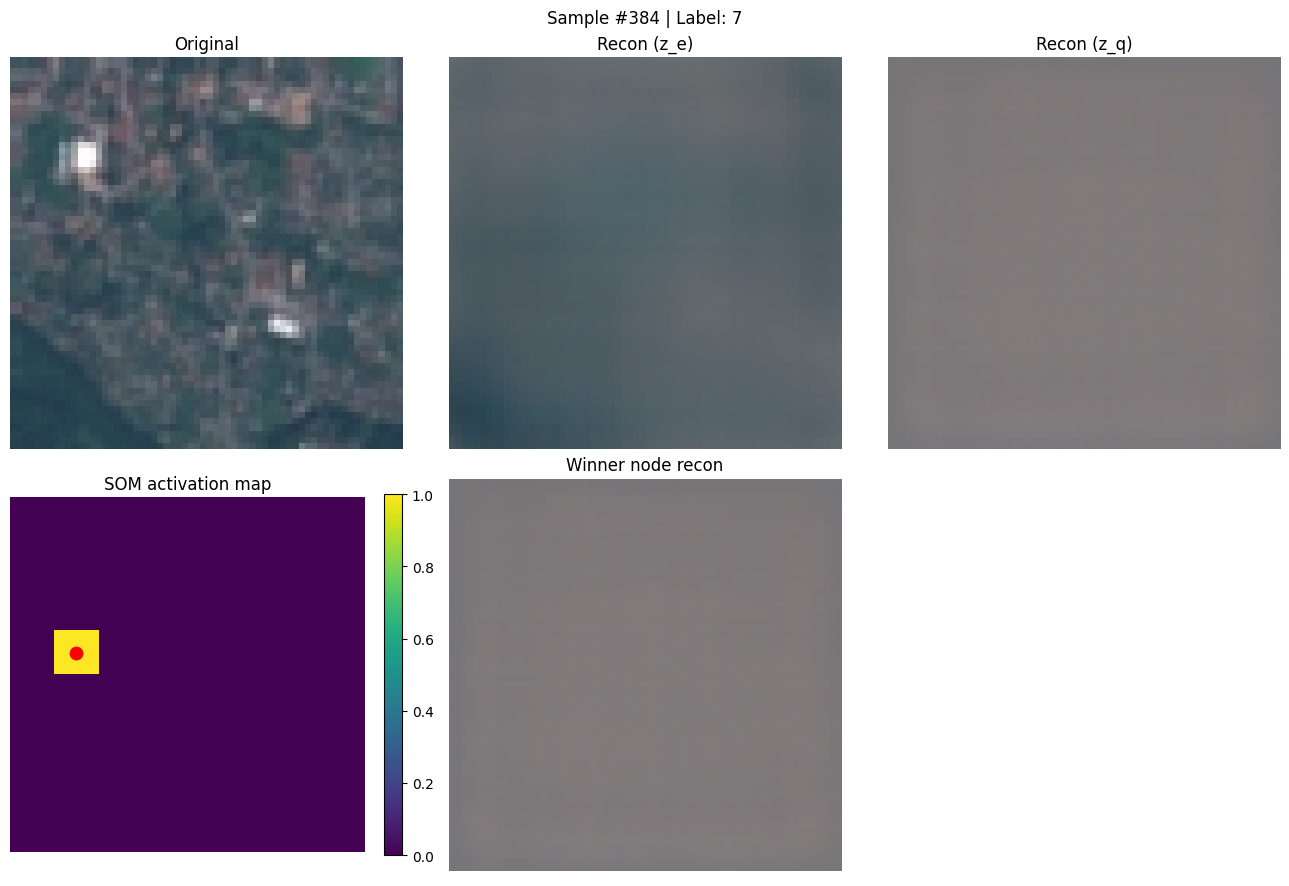

Epoch 12/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 12:
Train: 0.113 | Val: 0.11283718586661094 | NMI: 0.2370


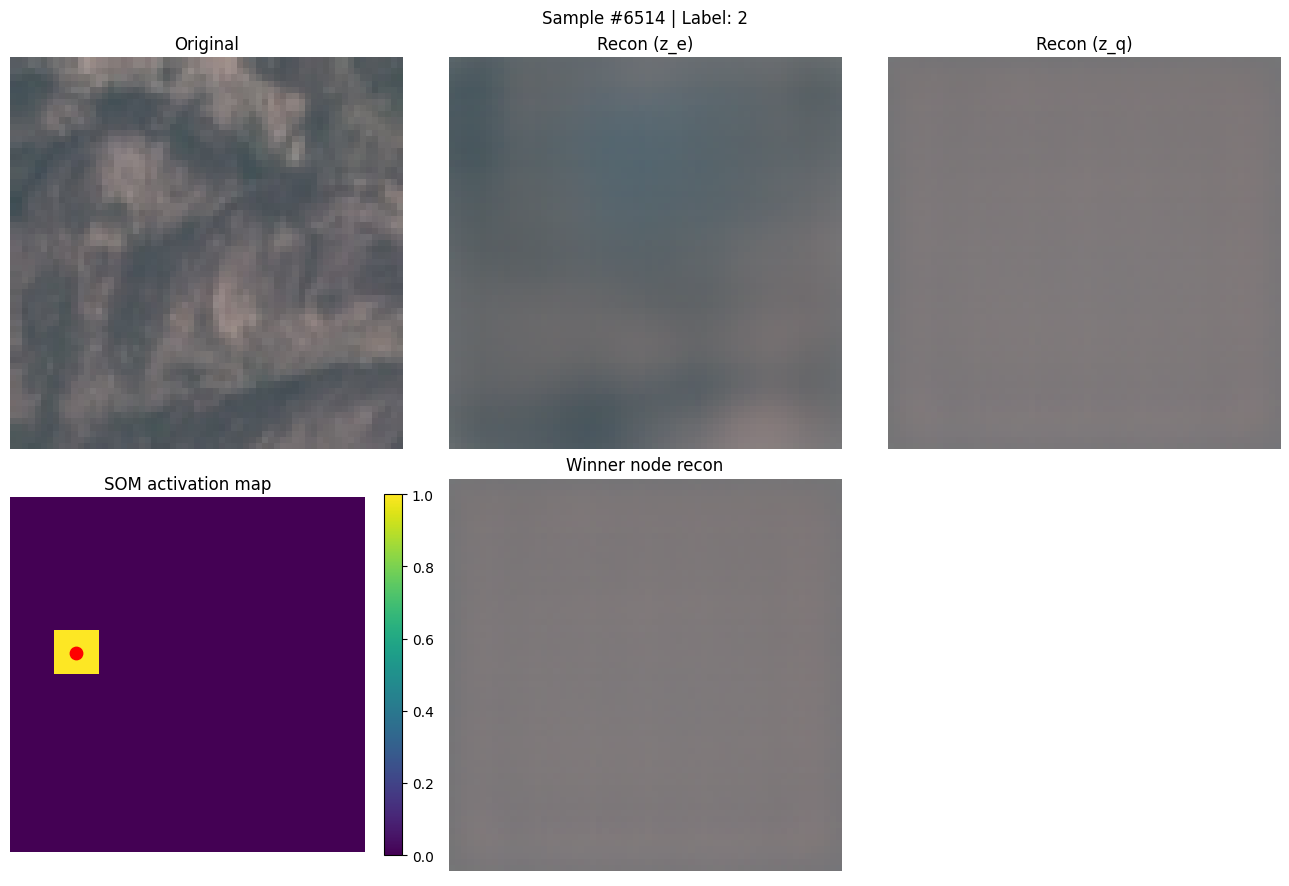

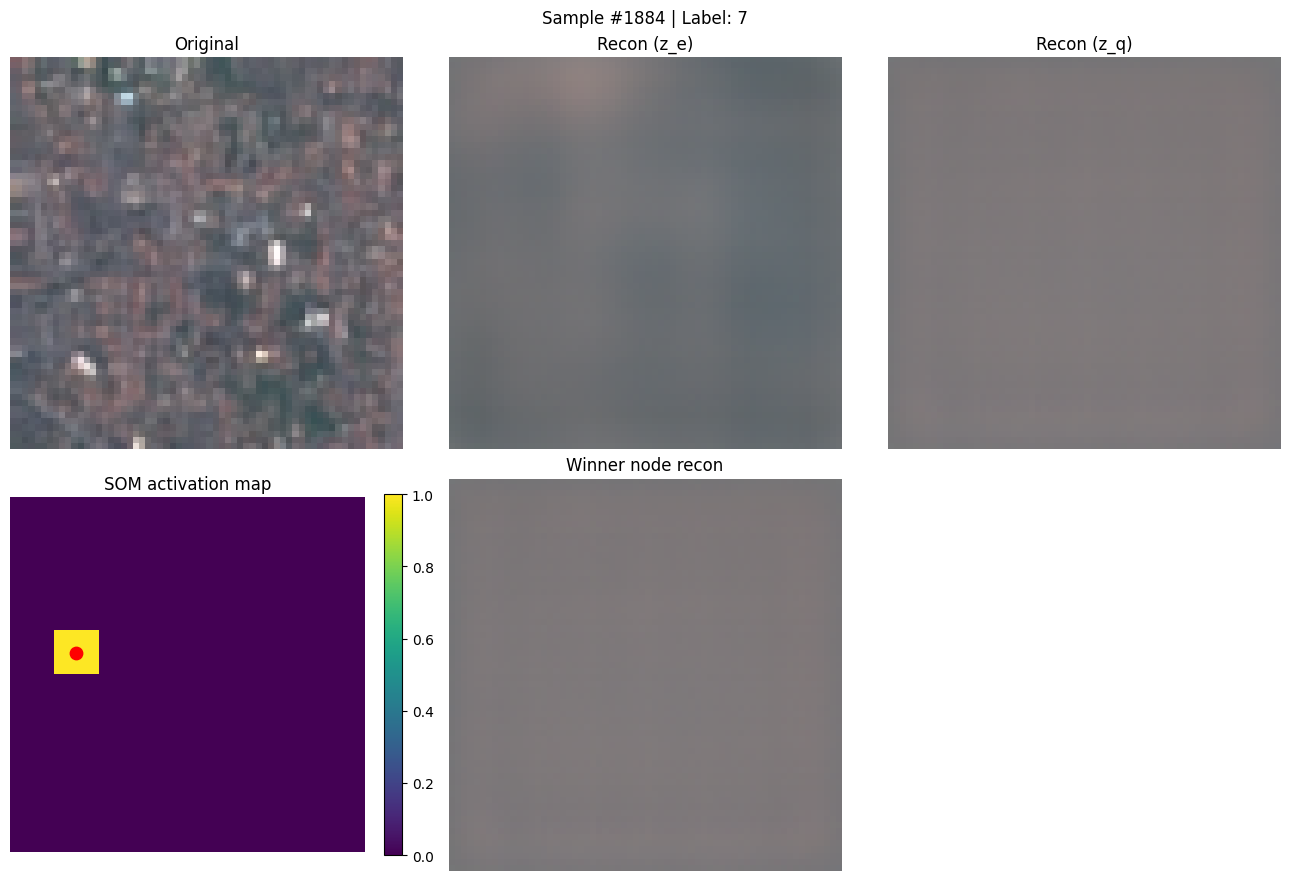

Epoch 13/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 13:
Train: 0.110 | Val: 0.10385489585094673 | NMI: 0.2648


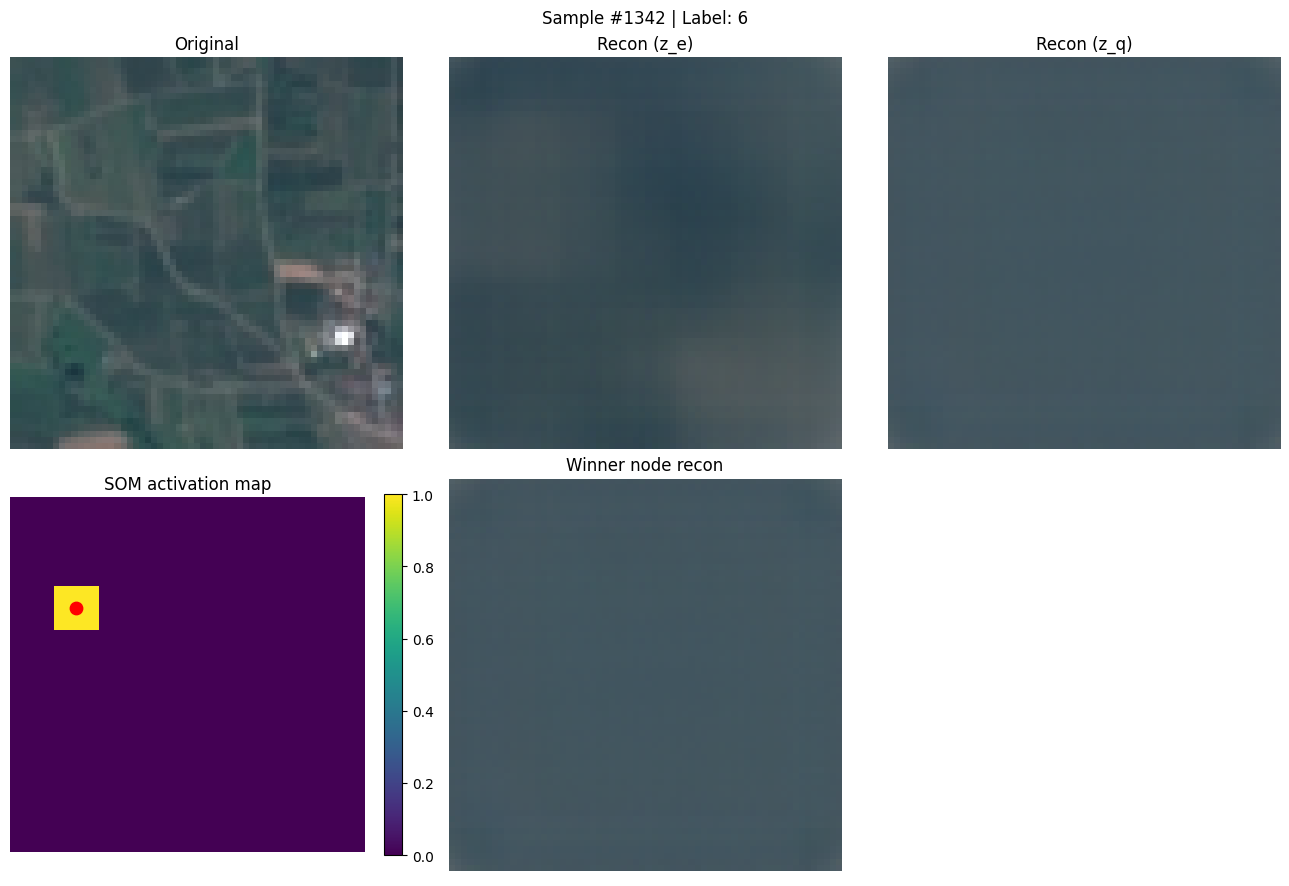

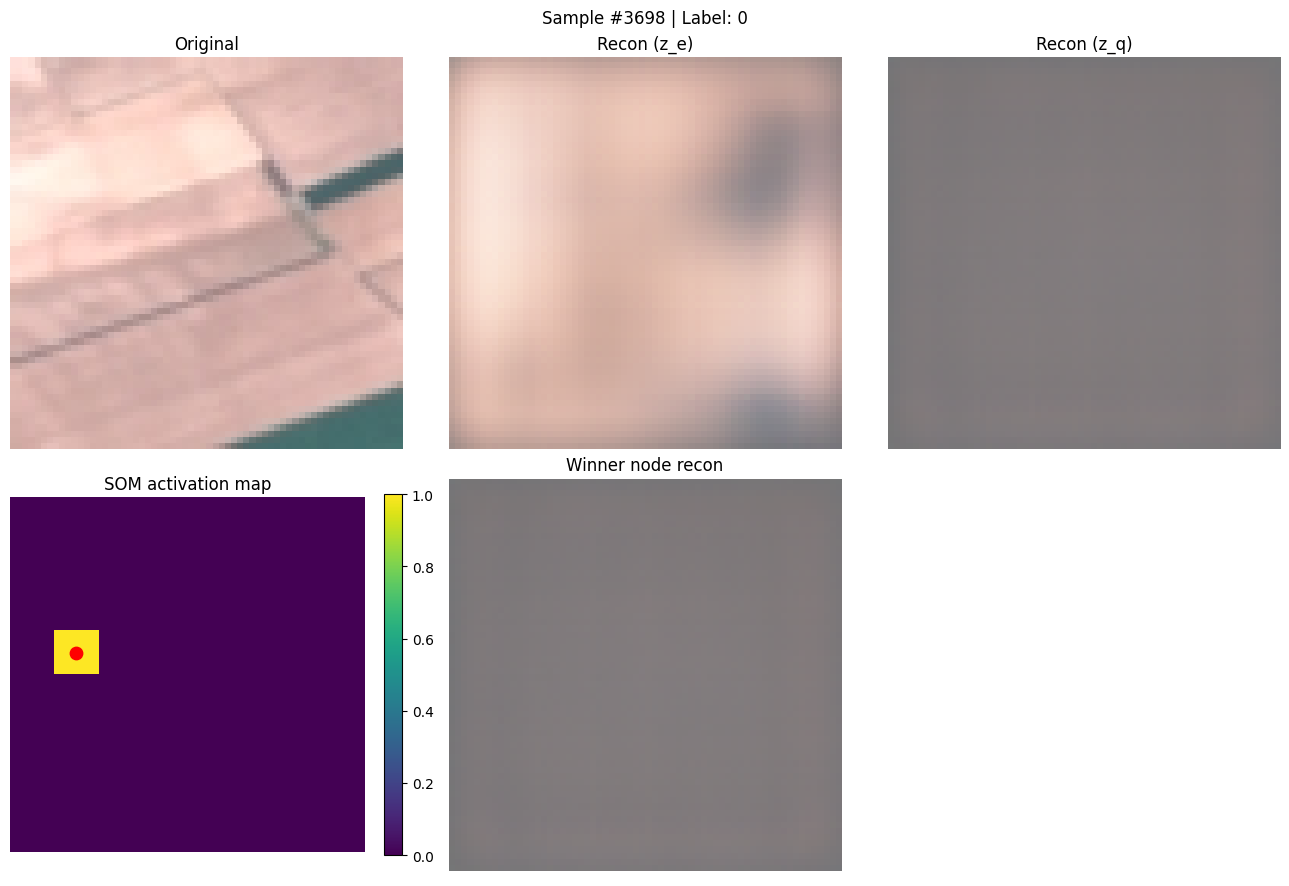

Epoch 14/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 14:
Train: 0.108 | Val: 0.10825041265681733 | NMI: 0.2539


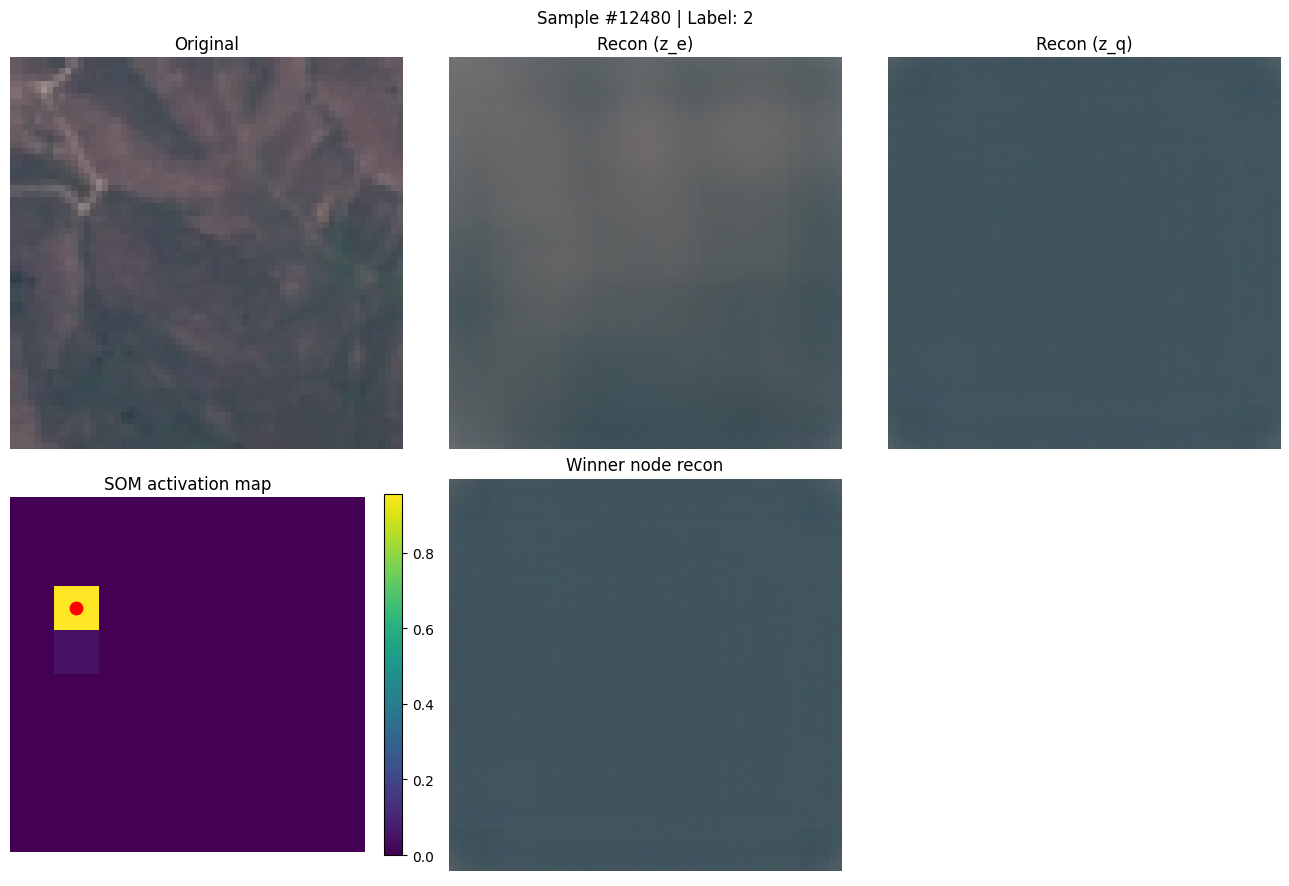

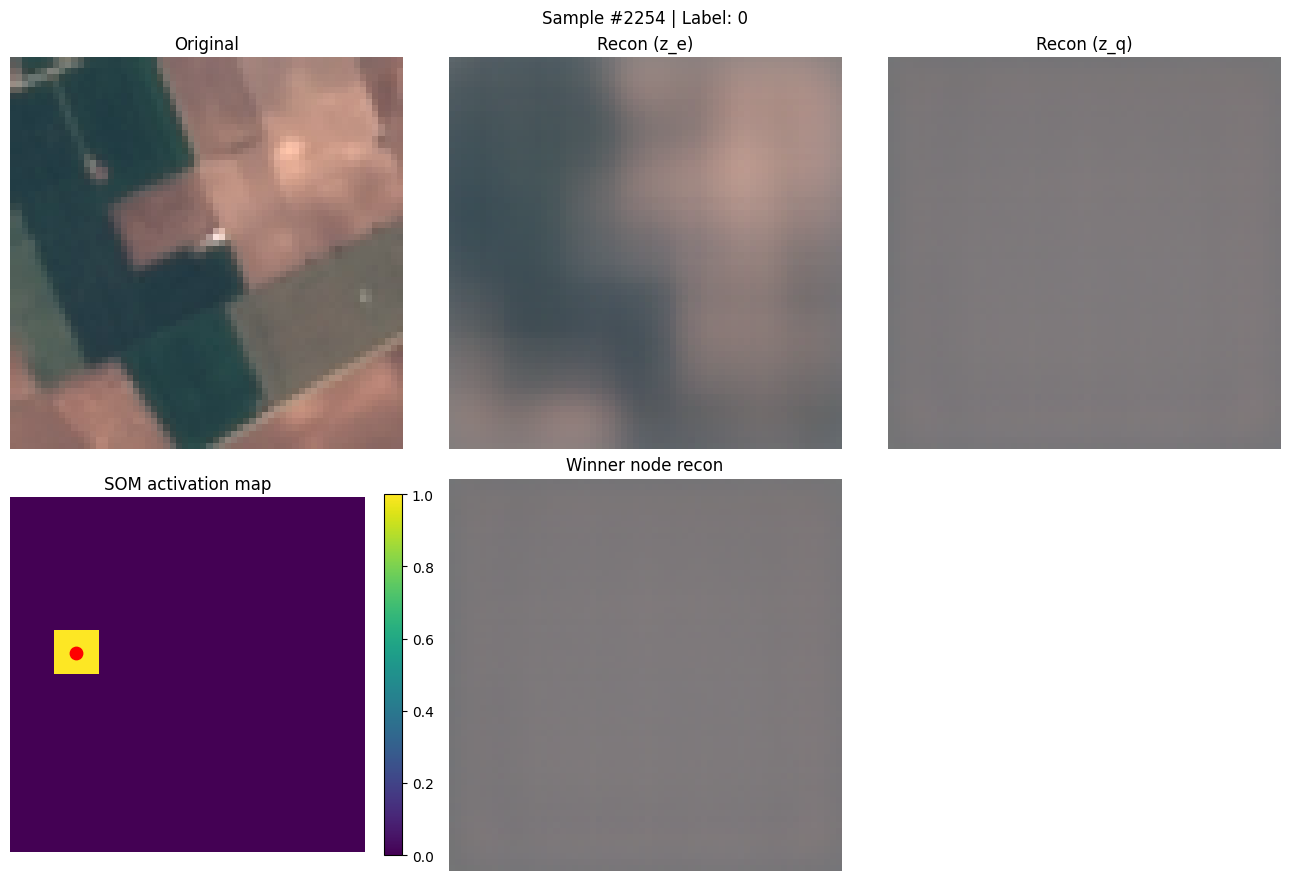

Epoch 15/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 15:
Train: 0.108 | Val: 0.10231416707122049 | NMI: 0.2716


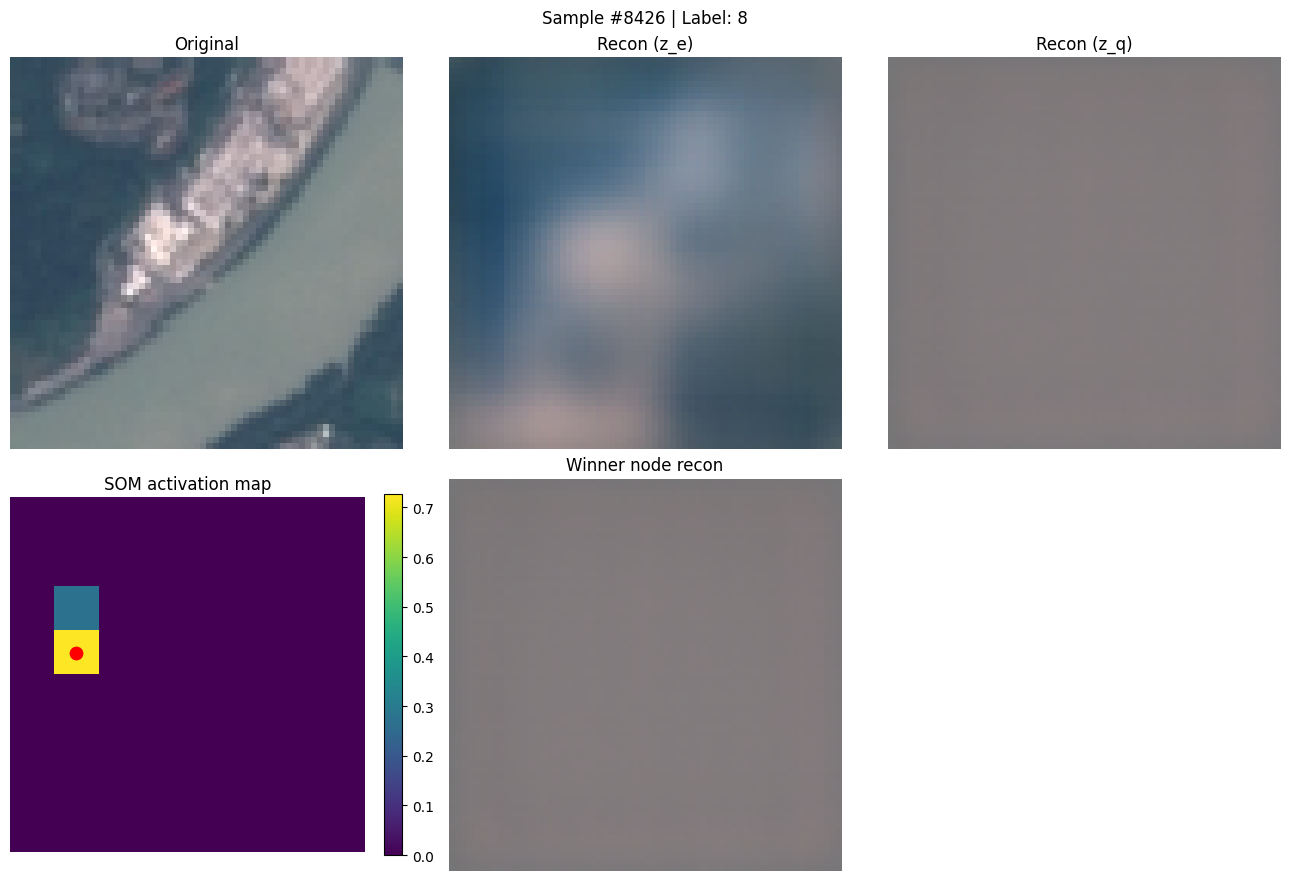

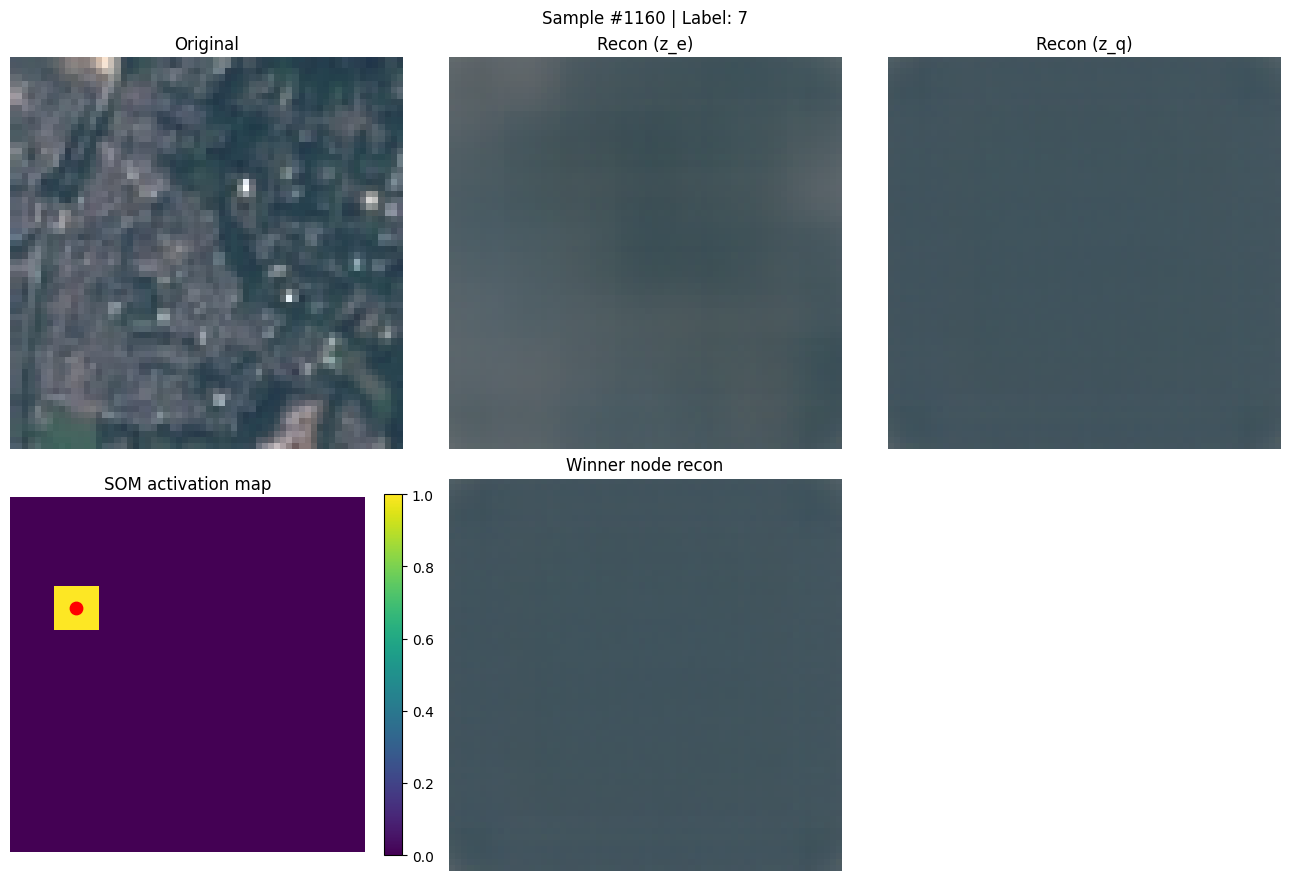

Epoch 16/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 16:
Train: 0.107 | Val: 0.11032633985890898 | NMI: 0.2327


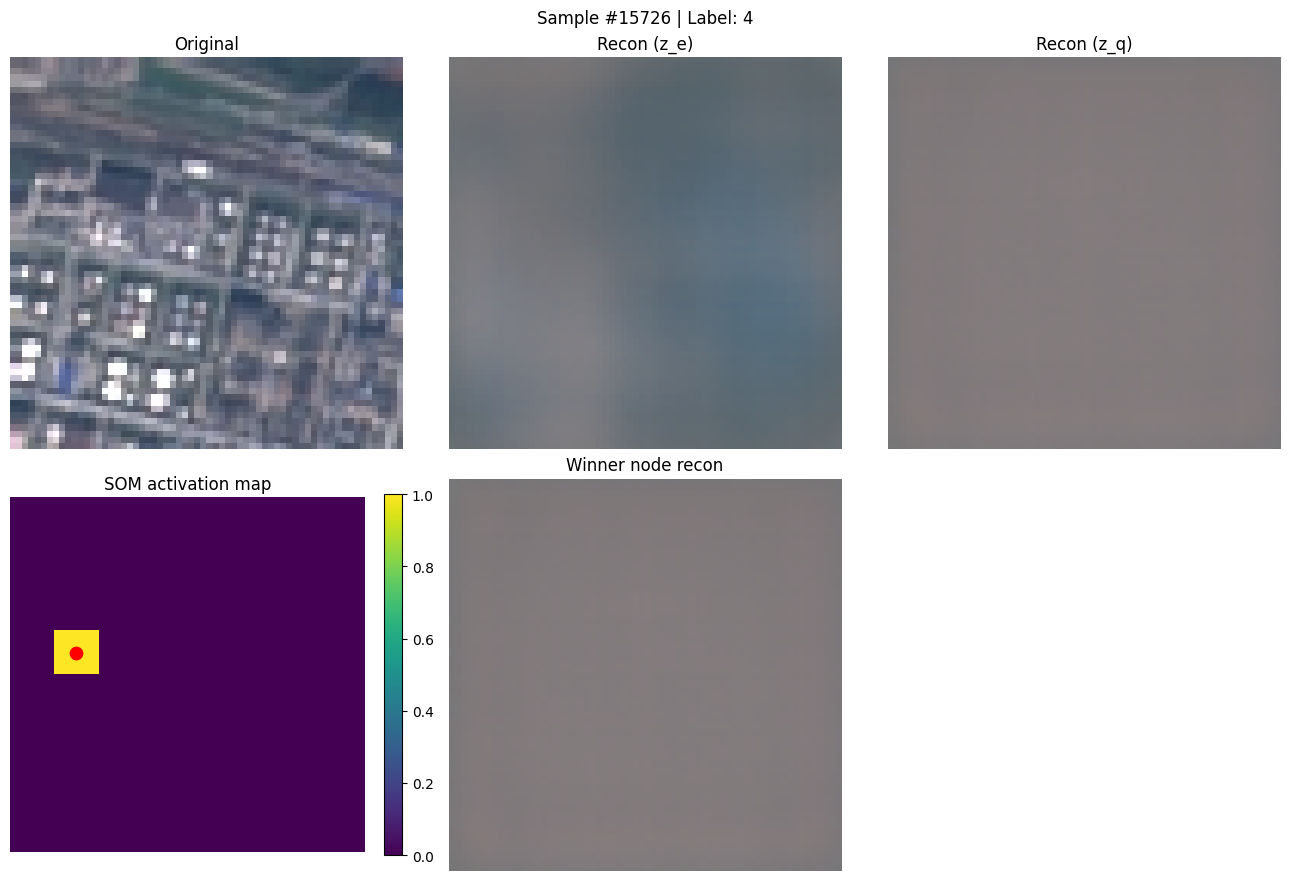

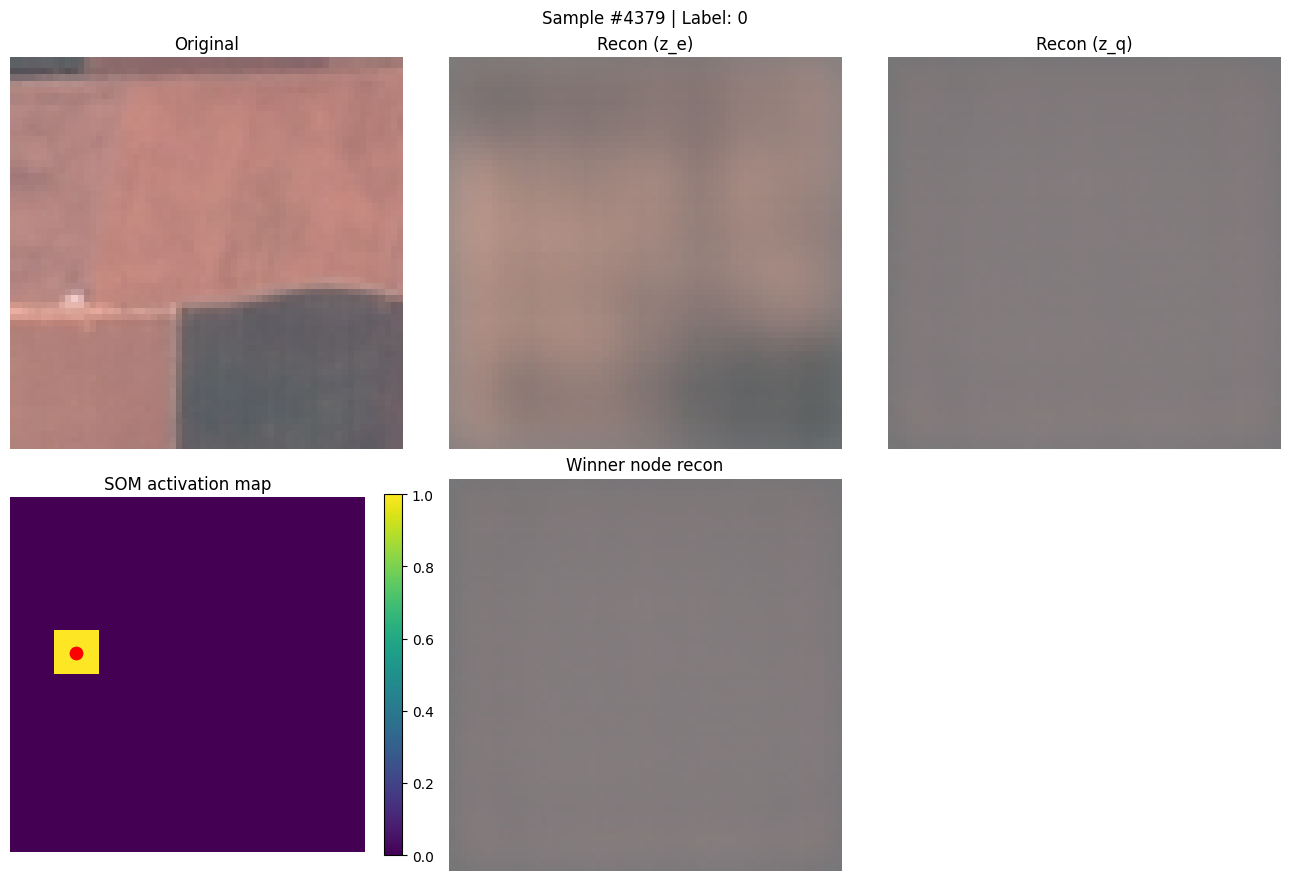

Epoch 17/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 17:
Train: 0.103 | Val: 0.10860707524210908 | NMI: 0.2533


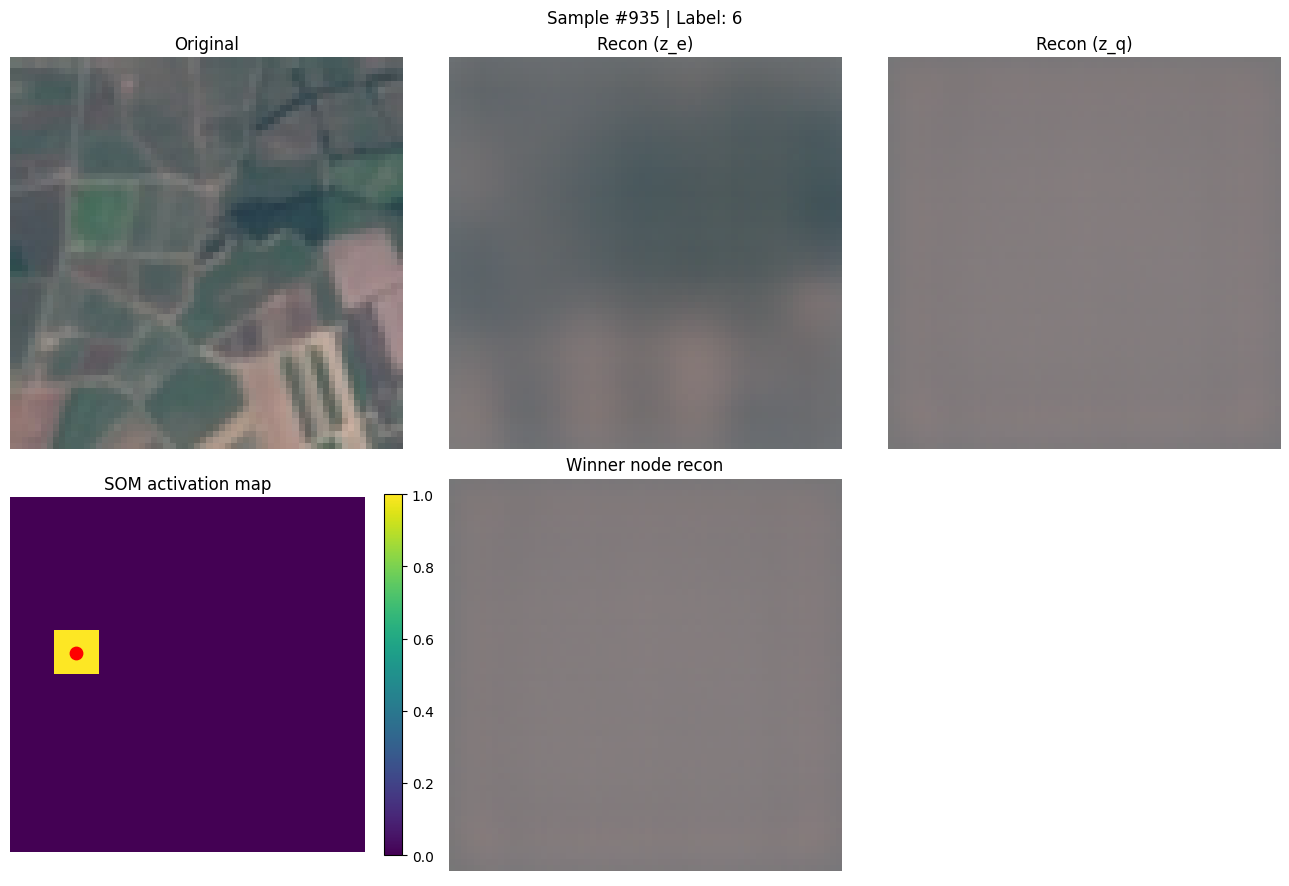

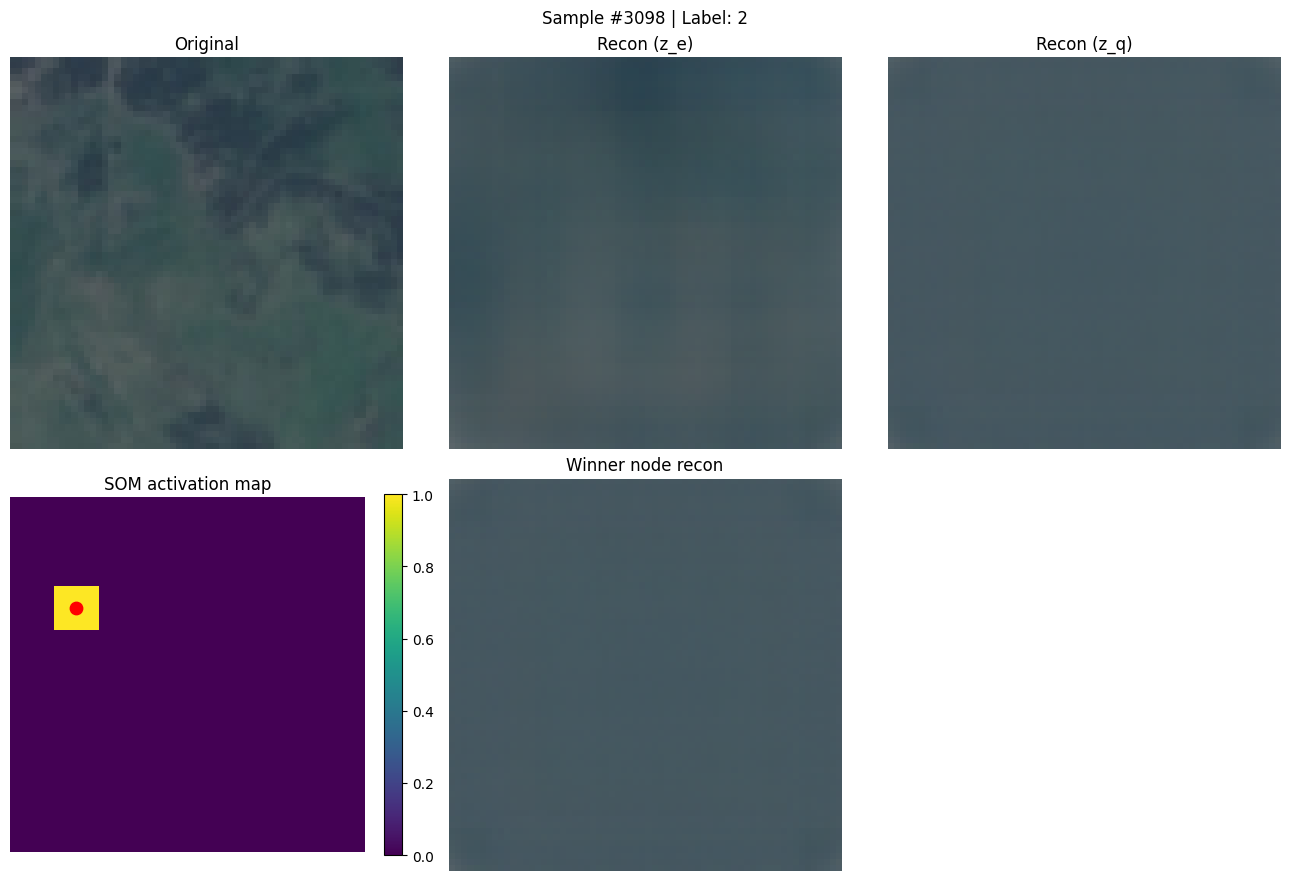

Epoch 18/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 18:
Train: 0.102 | Val: 0.09815805959840153 | NMI: 0.2838


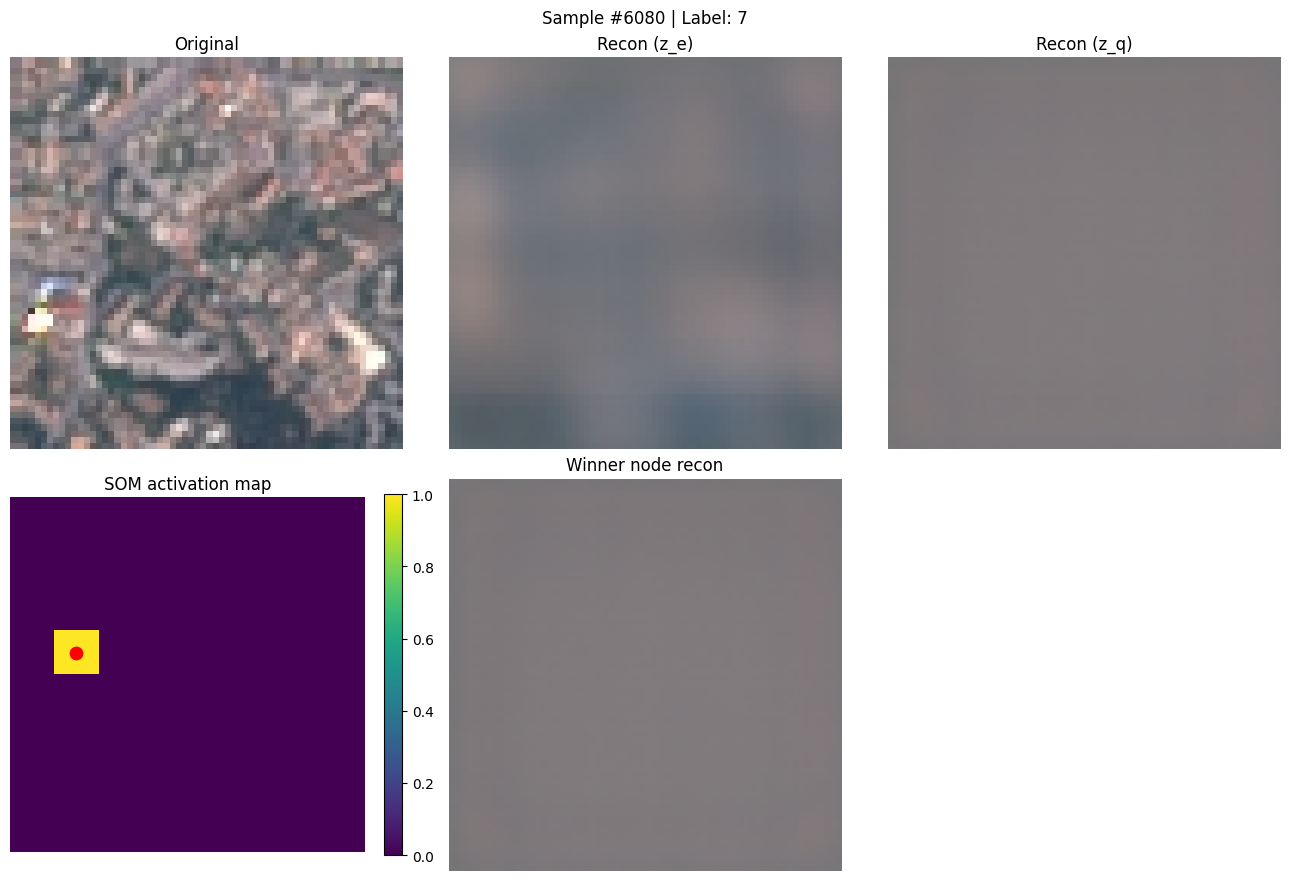

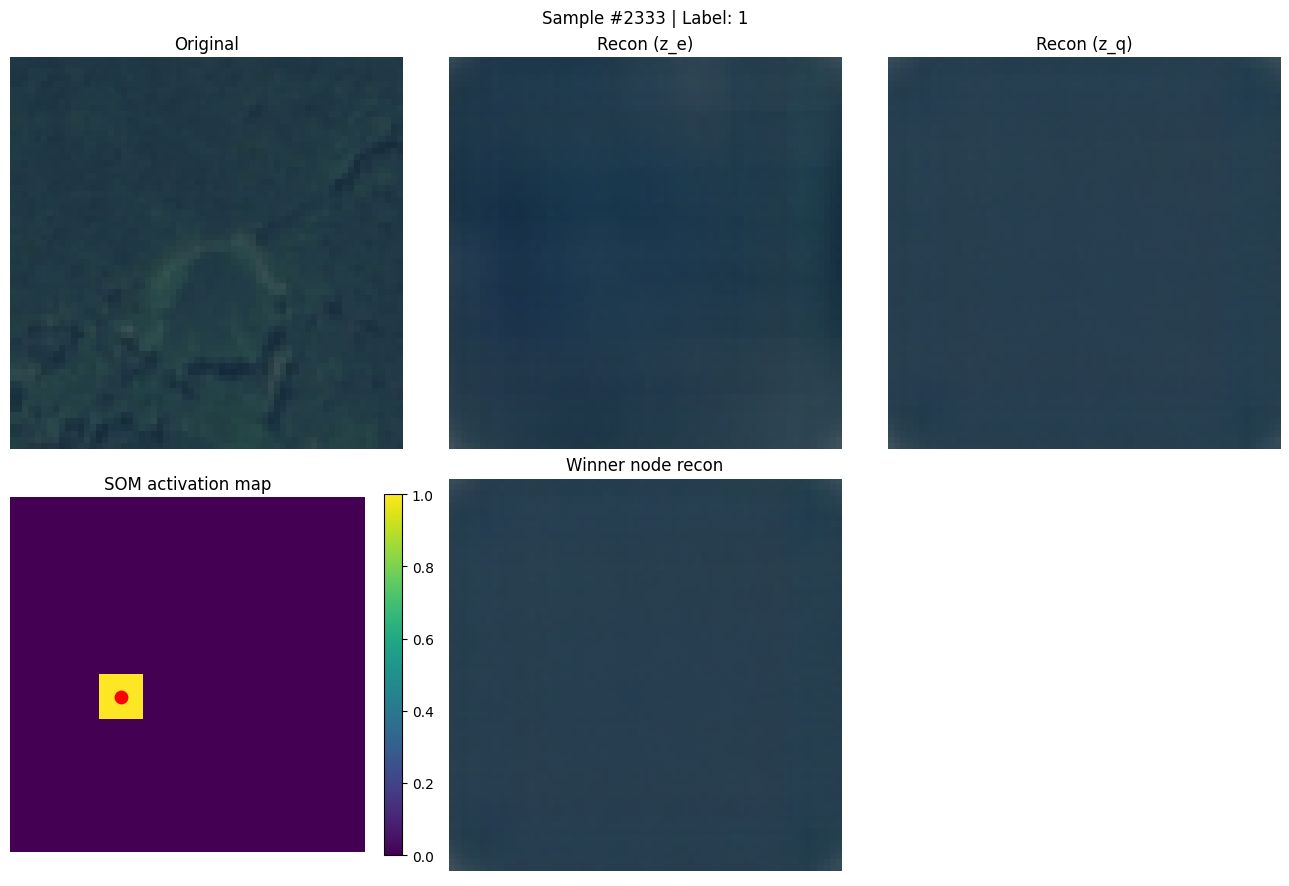

Epoch 19/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 19:
Train: 0.104 | Val: 0.10497869118008503 | NMI: 0.2834


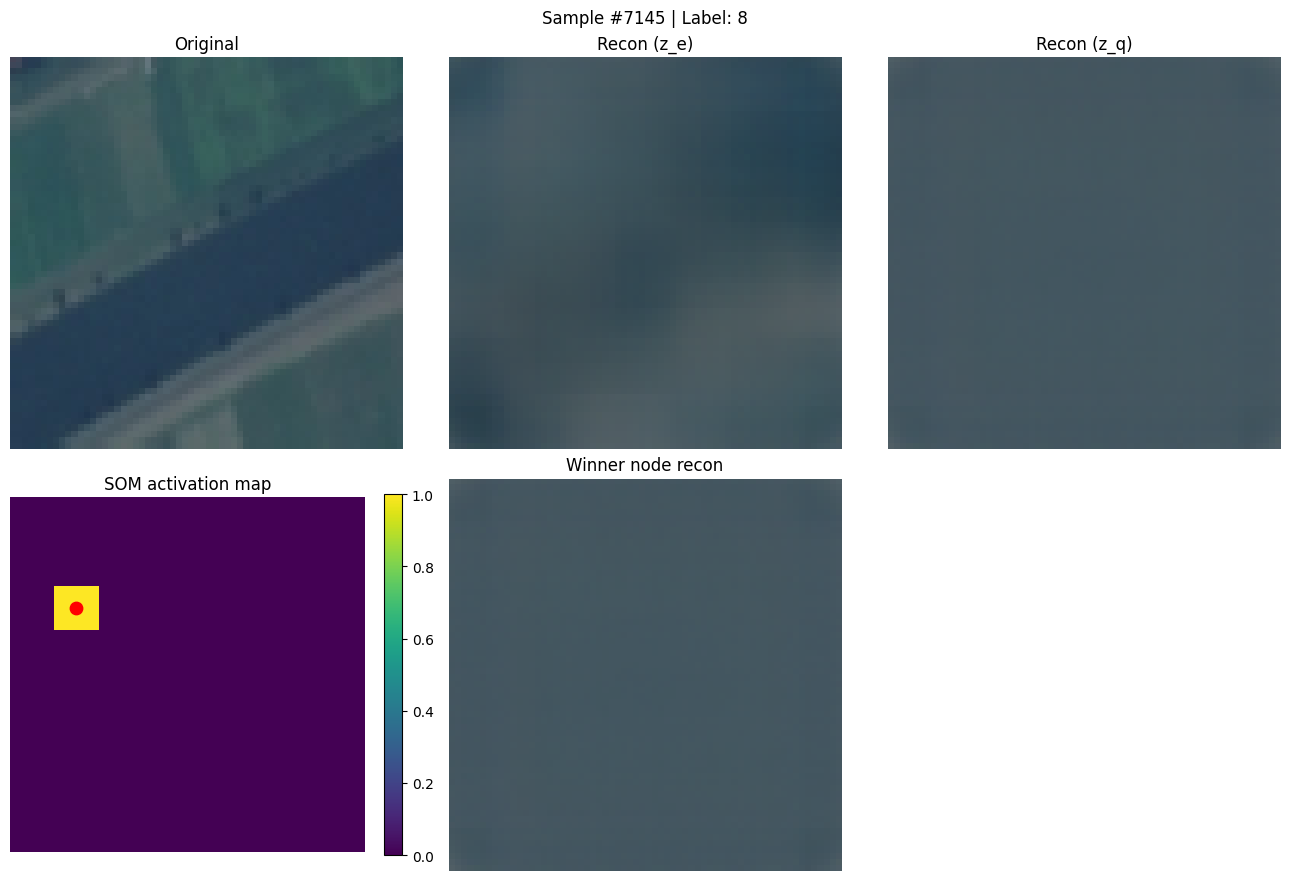

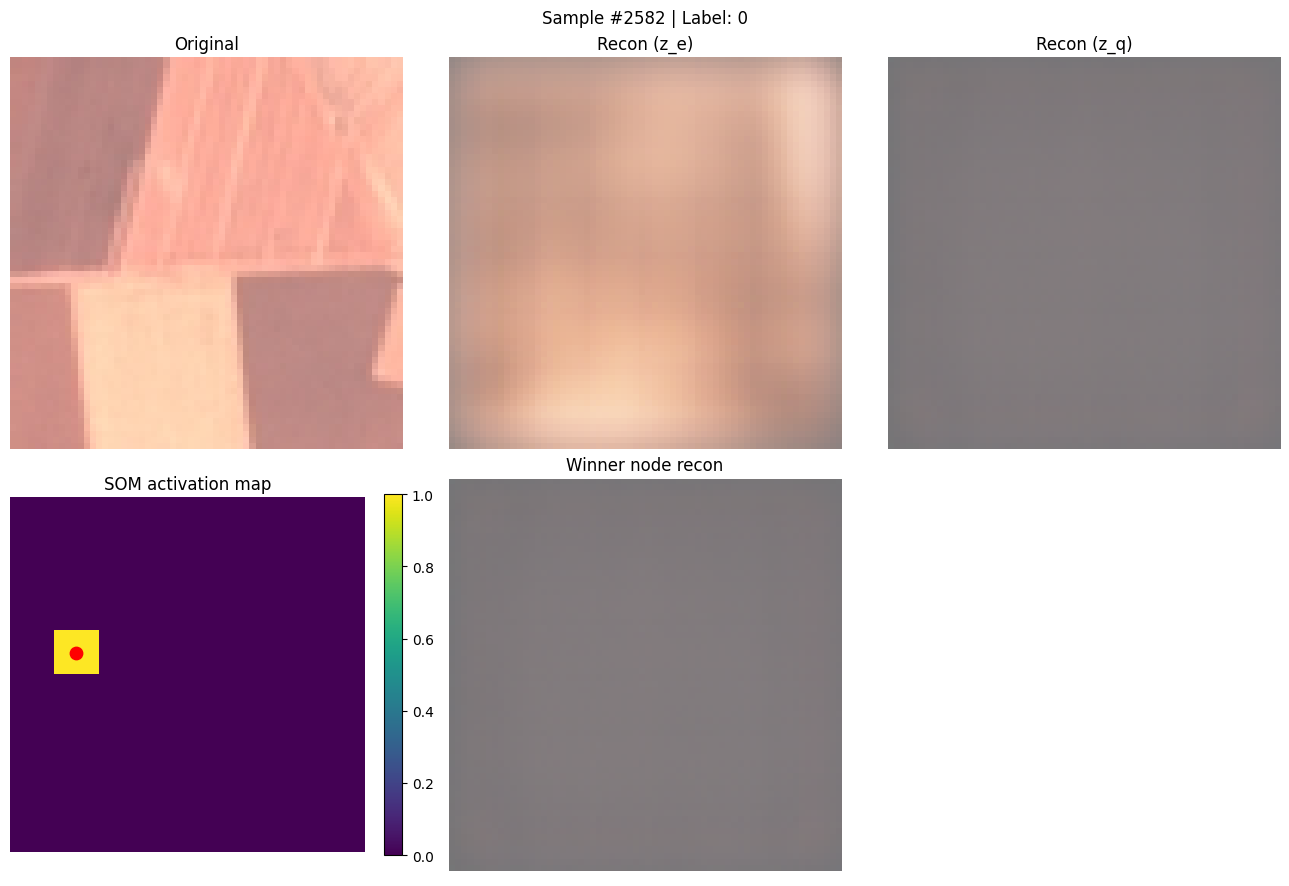

Epoch 20/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 20:
Train: 0.100 | Val: 0.09675260304018508 | NMI: 0.2737


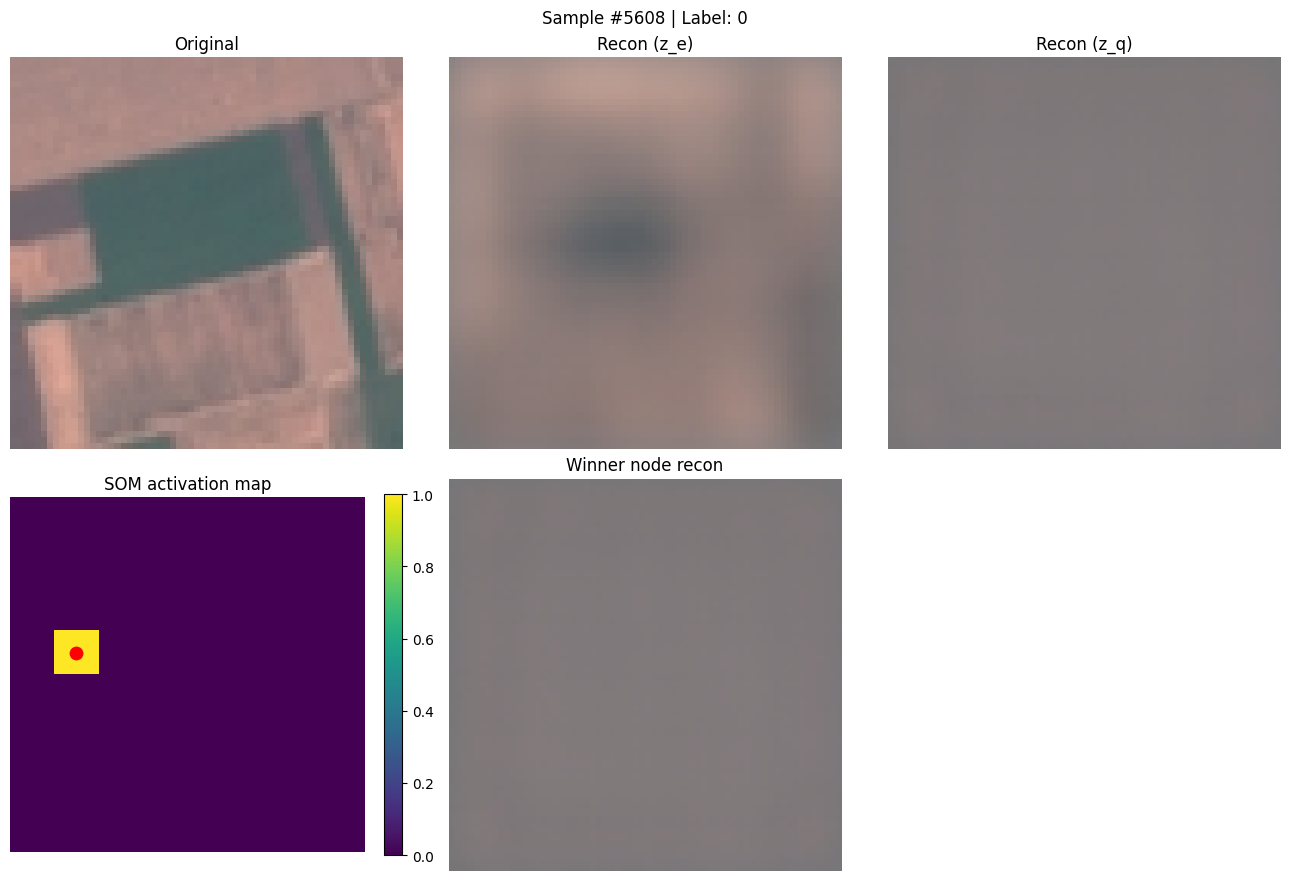

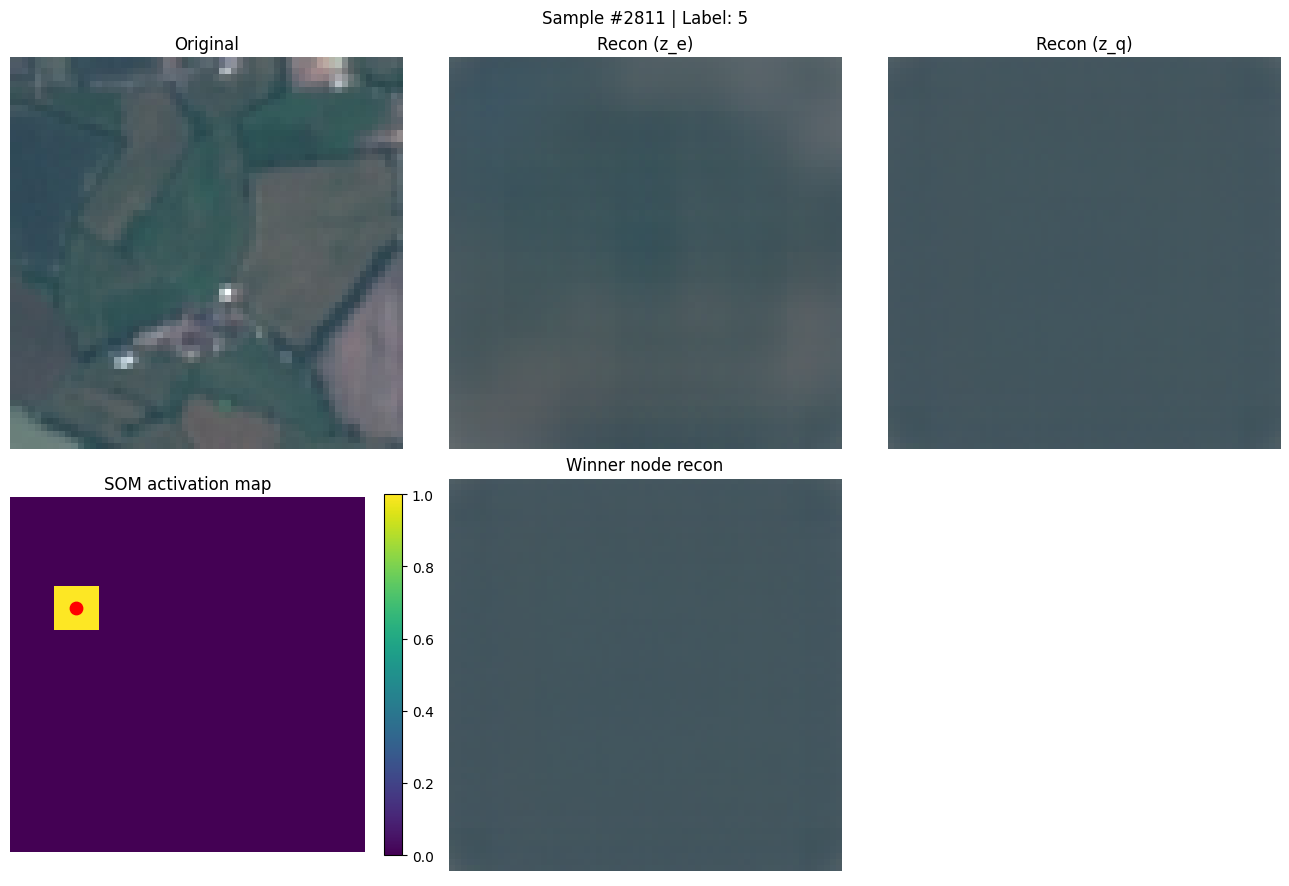

Epoch 21/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 21:
Train: 0.098 | Val: 0.11116328055775443 | NMI: 0.2534


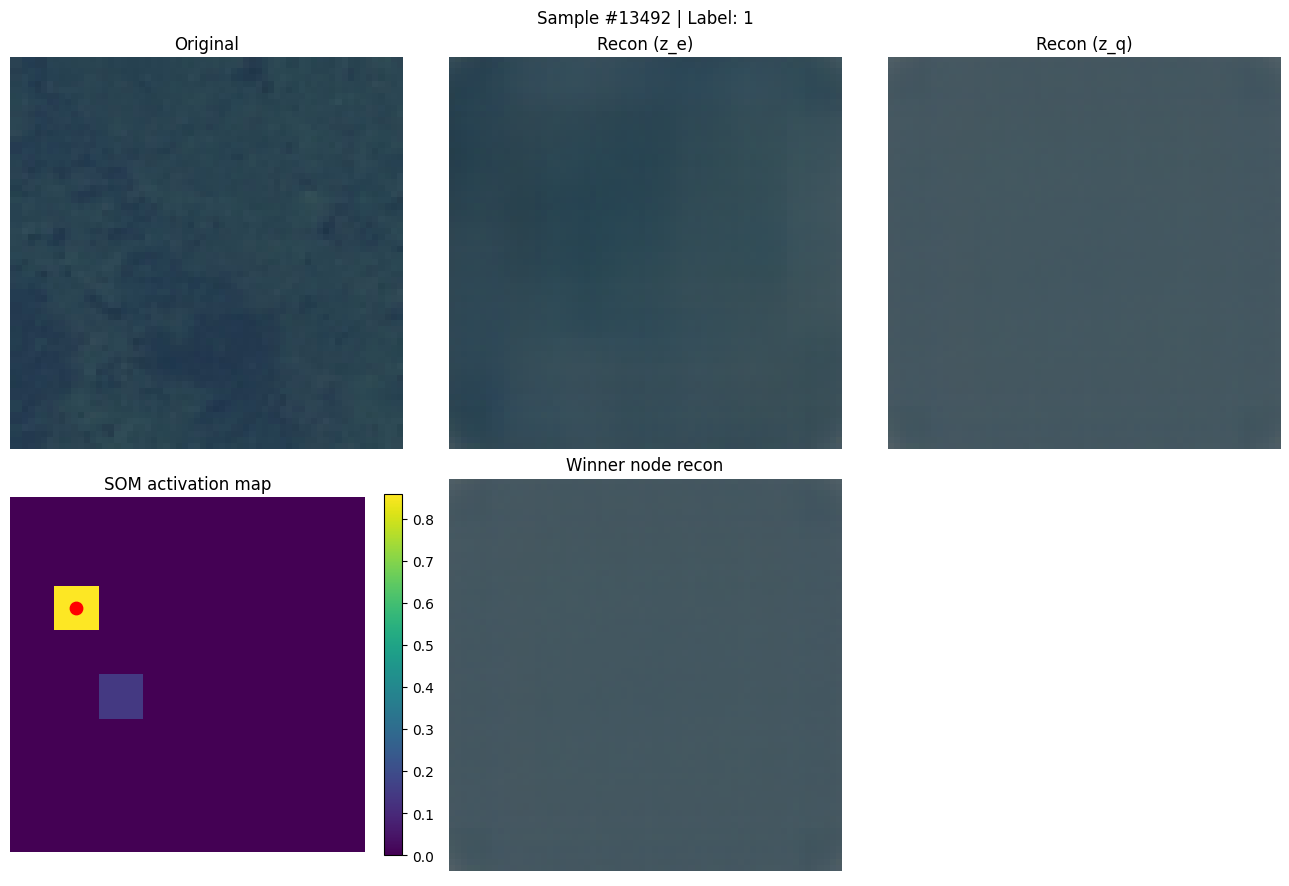

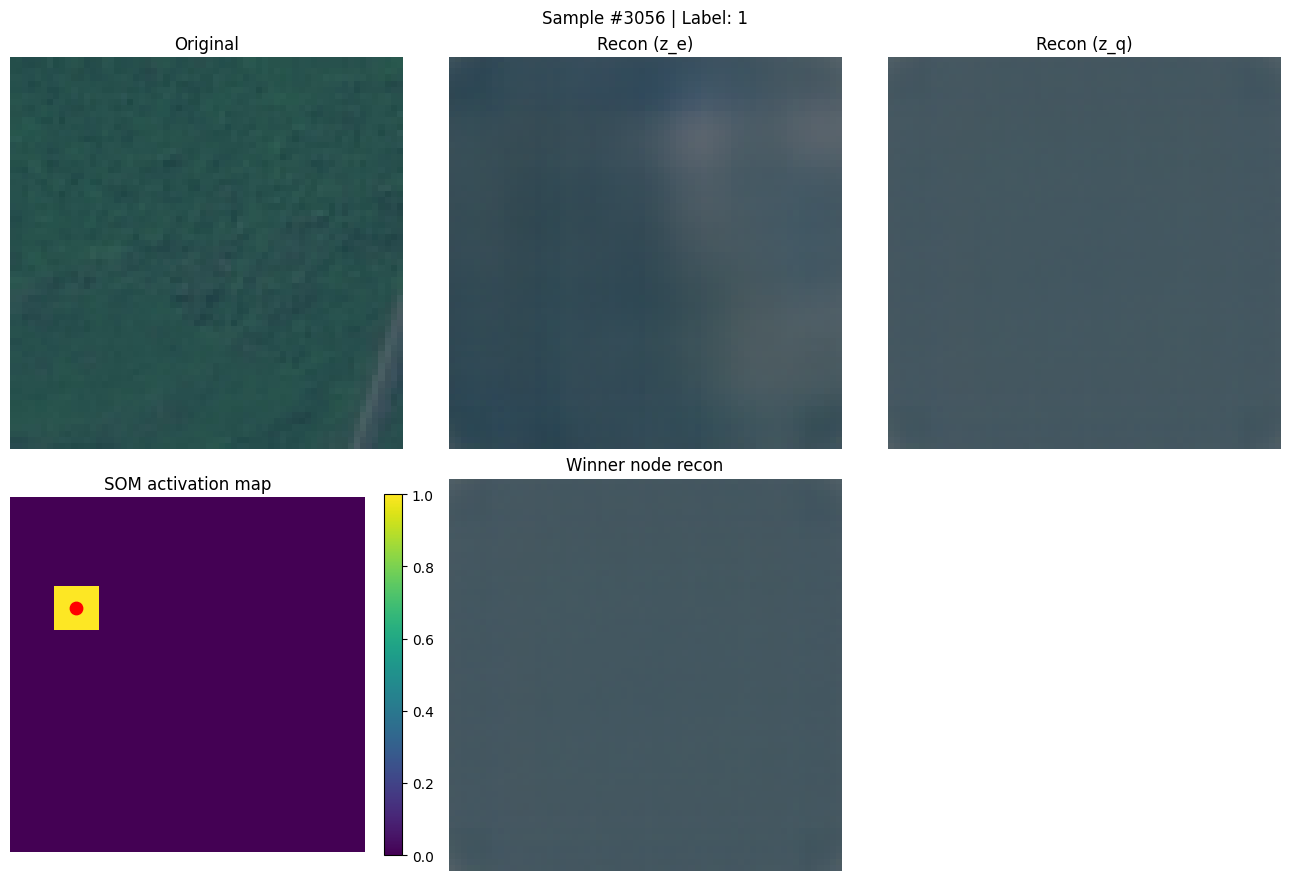

Epoch 22/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 22:
Train: 0.098 | Val: 0.09537972388572472 | NMI: 0.2816


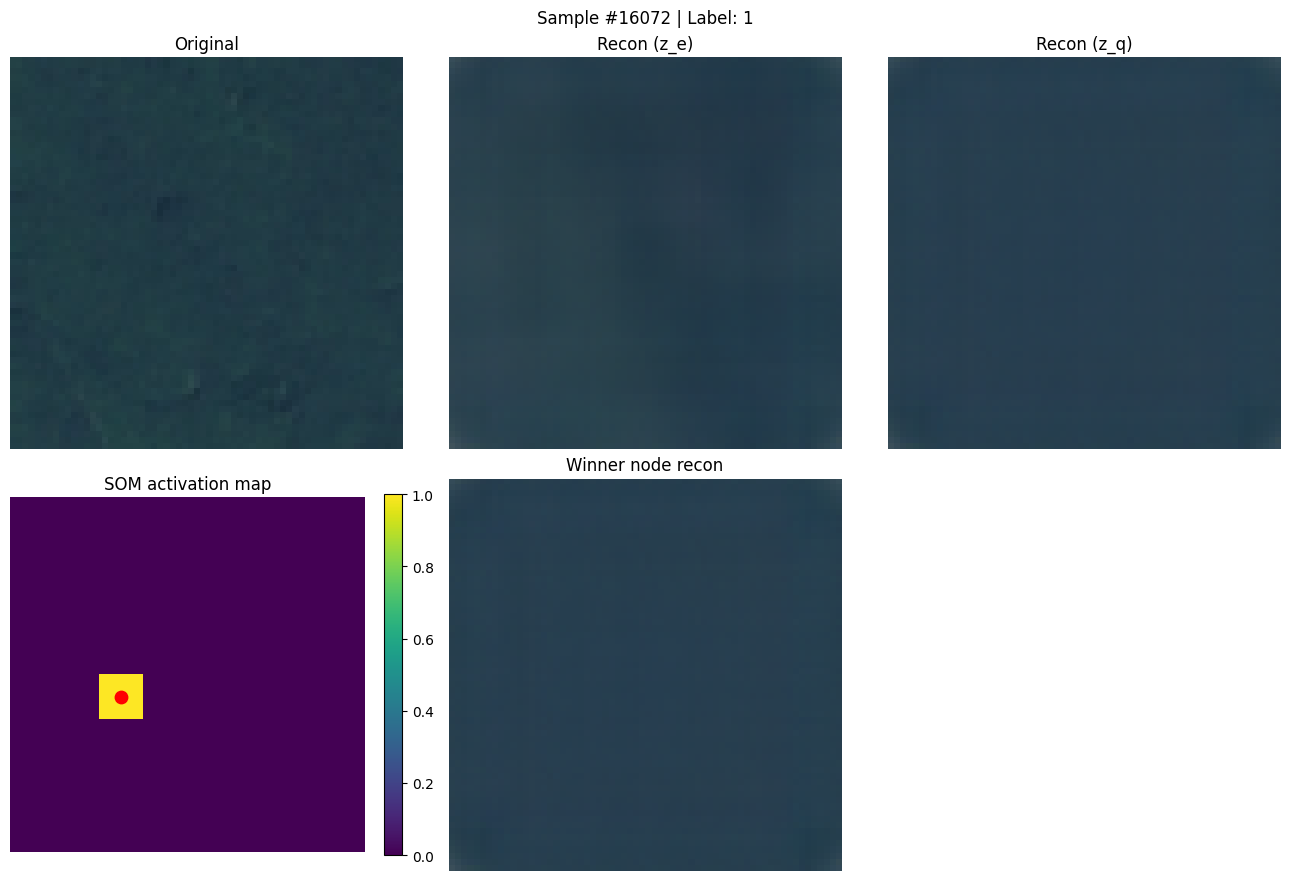

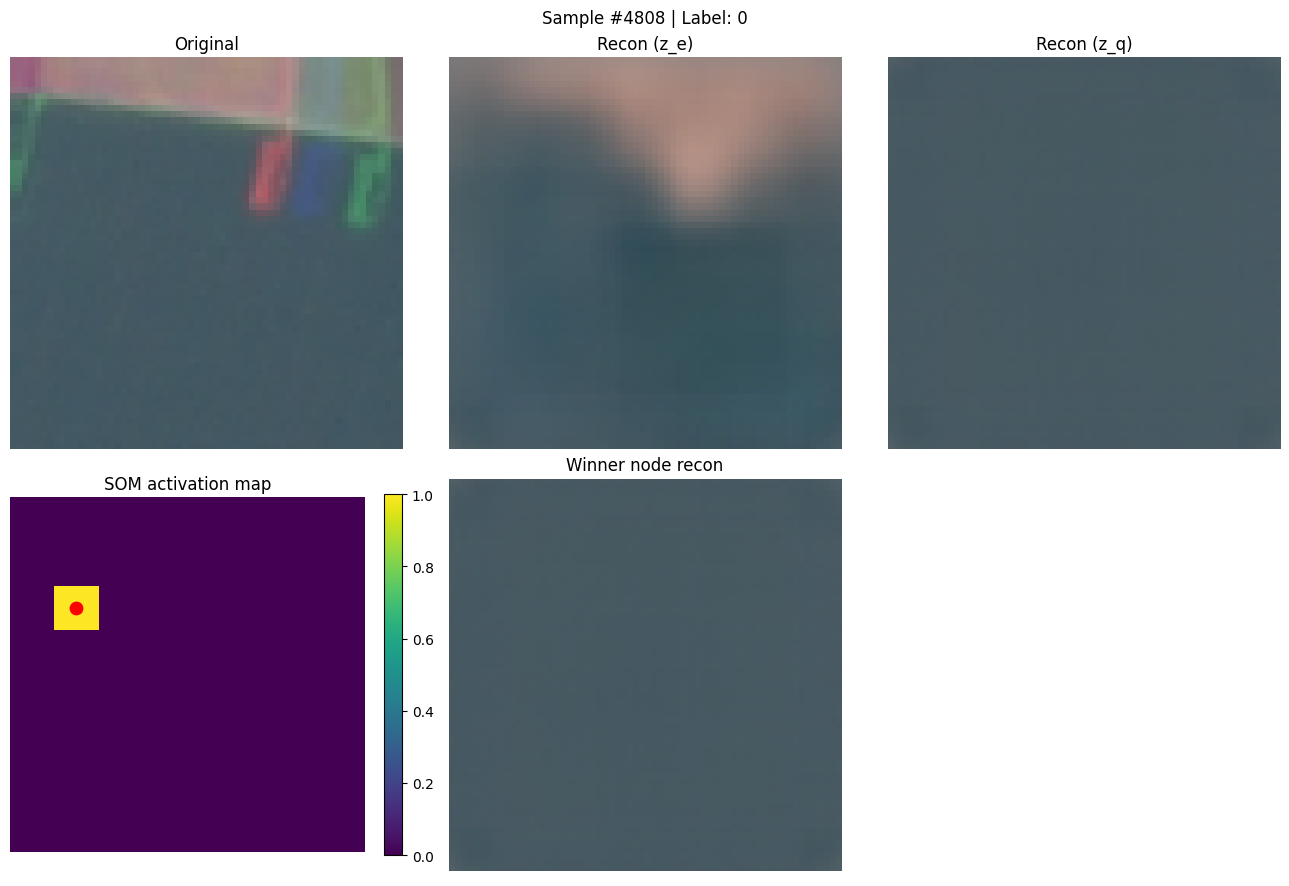

Epoch 23/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 23:
Train: 0.095 | Val: 0.0930283360703047 | NMI: 0.2866


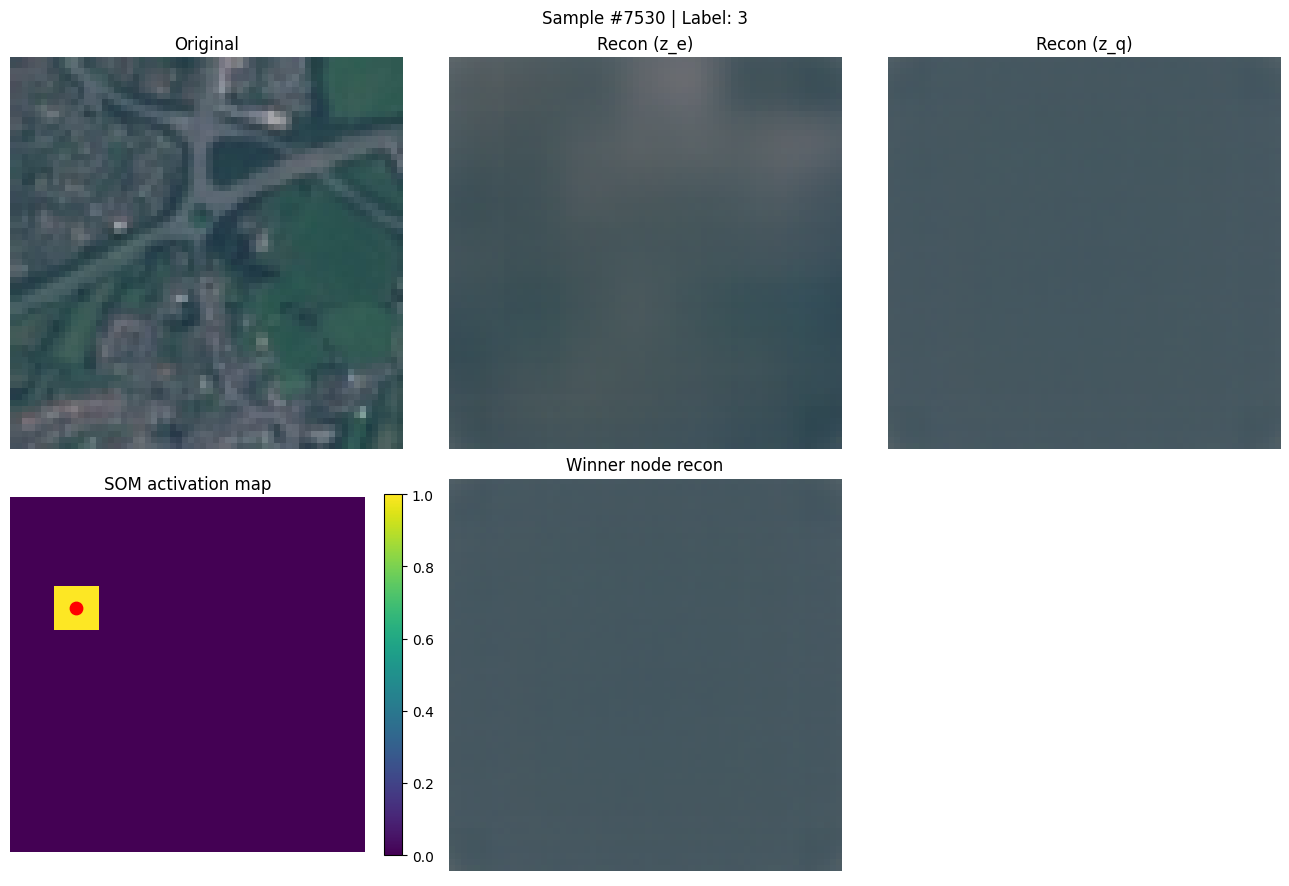

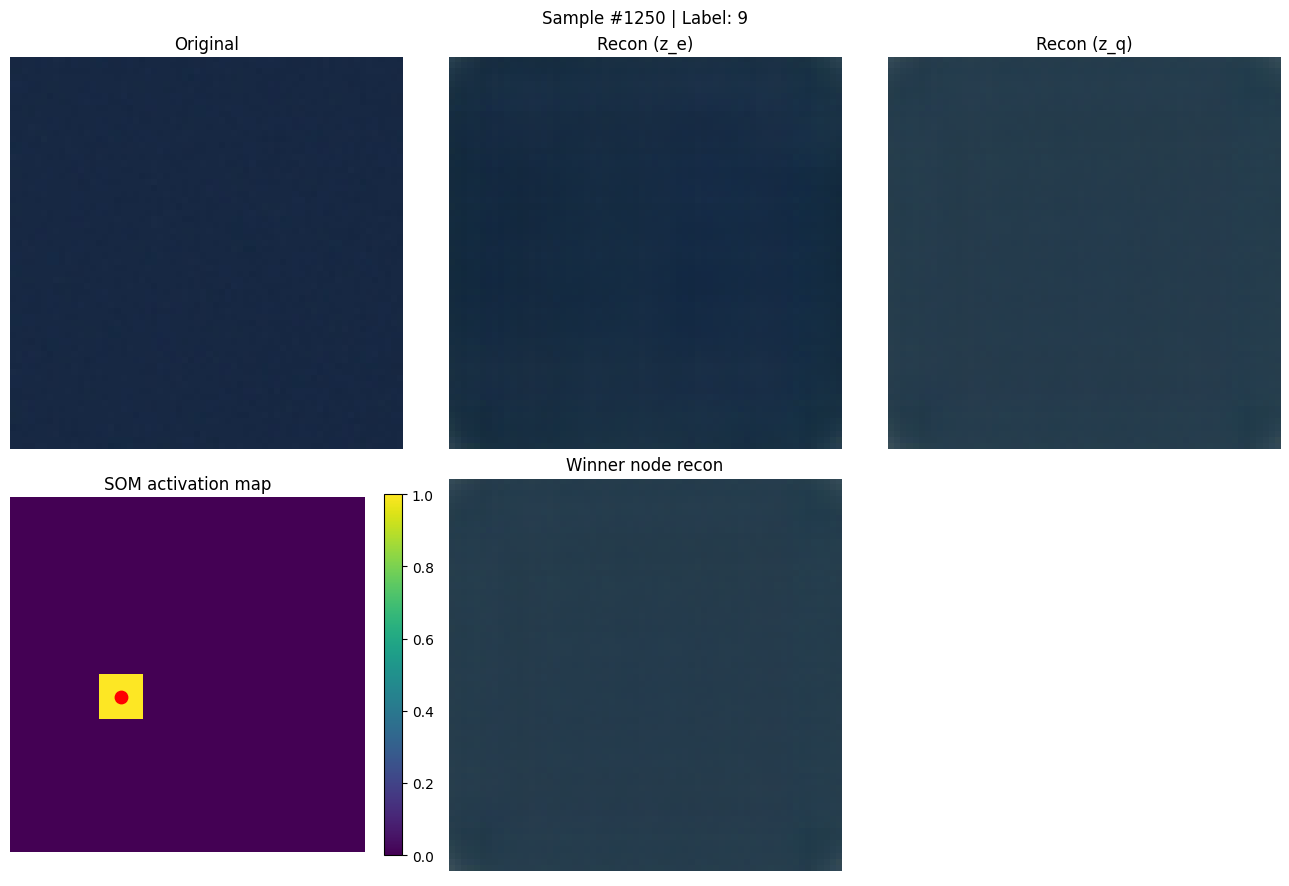

Epoch 24/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 24:
Train: 0.093 | Val: 0.10074766014897546 | NMI: 0.2670


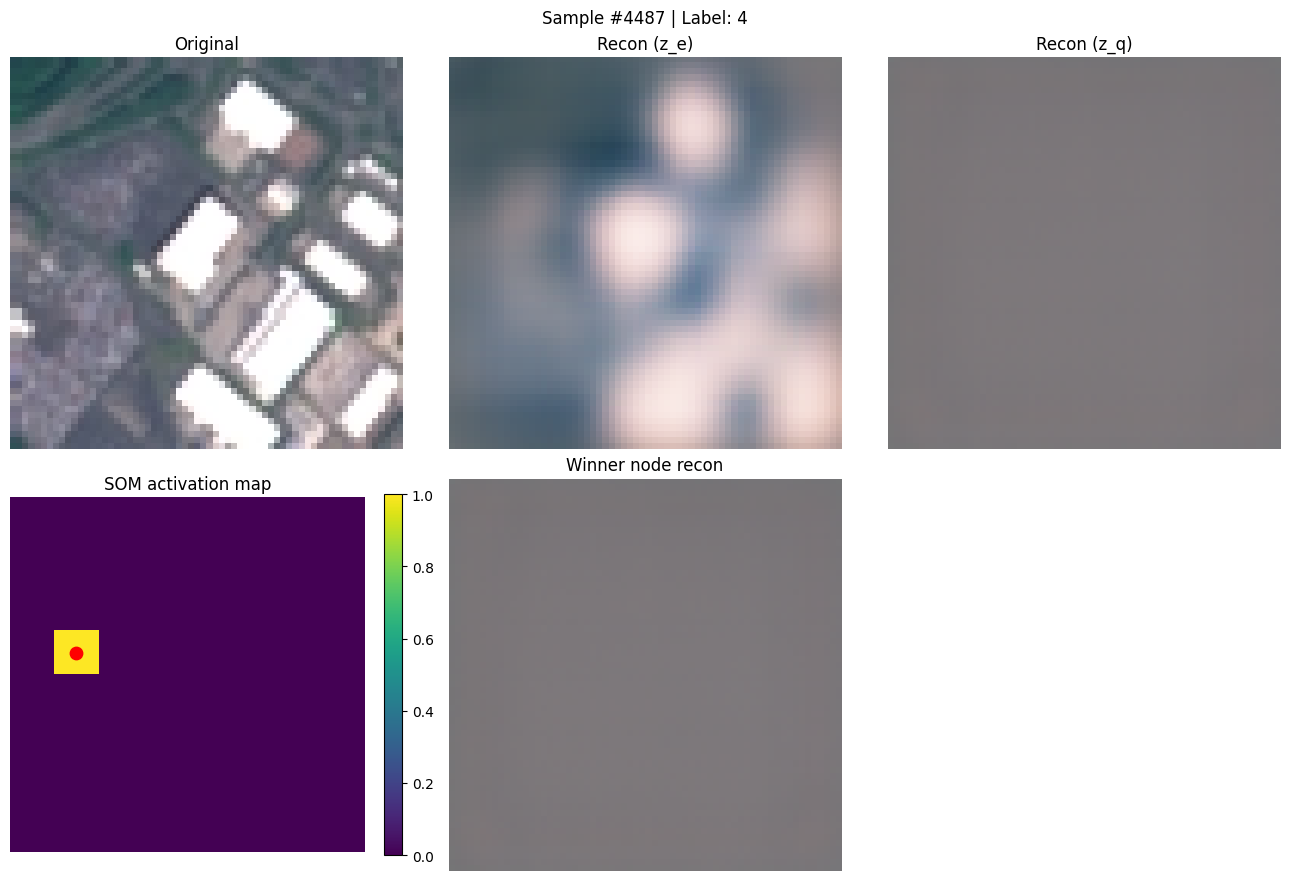

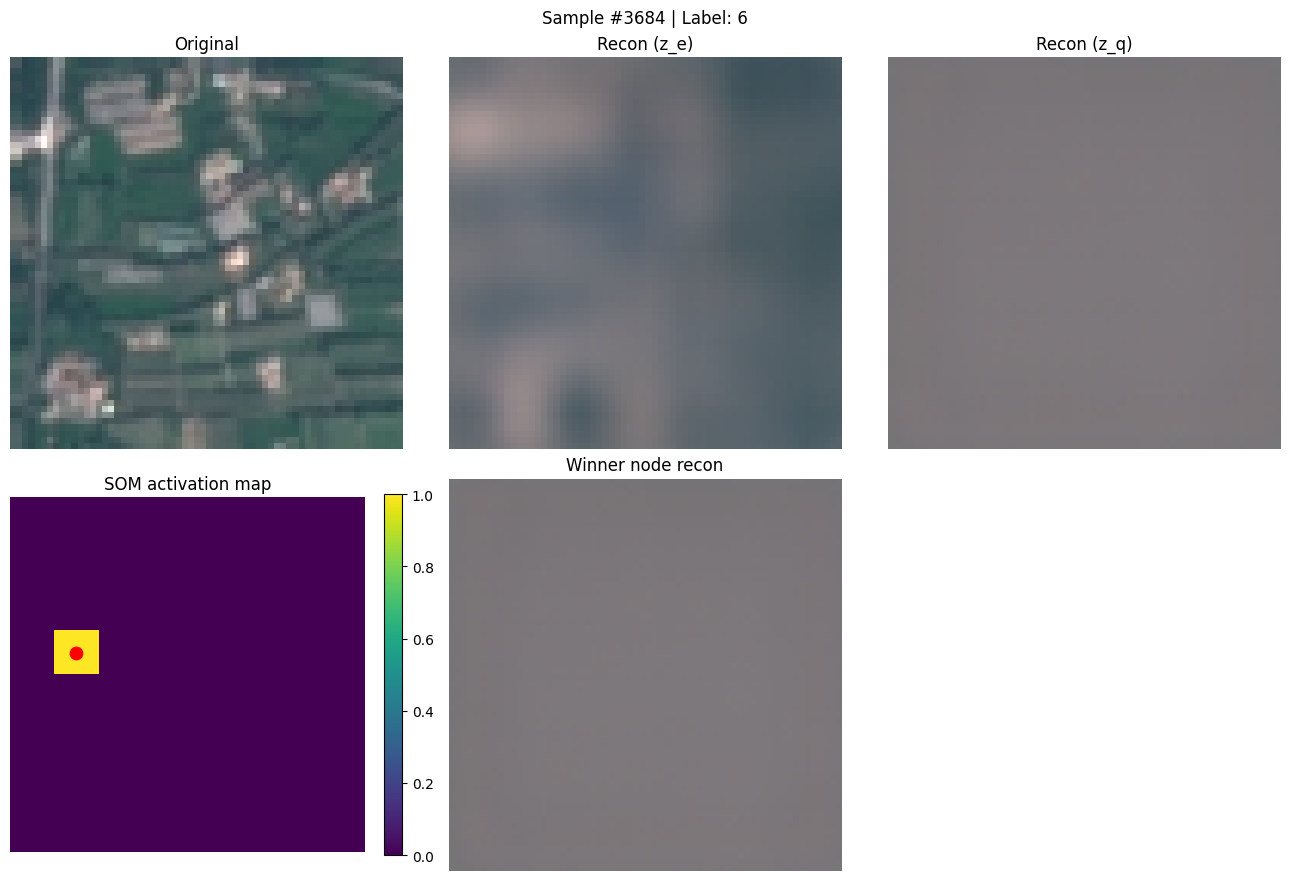

Epoch 25/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 25:
Train: 0.095 | Val: 0.0919017803876899 | NMI: 0.2890


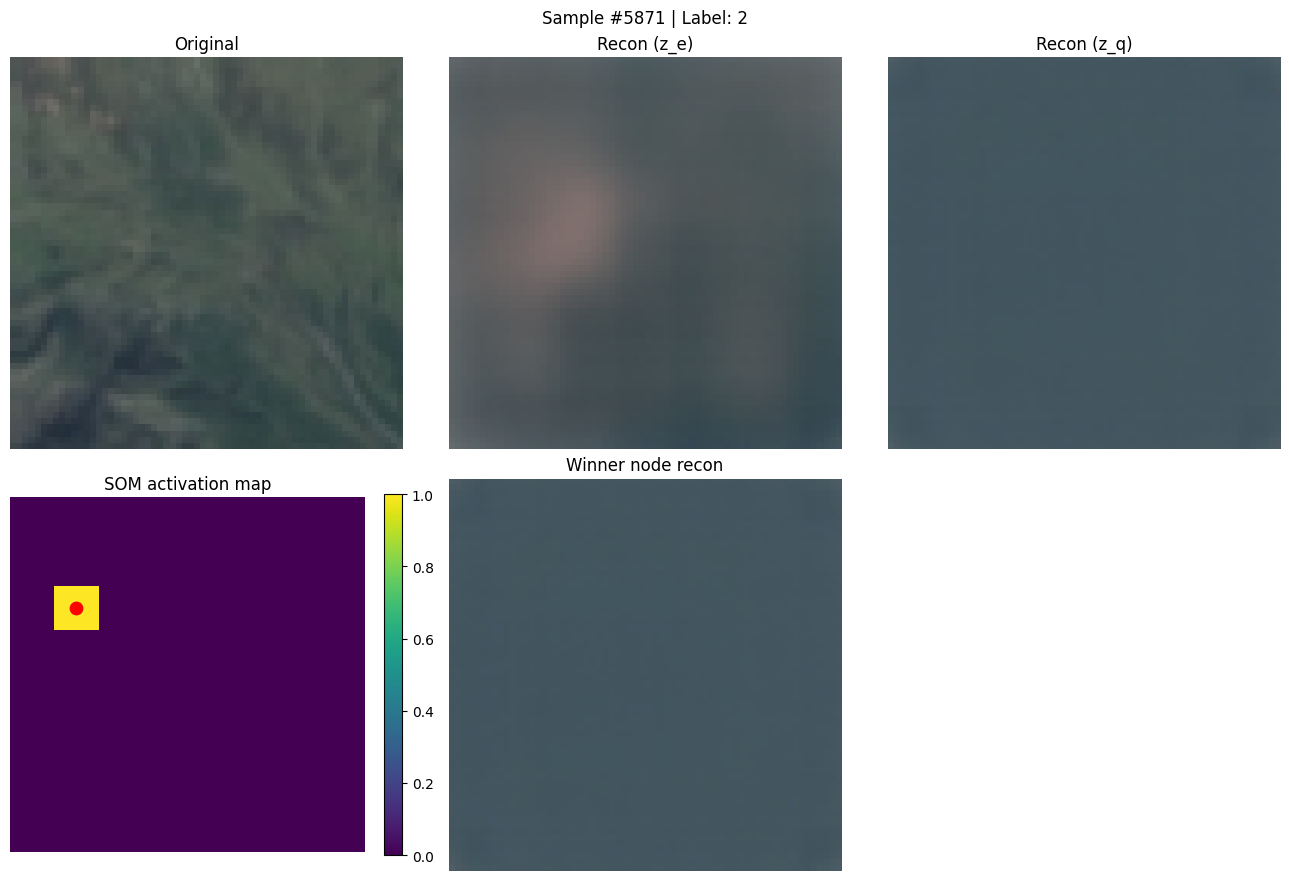

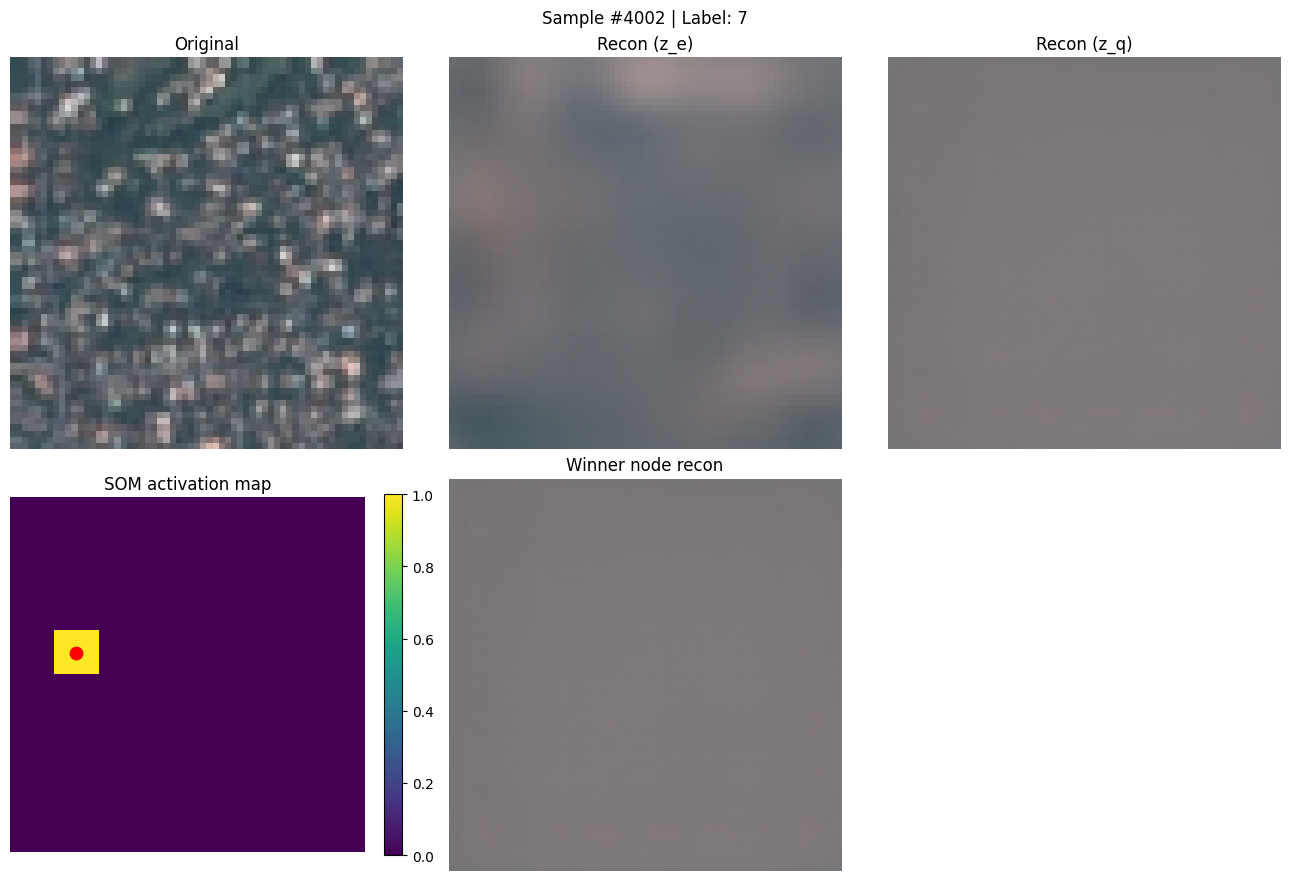

Epoch 26/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 26:
Train: 0.090 | Val: 0.0917421816739925 | NMI: 0.3034


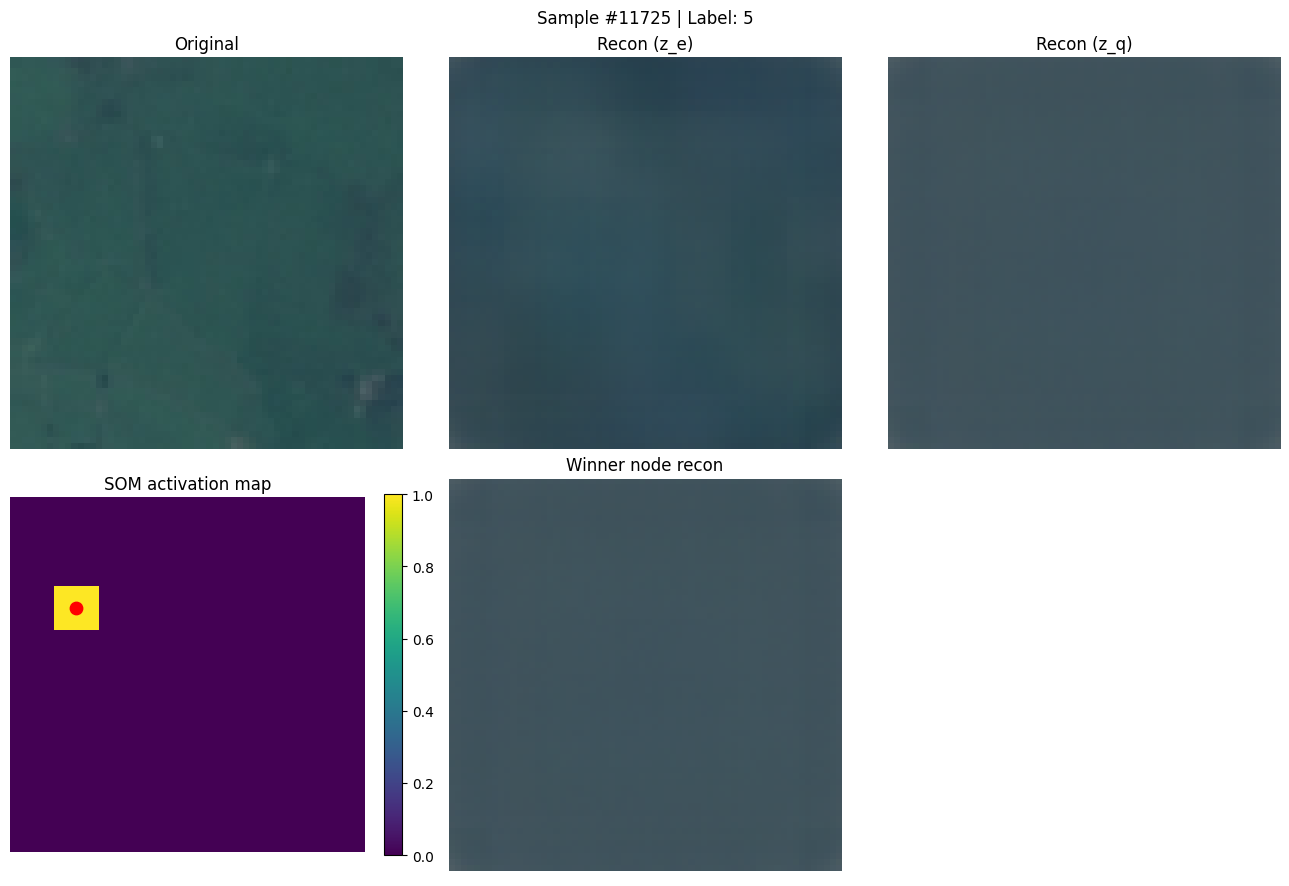

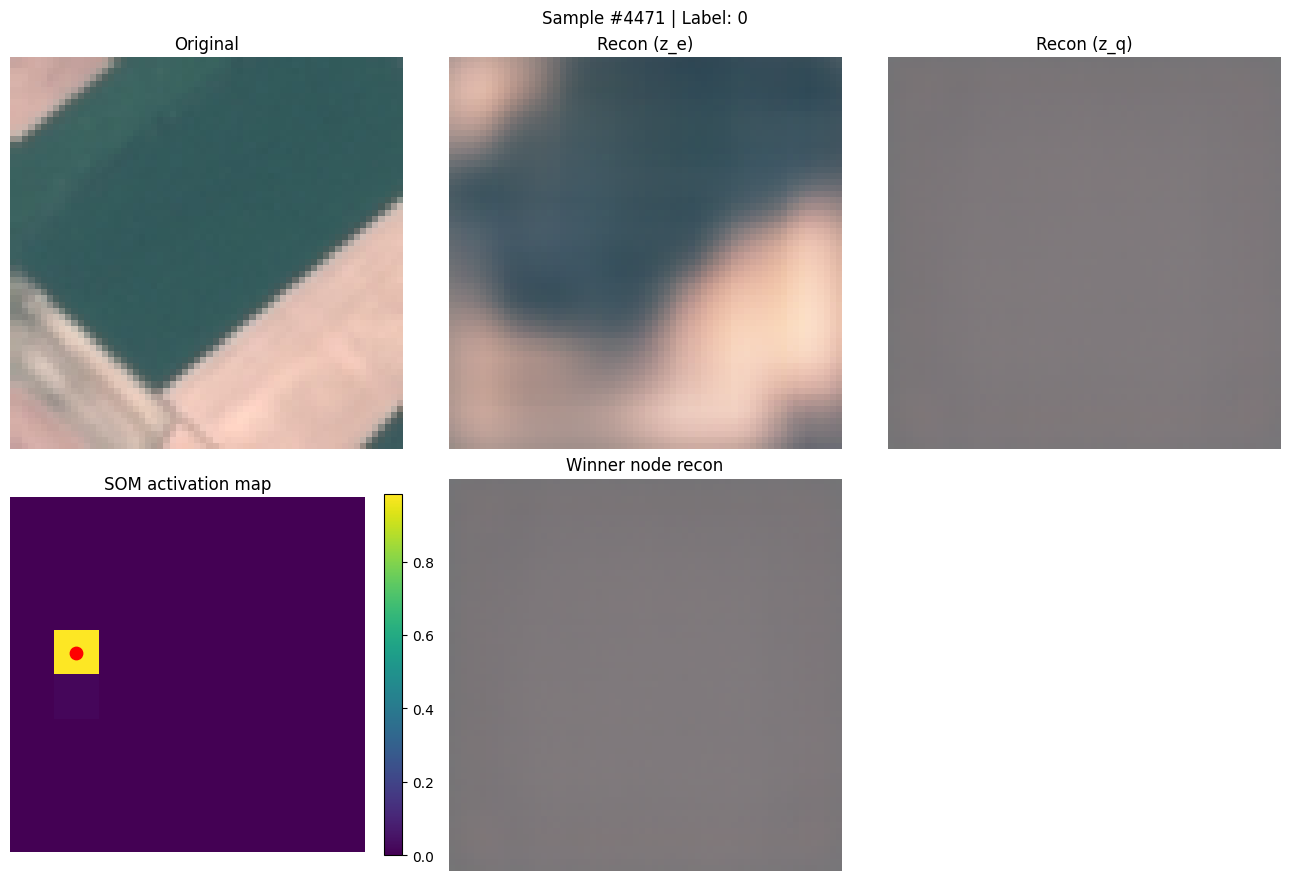

Epoch 27/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 27:
Train: 0.089 | Val: 0.08588023085233777 | NMI: 0.2939


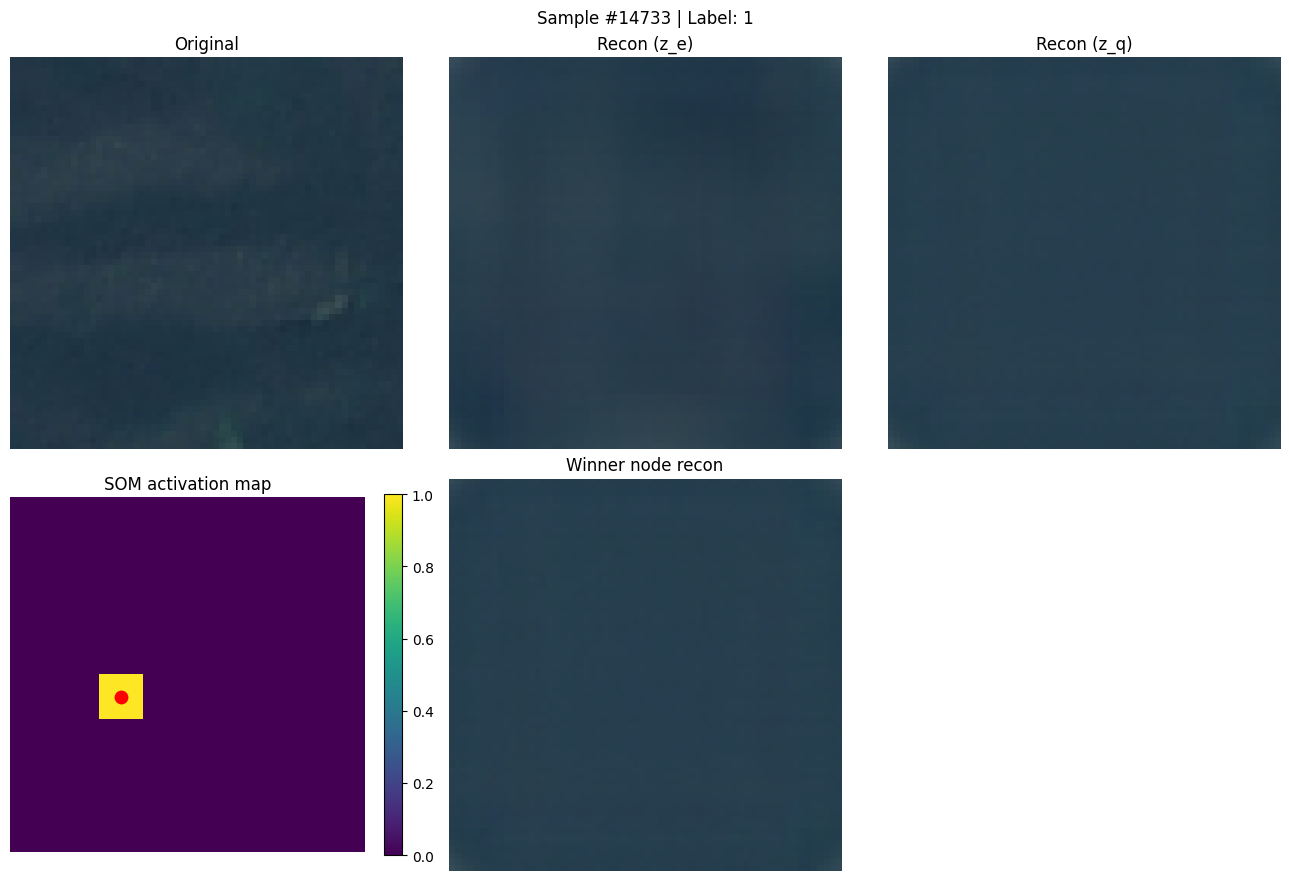

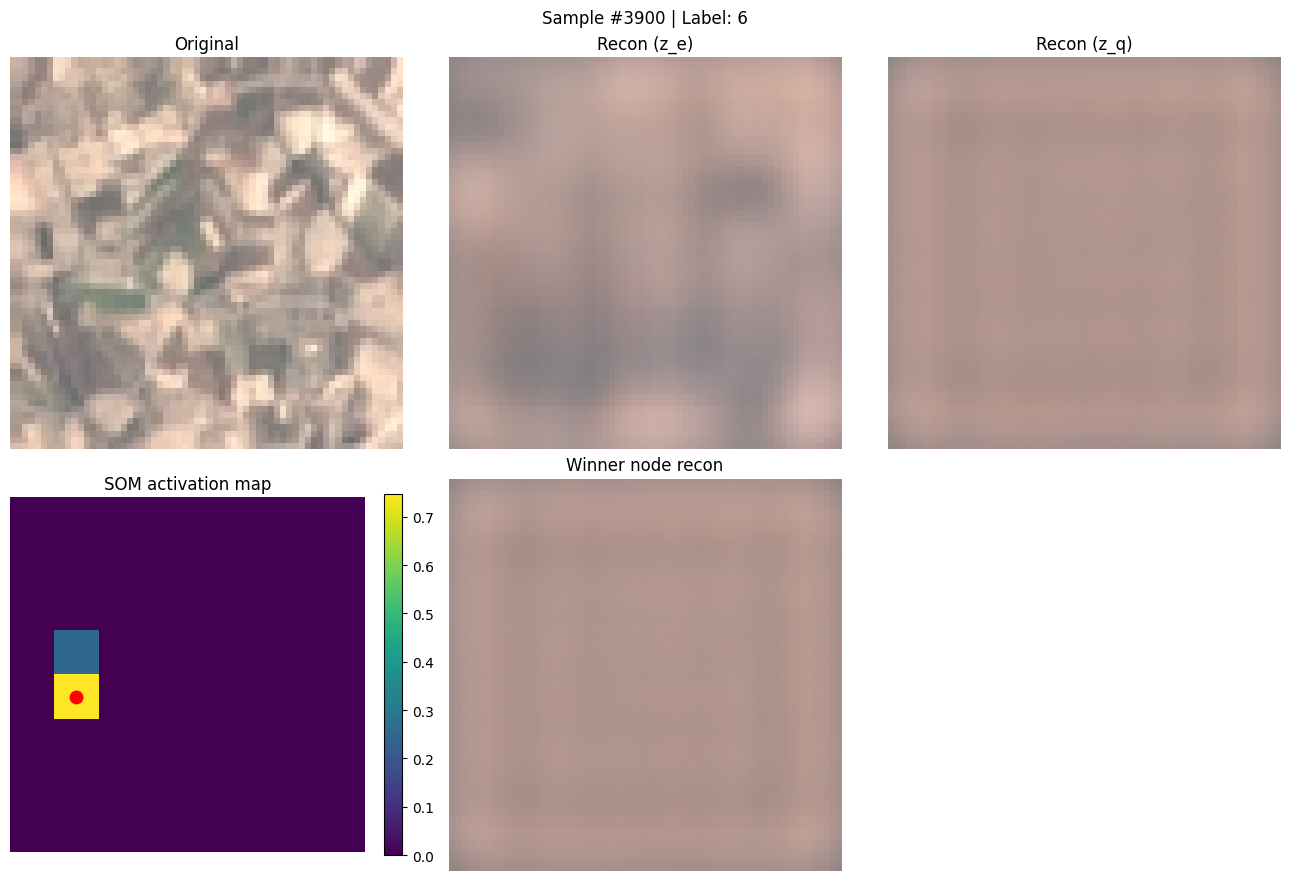

Epoch 28/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 28:
Train: 0.092 | Val: 0.10627592528282209 | NMI: 0.2716


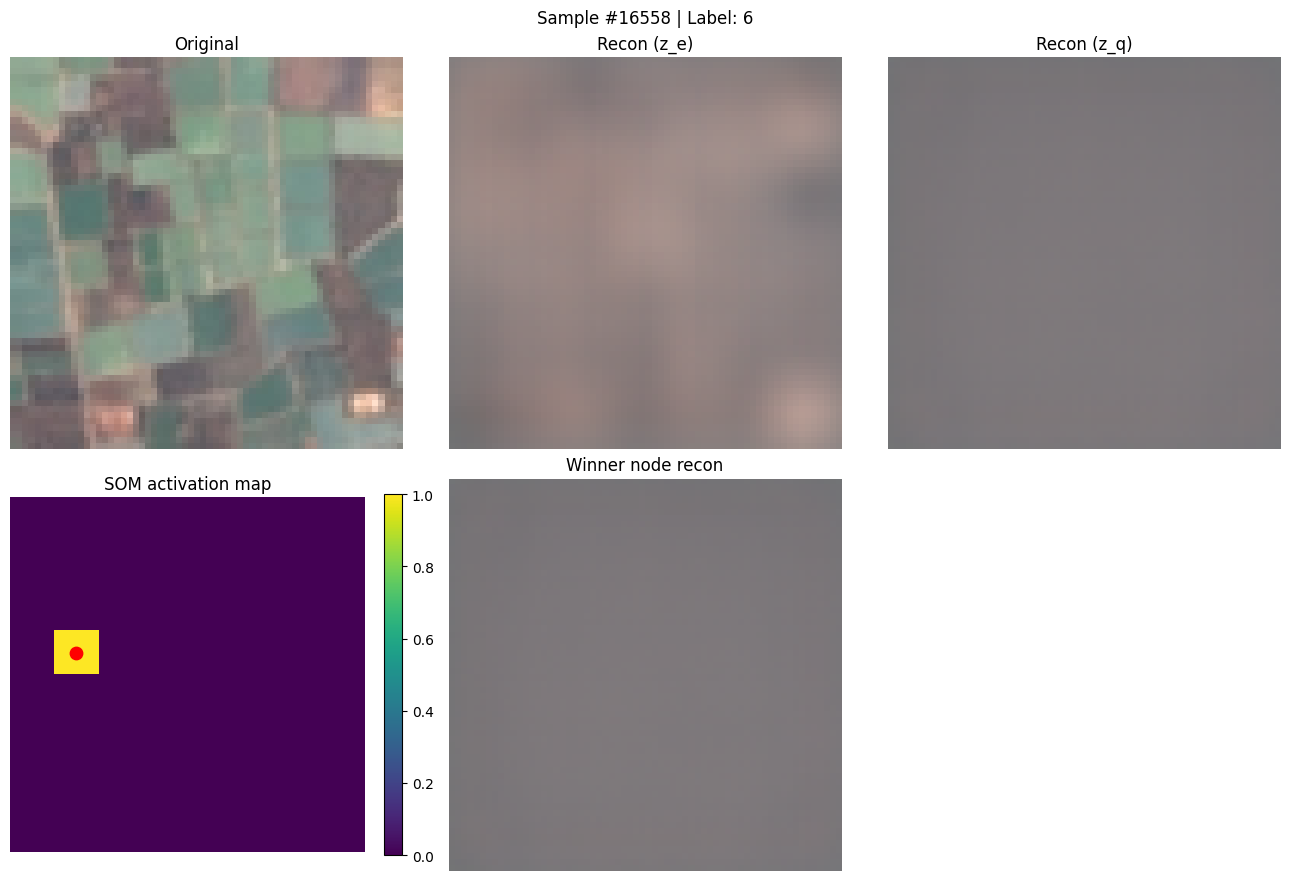

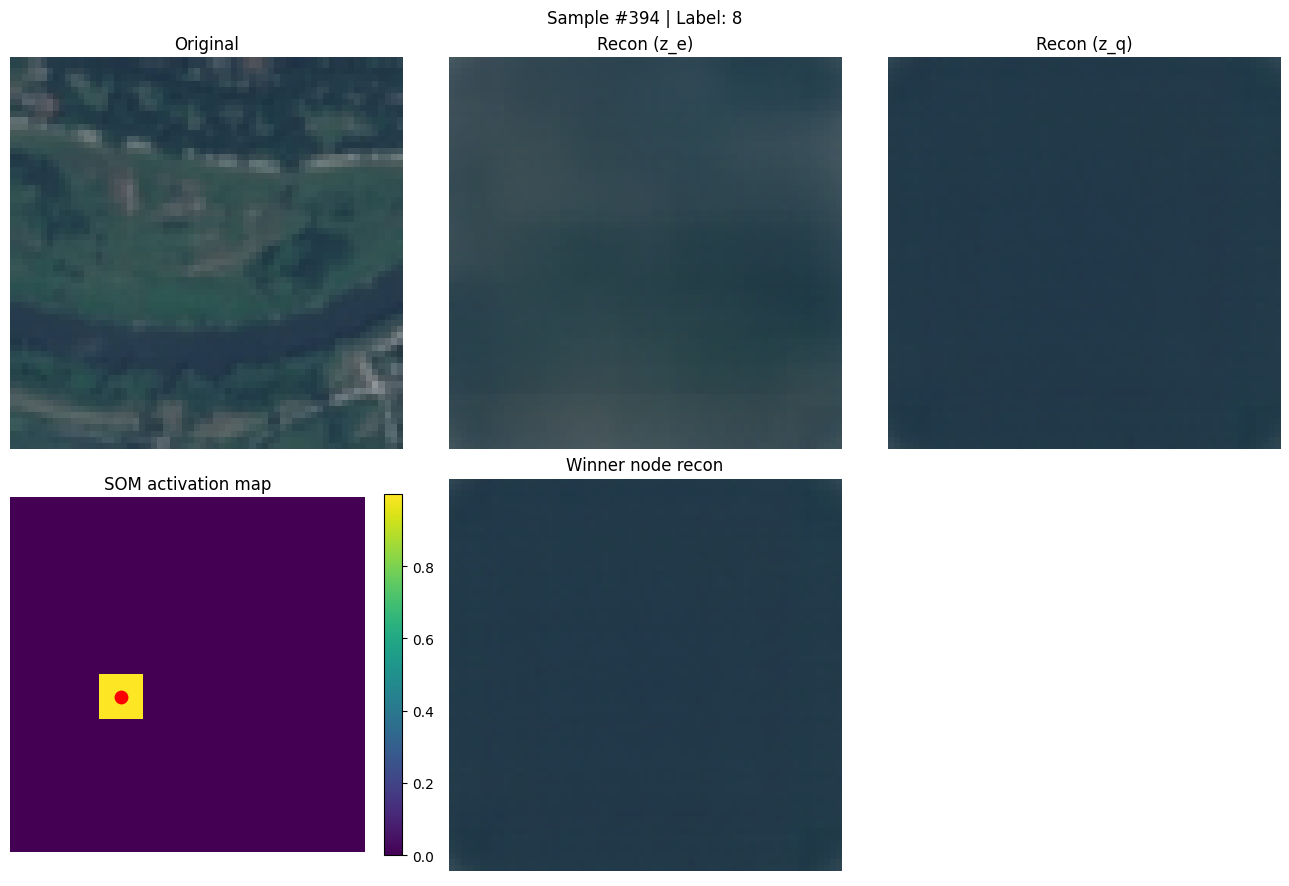

Epoch 29/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 29:
Train: 0.090 | Val: 0.08487625853266827 | NMI: 0.2829


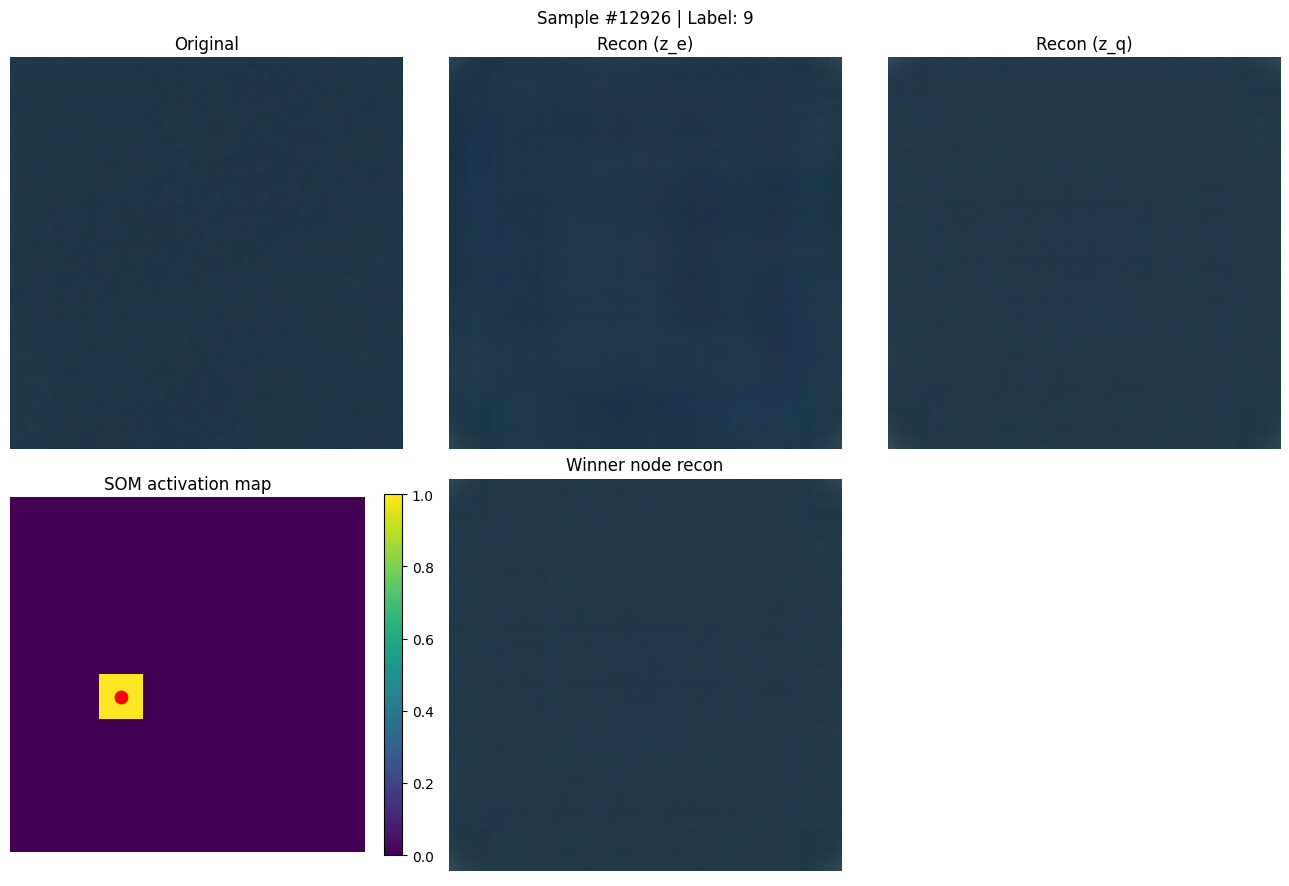

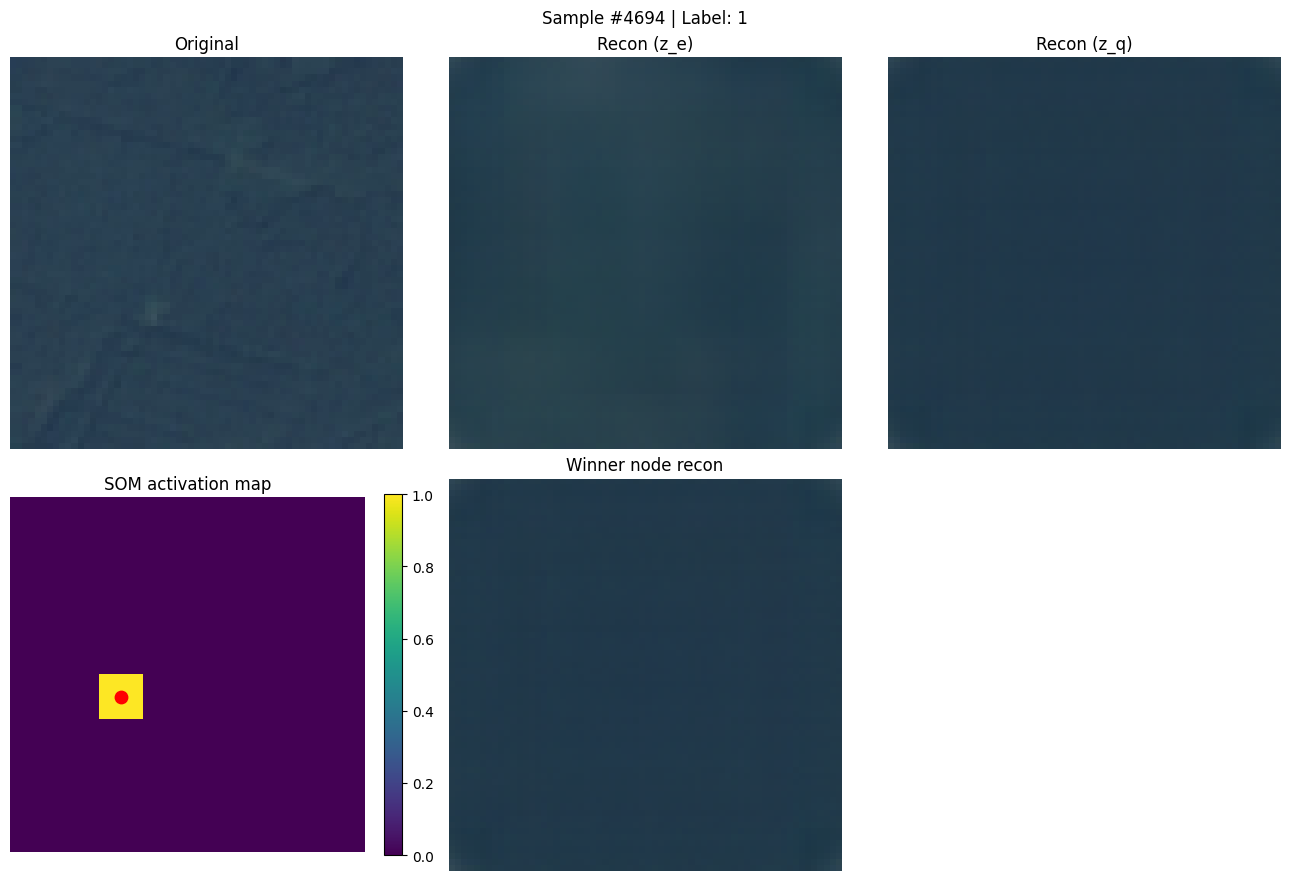

Epoch 30/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 30:
Train: 0.087 | Val: 0.08448940550172052 | NMI: 0.2907


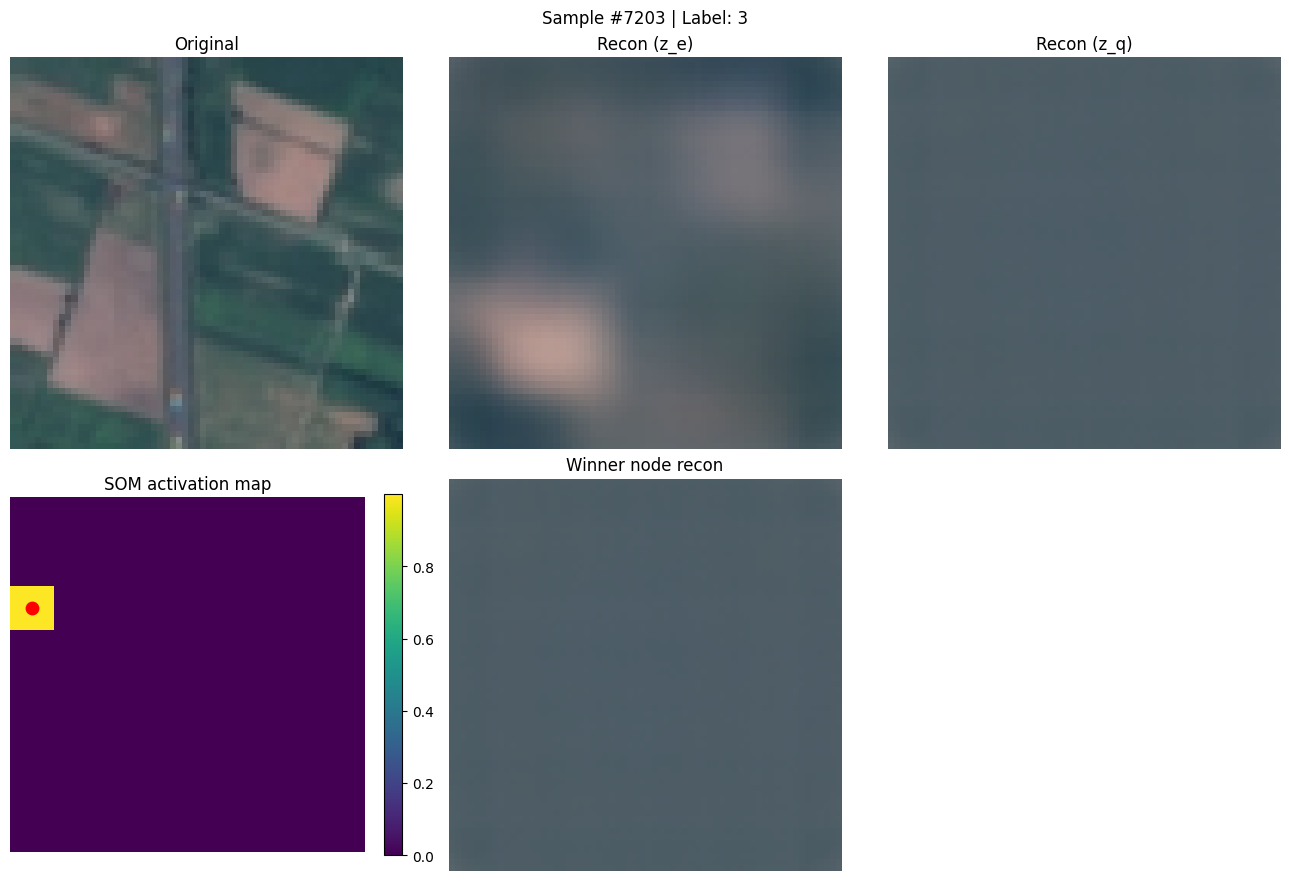

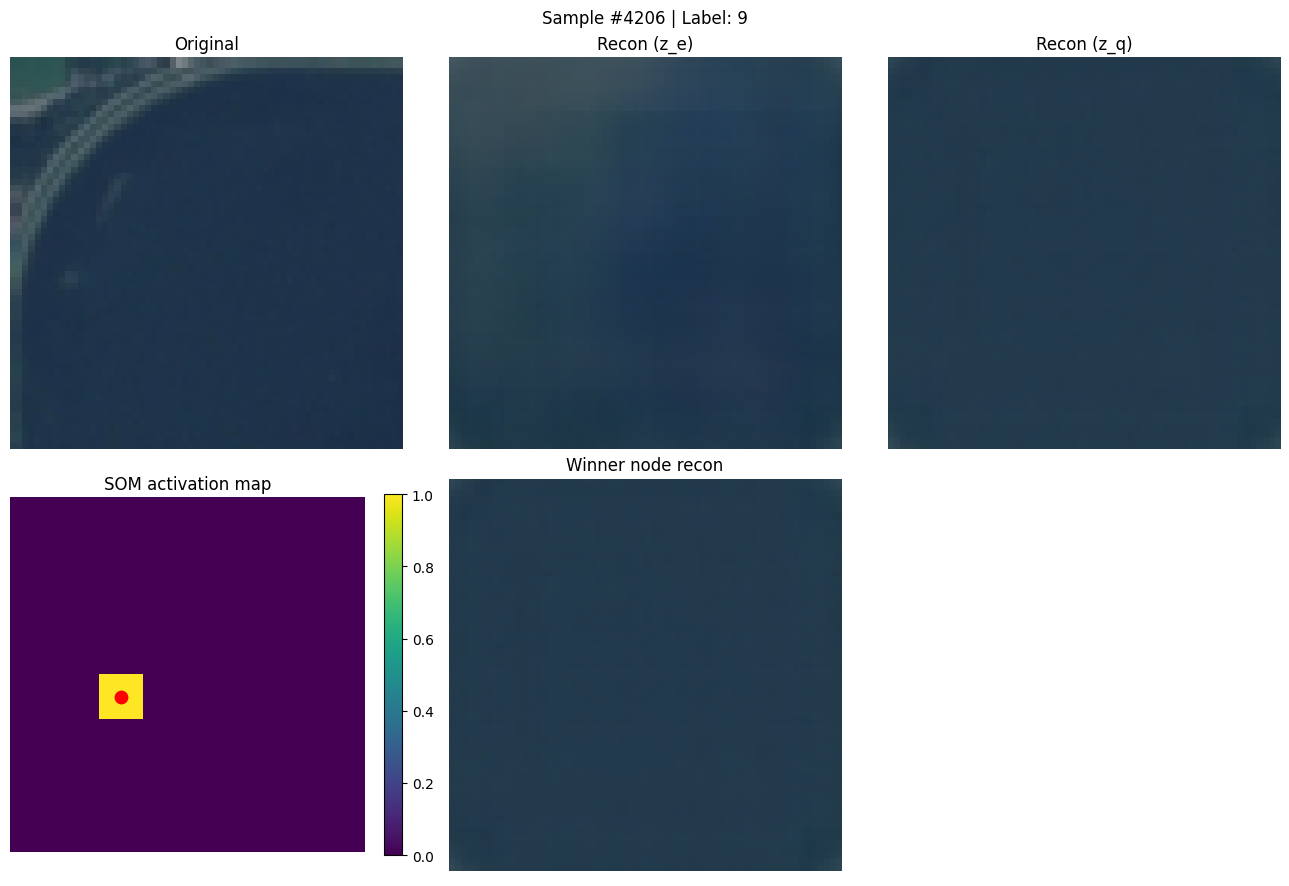

Epoch 31/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 31:
Train: 0.086 | Val: 0.08948842626671459 | NMI: 0.2927


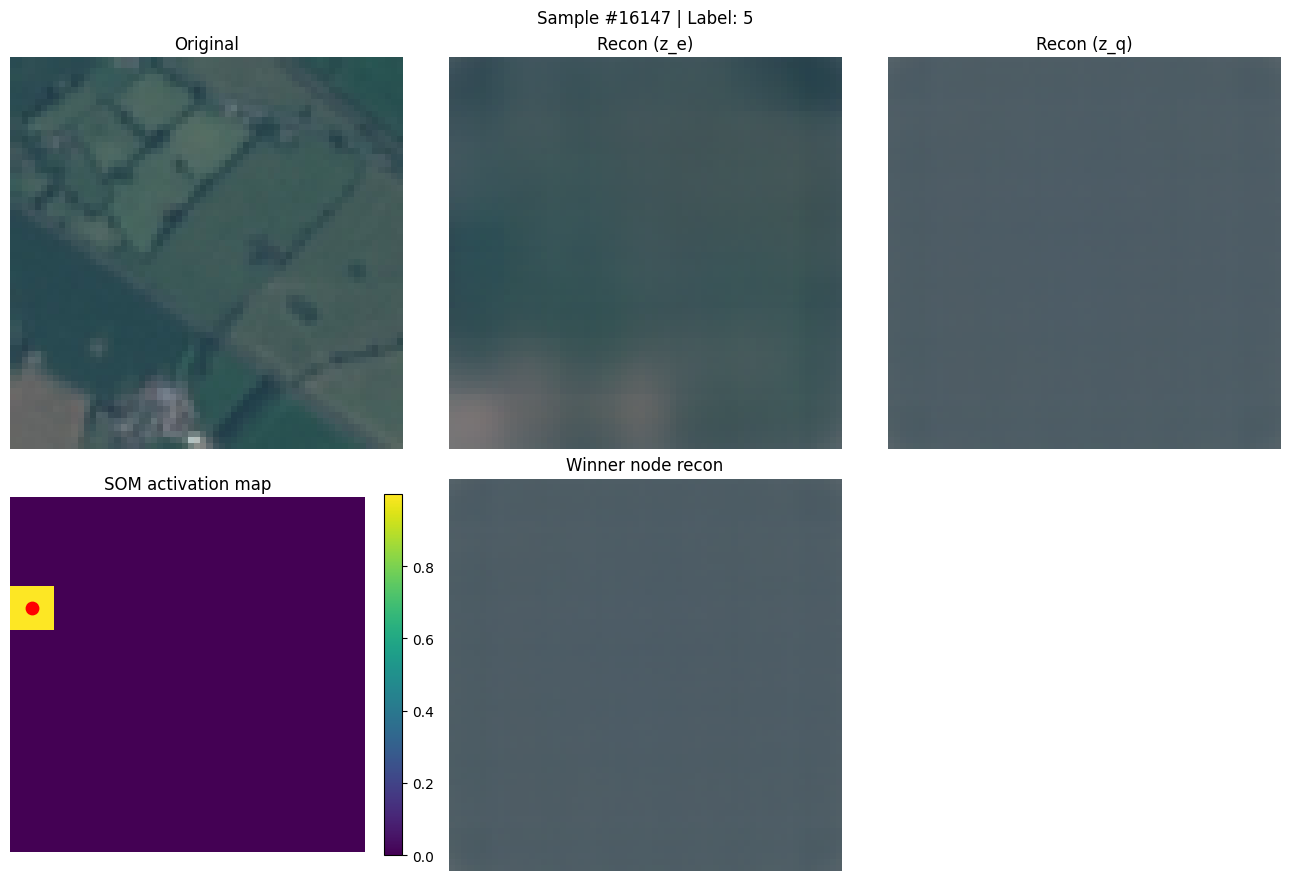

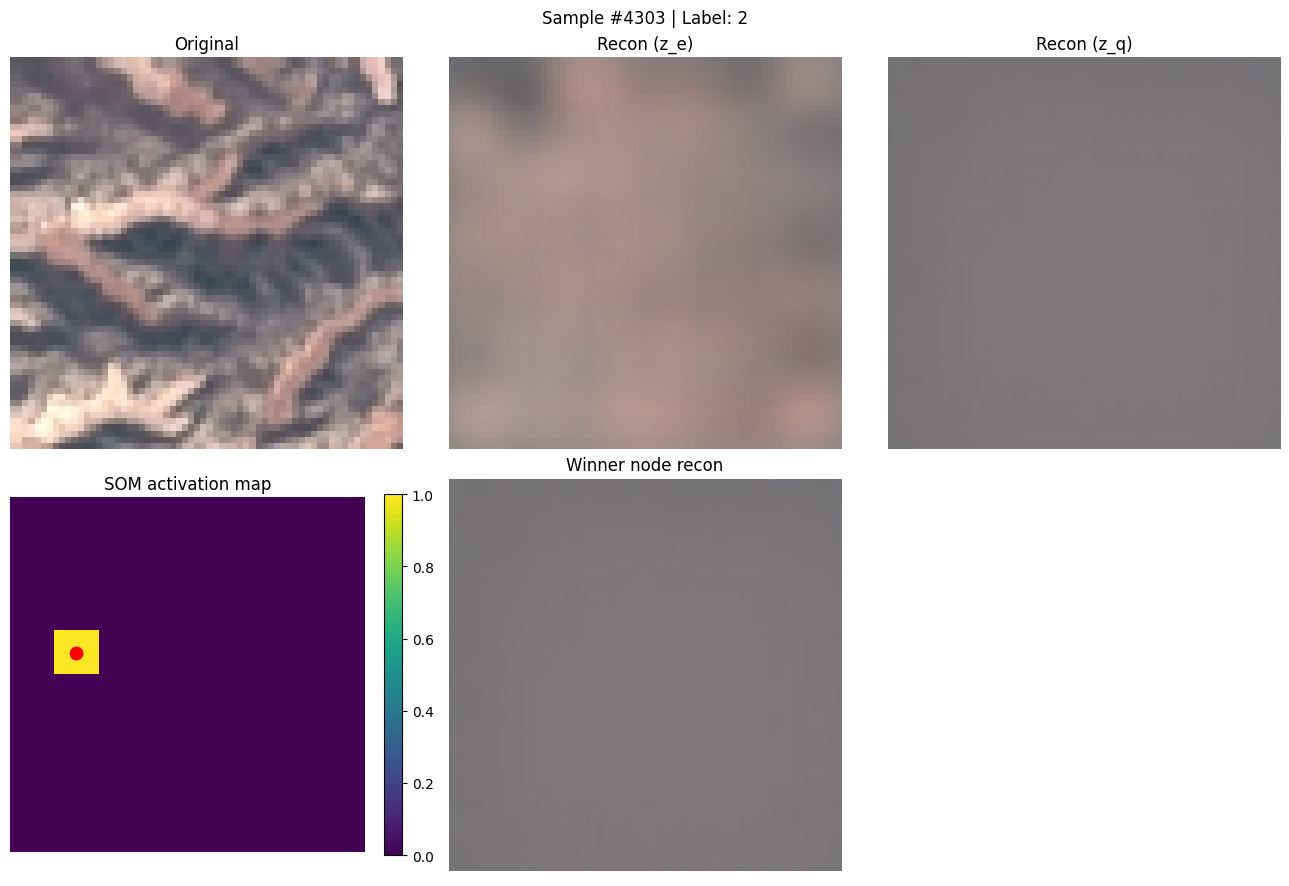

Epoch 32/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 32:
Train: 0.086 | Val: 0.08441407476053682 | NMI: 0.2855


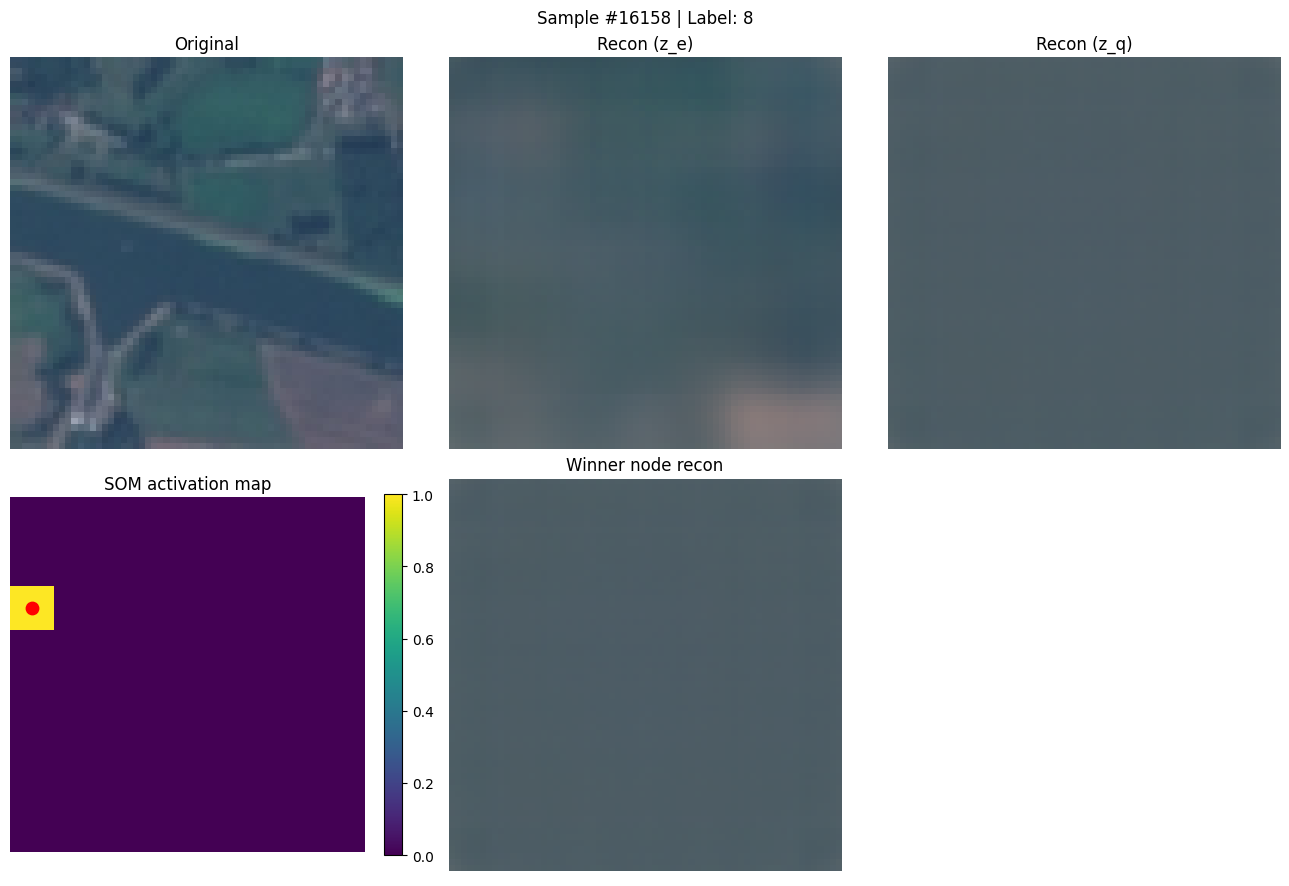

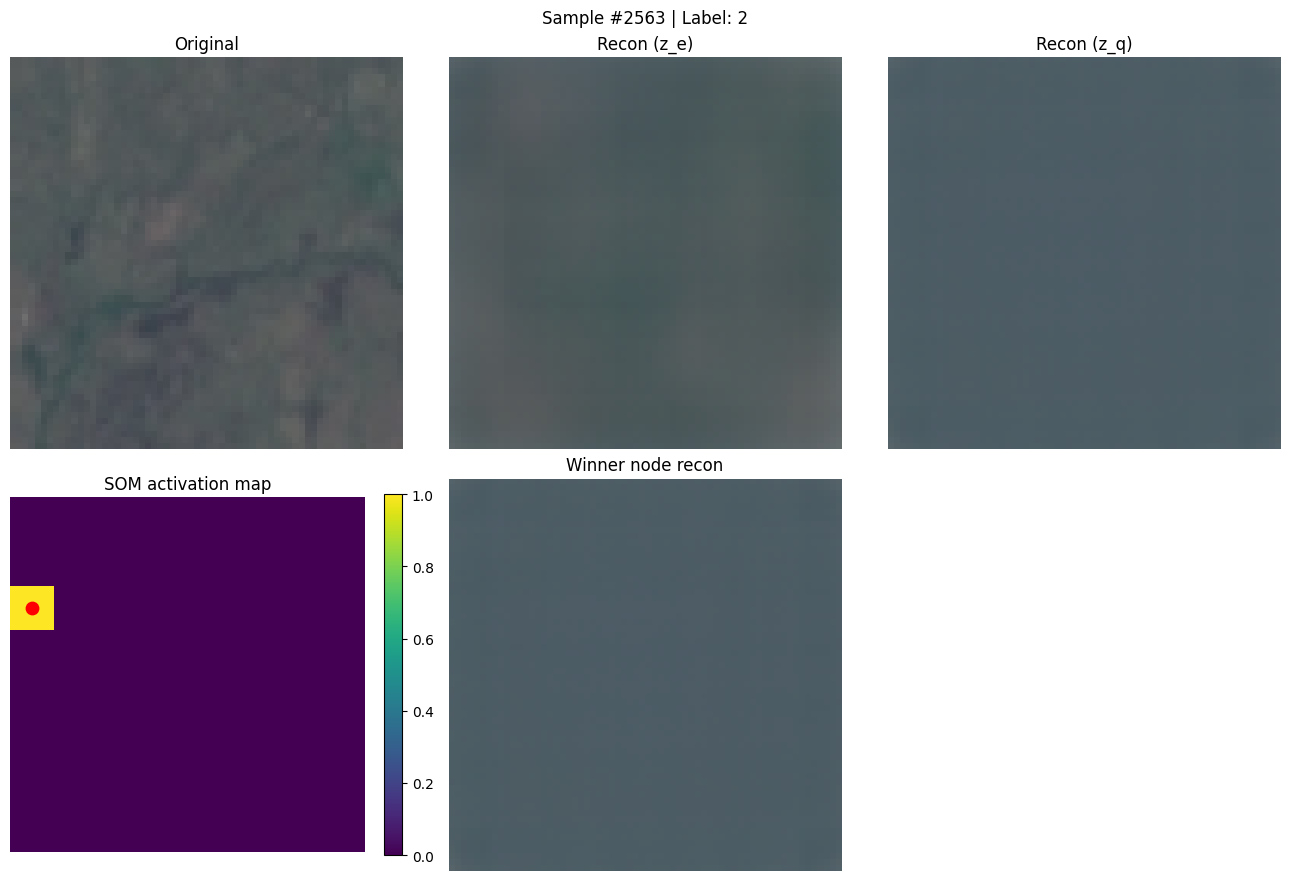

Epoch 33/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 33:
Train: 0.085 | Val: 0.08451732109452403 | NMI: 0.2941


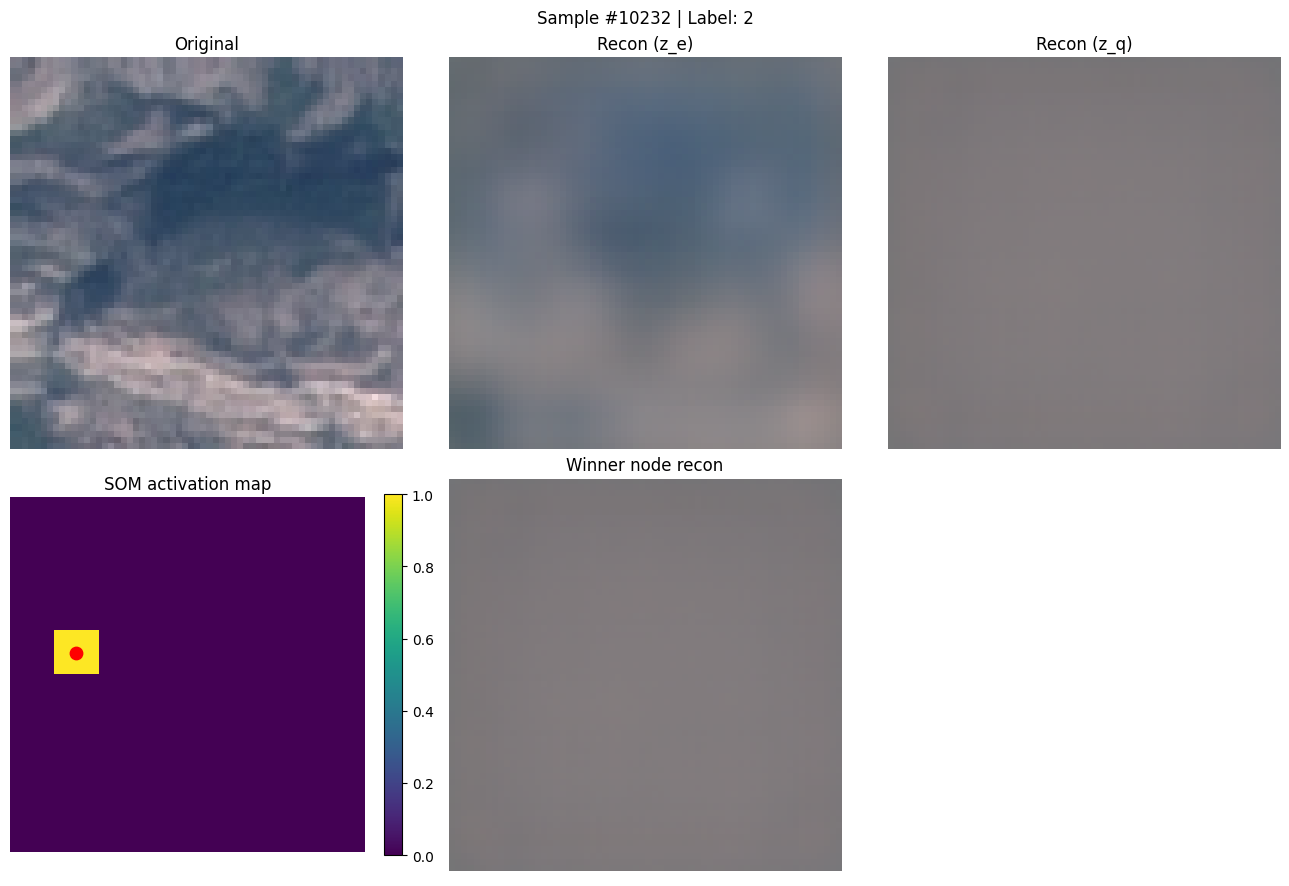

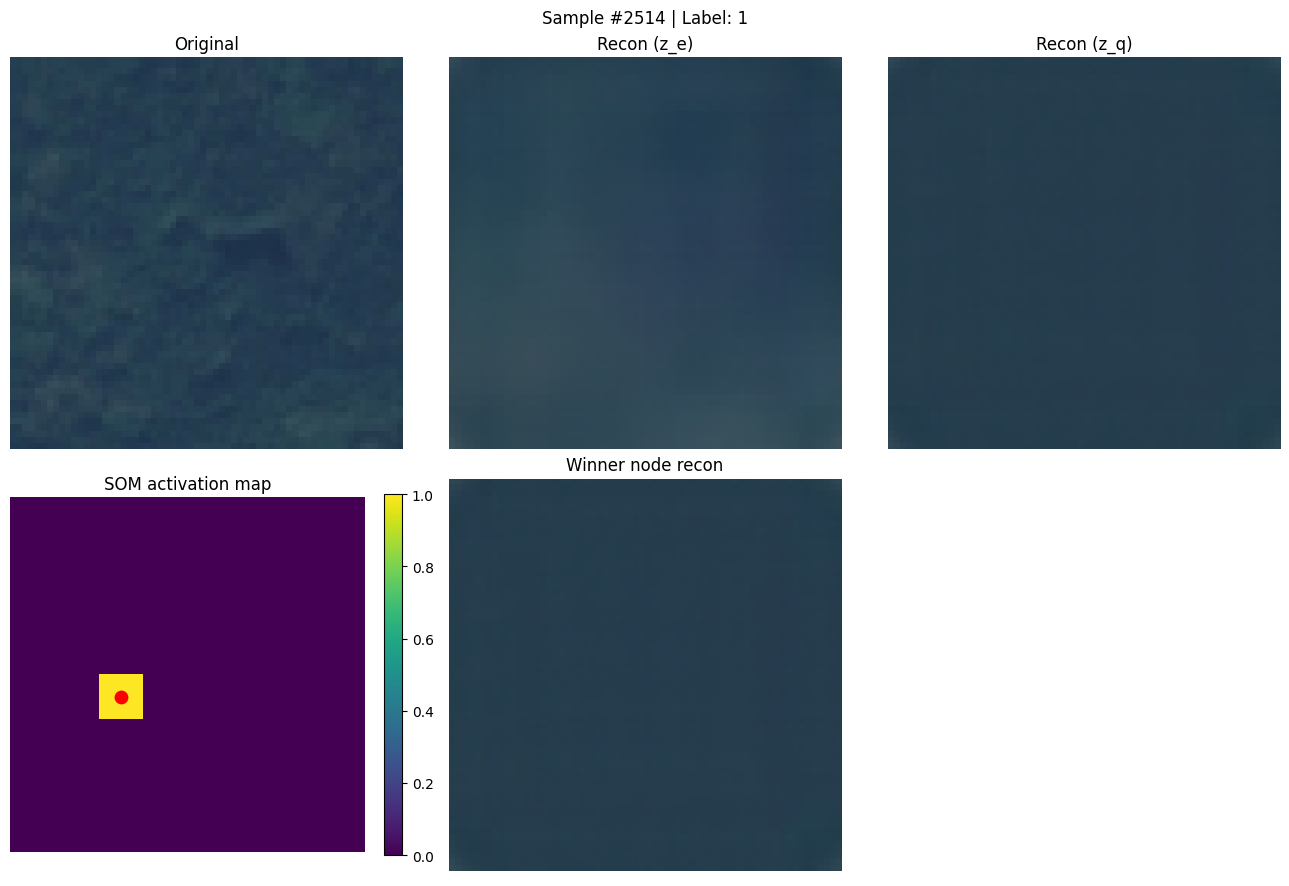

Epoch 34/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 34:
Train: 0.085 | Val: 0.08609365793161614 | NMI: 0.2890


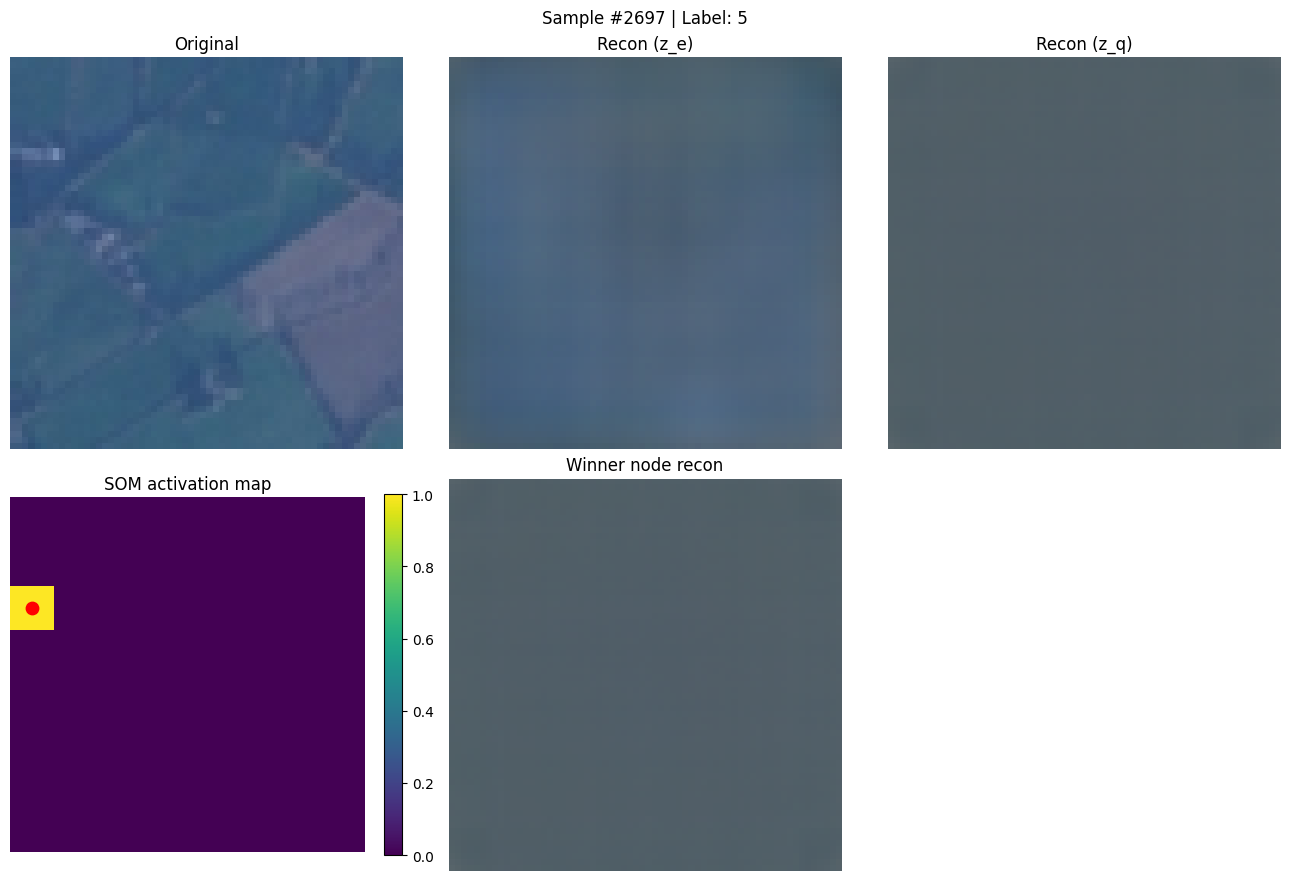

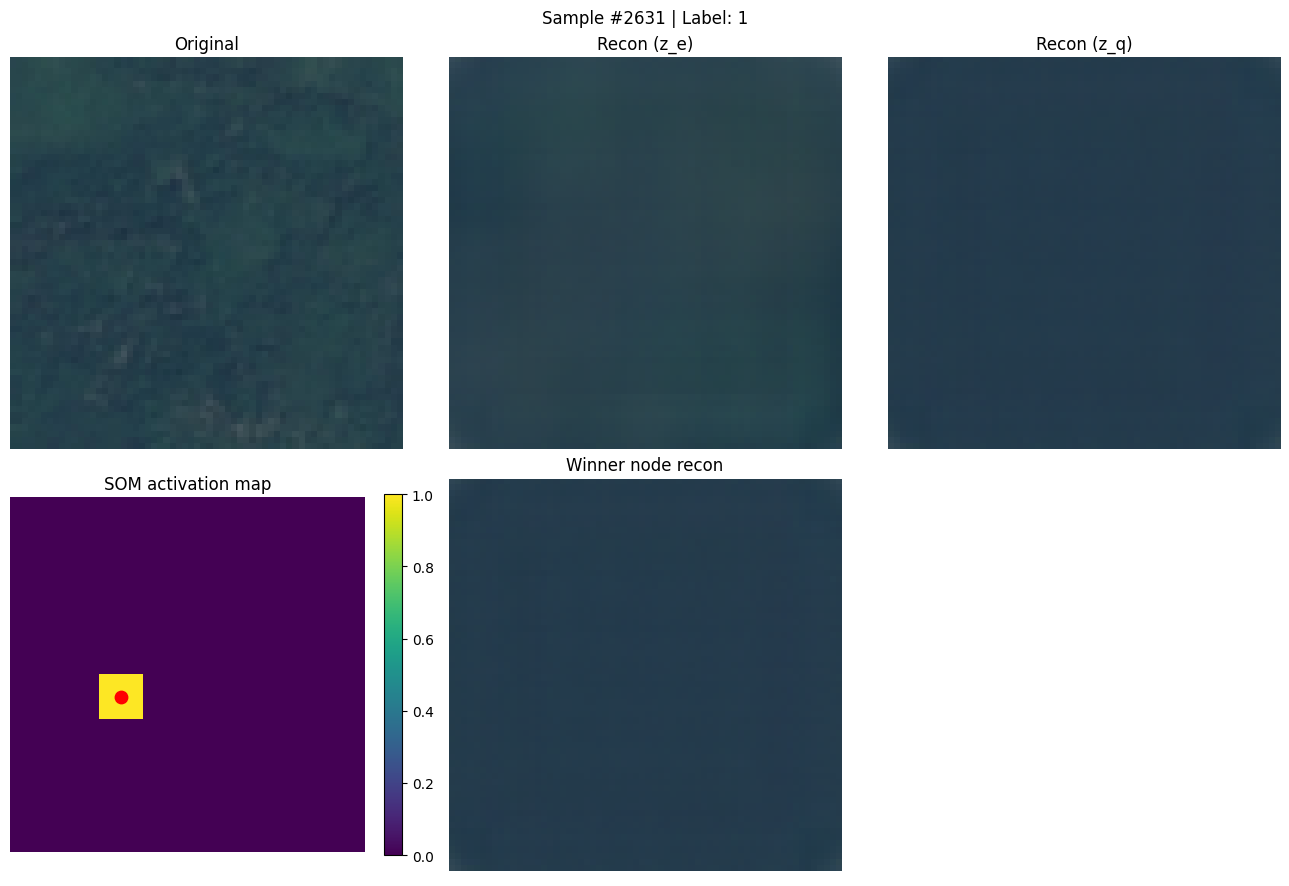

Epoch 35/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 35:
Train: 0.085 | Val: 0.08265603931490766 | NMI: 0.2735


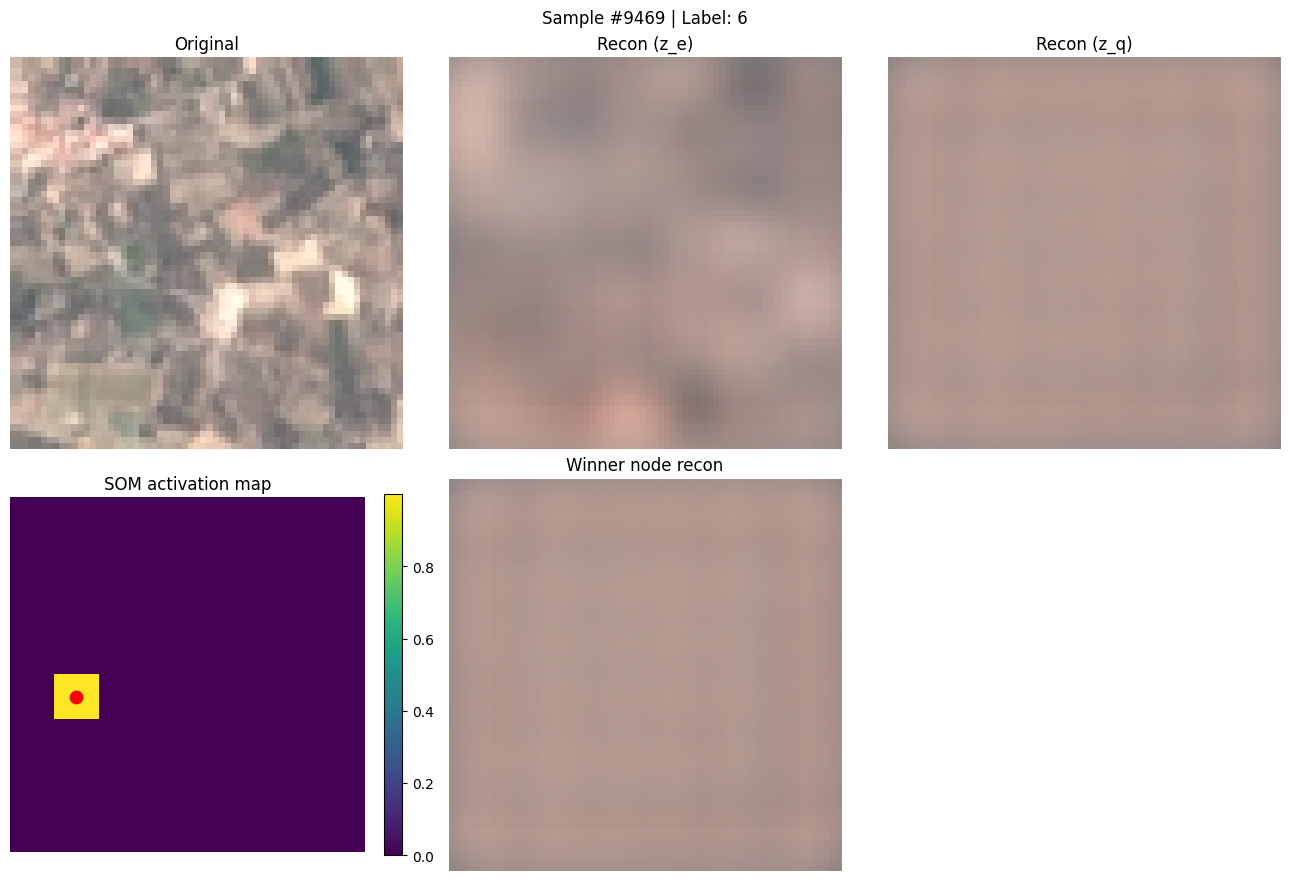

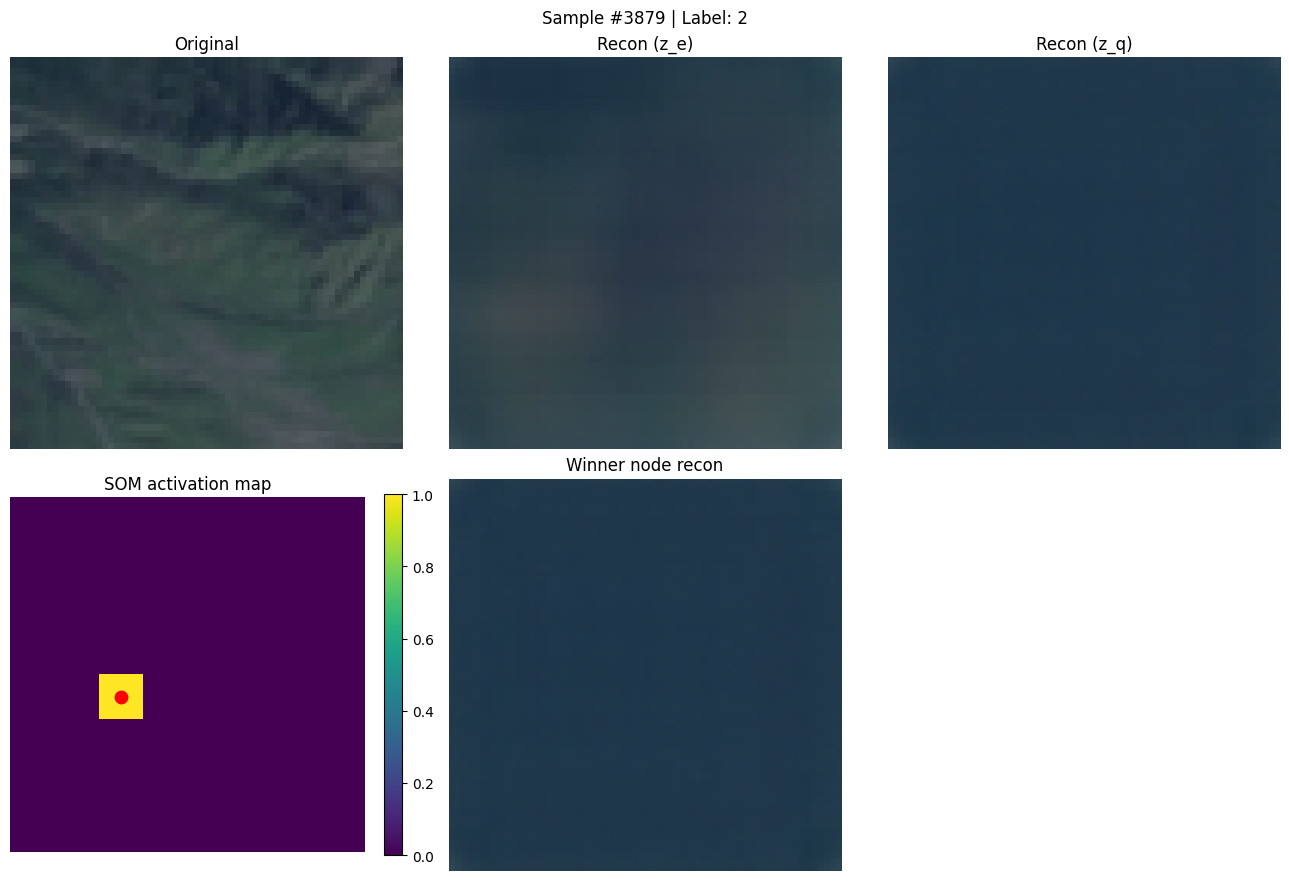

Epoch 36/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 36:
Train: 0.086 | Val: 0.09205597604429999 | NMI: 0.2861


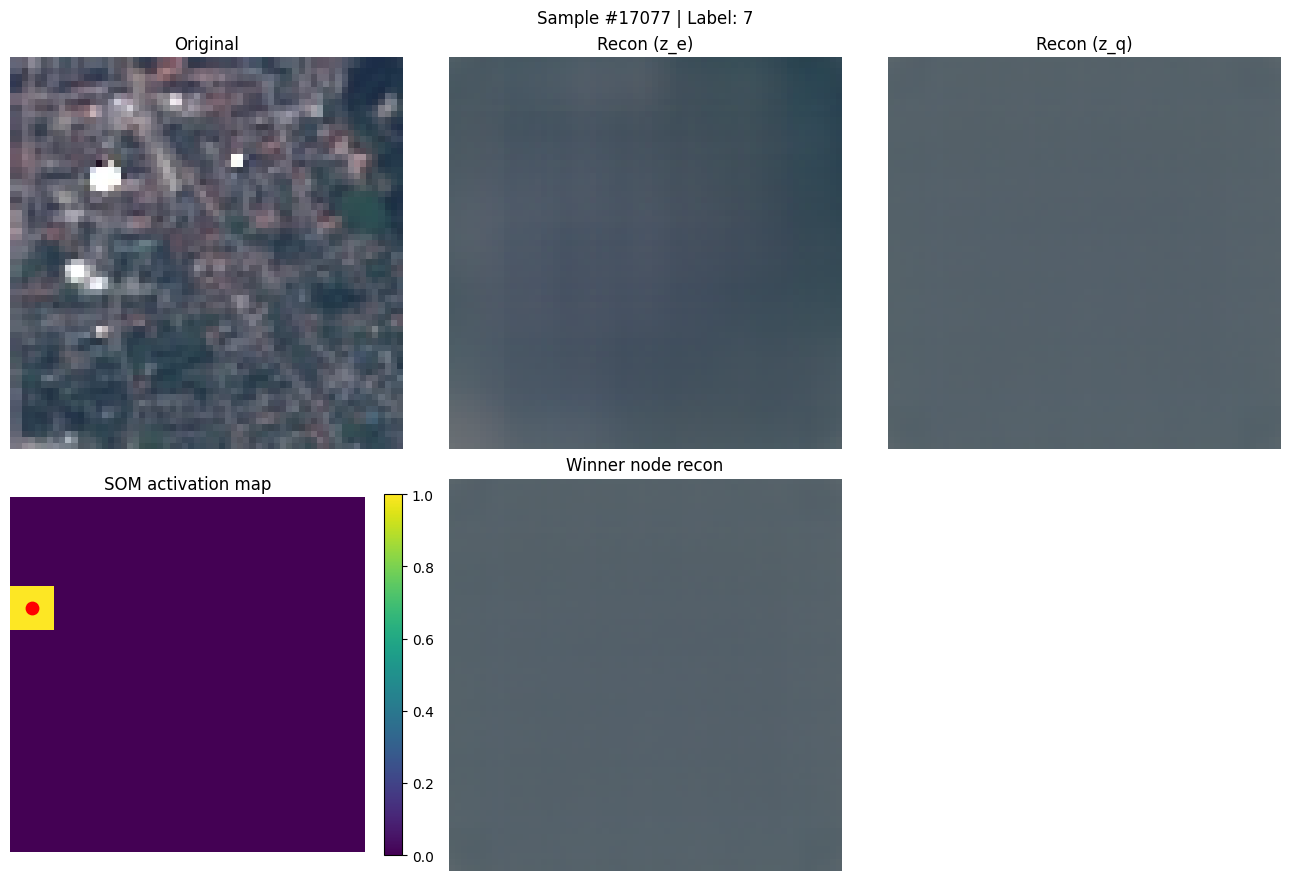

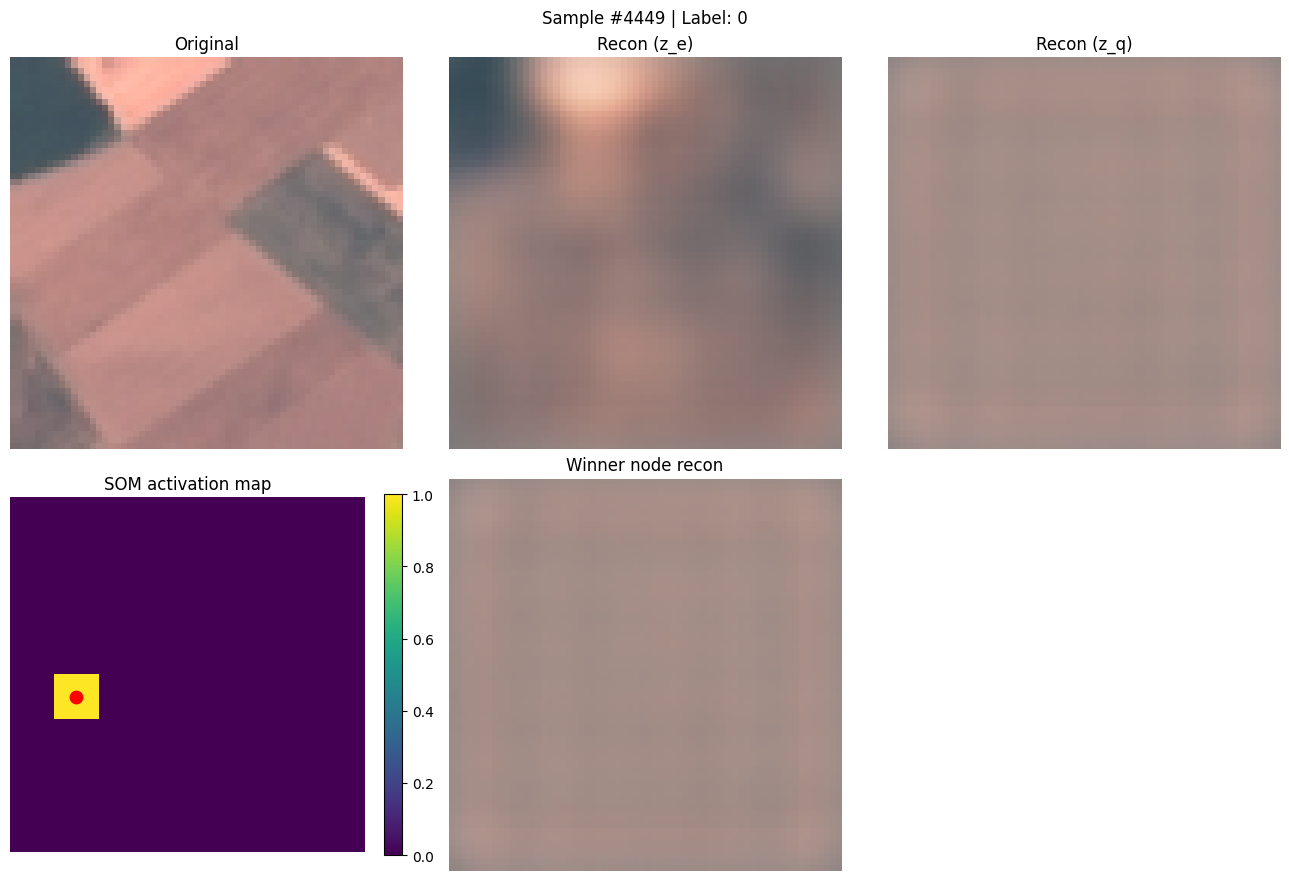

Epoch 37/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 37:
Train: 0.084 | Val: 0.08254833207574001 | NMI: 0.2888


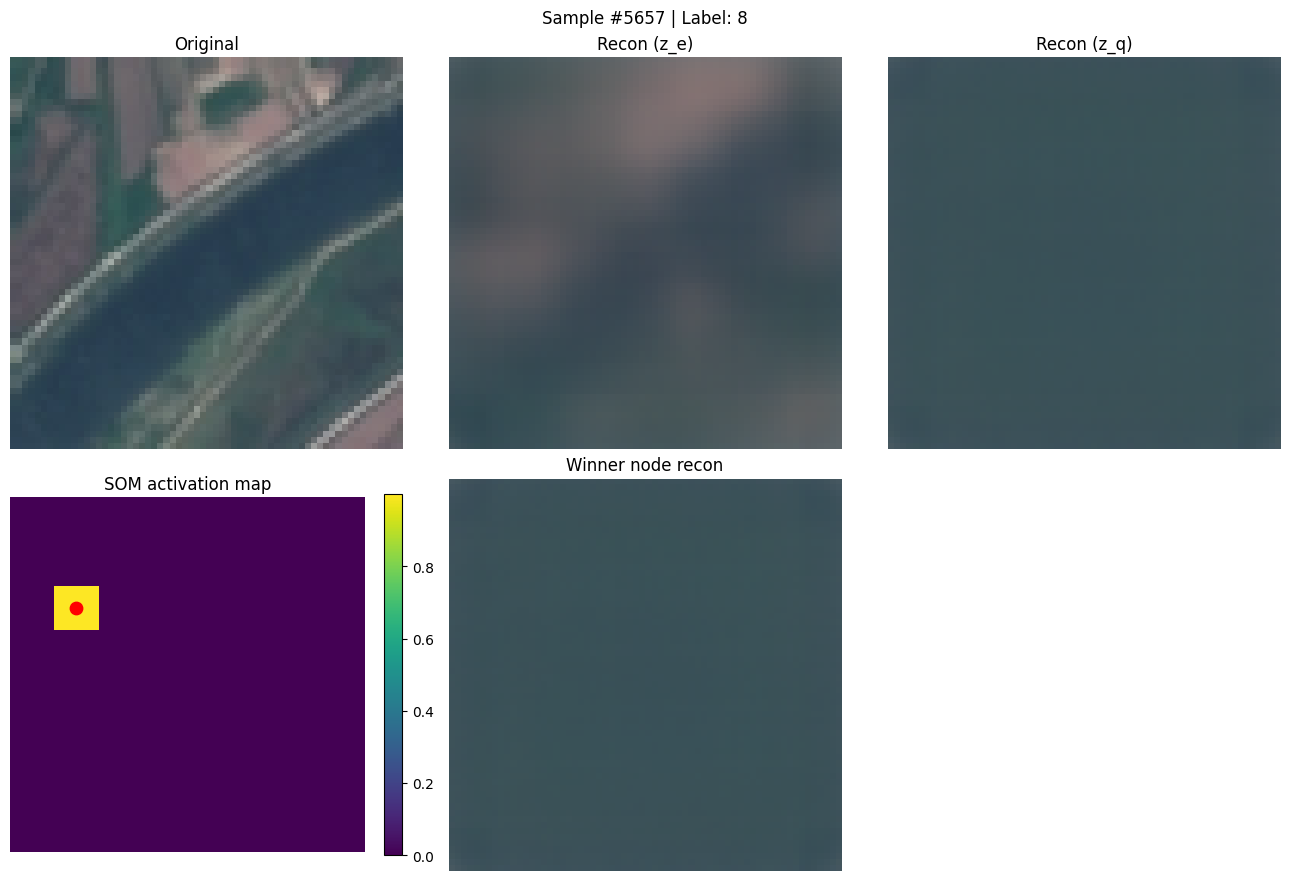

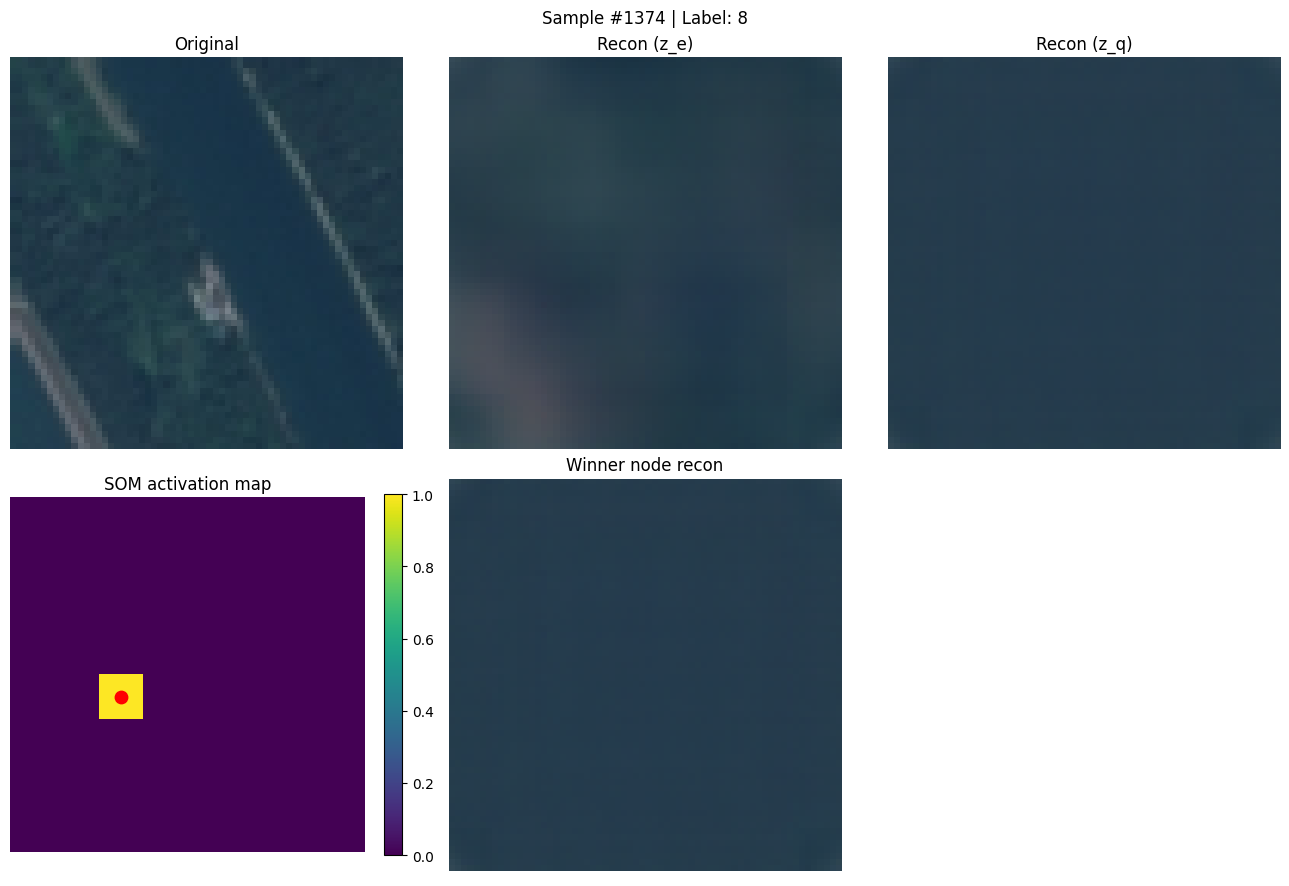

Epoch 38/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 38:
Train: 0.082 | Val: 0.08084067338427832 | NMI: 0.2874


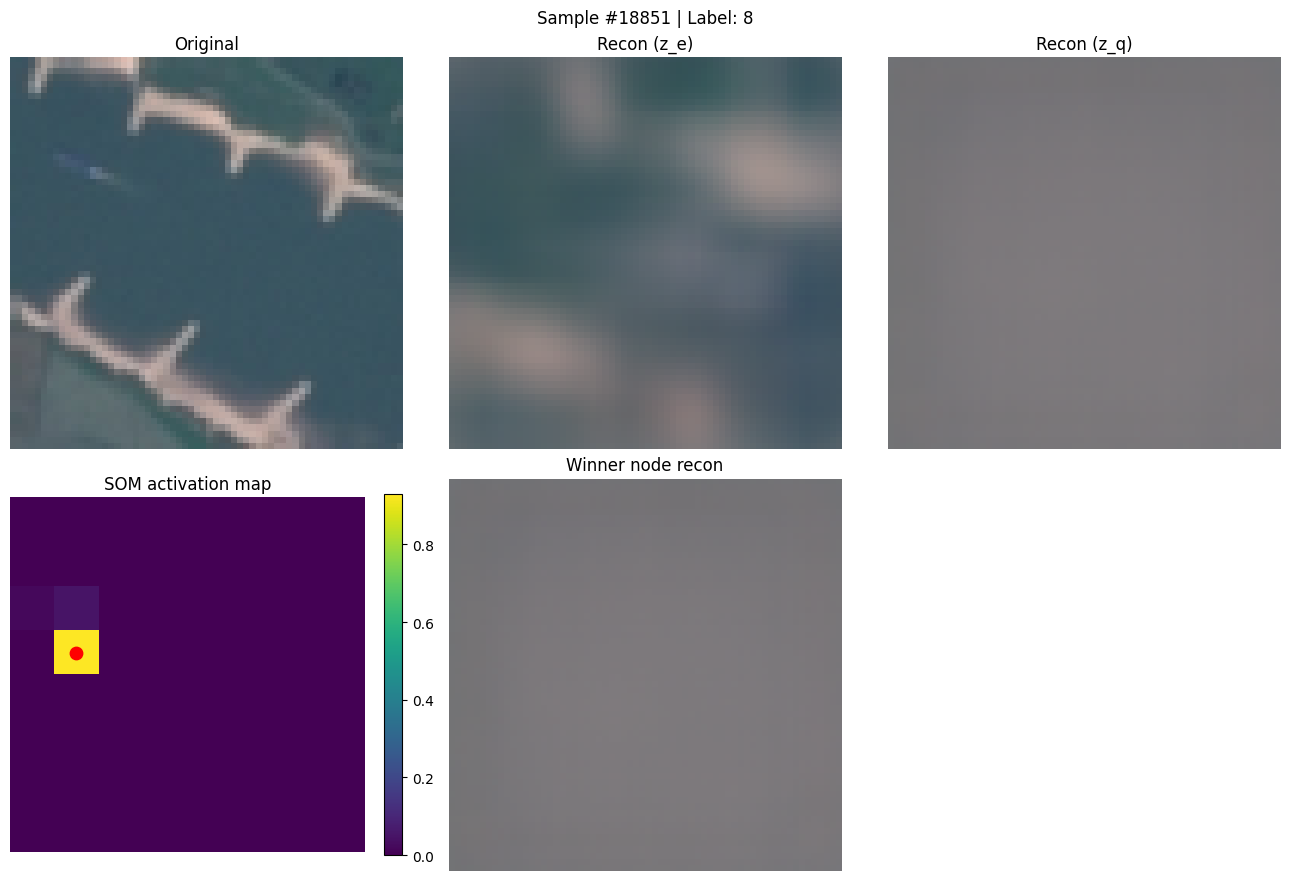

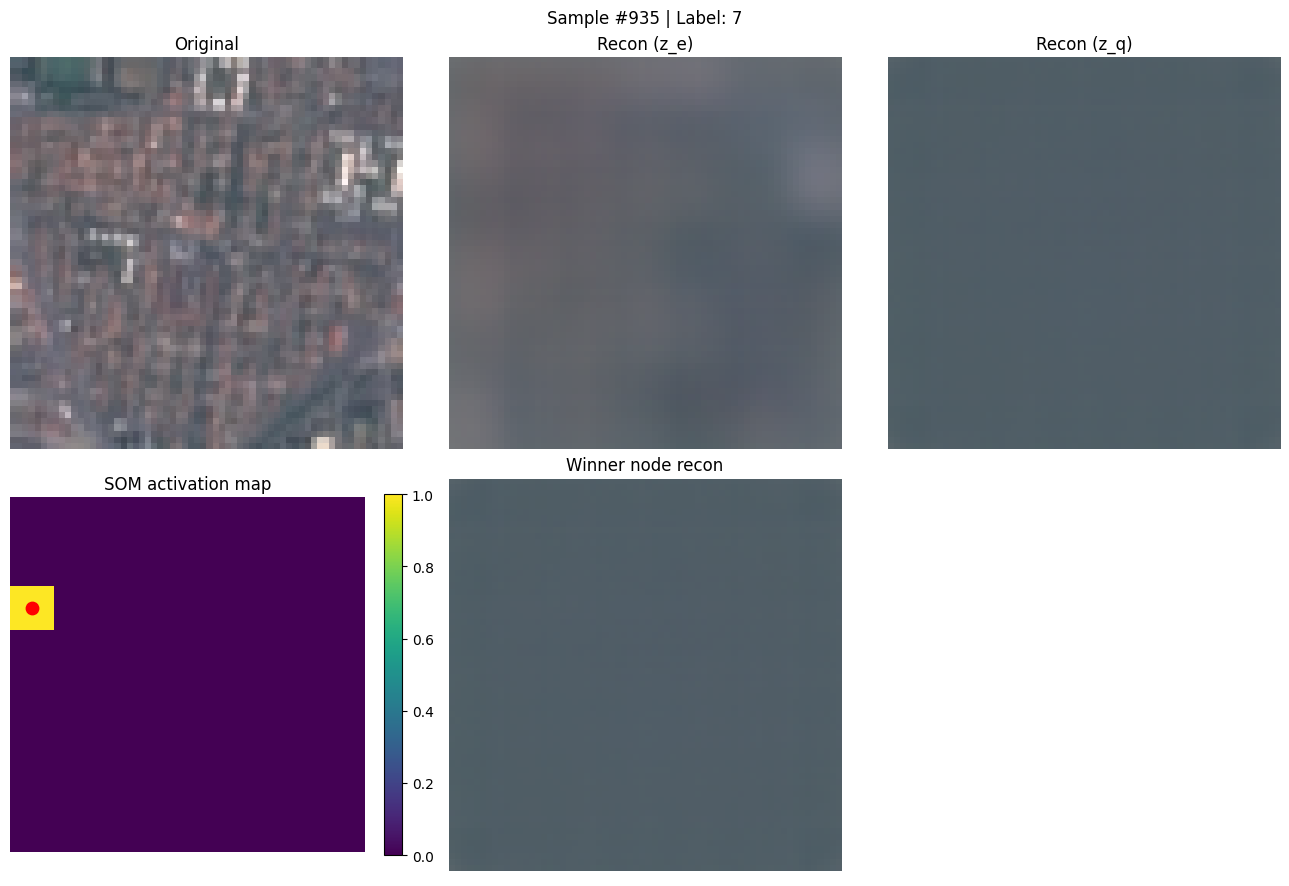

Epoch 39/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 39:
Train: 0.085 | Val: 0.08298372598581535 | NMI: 0.3039


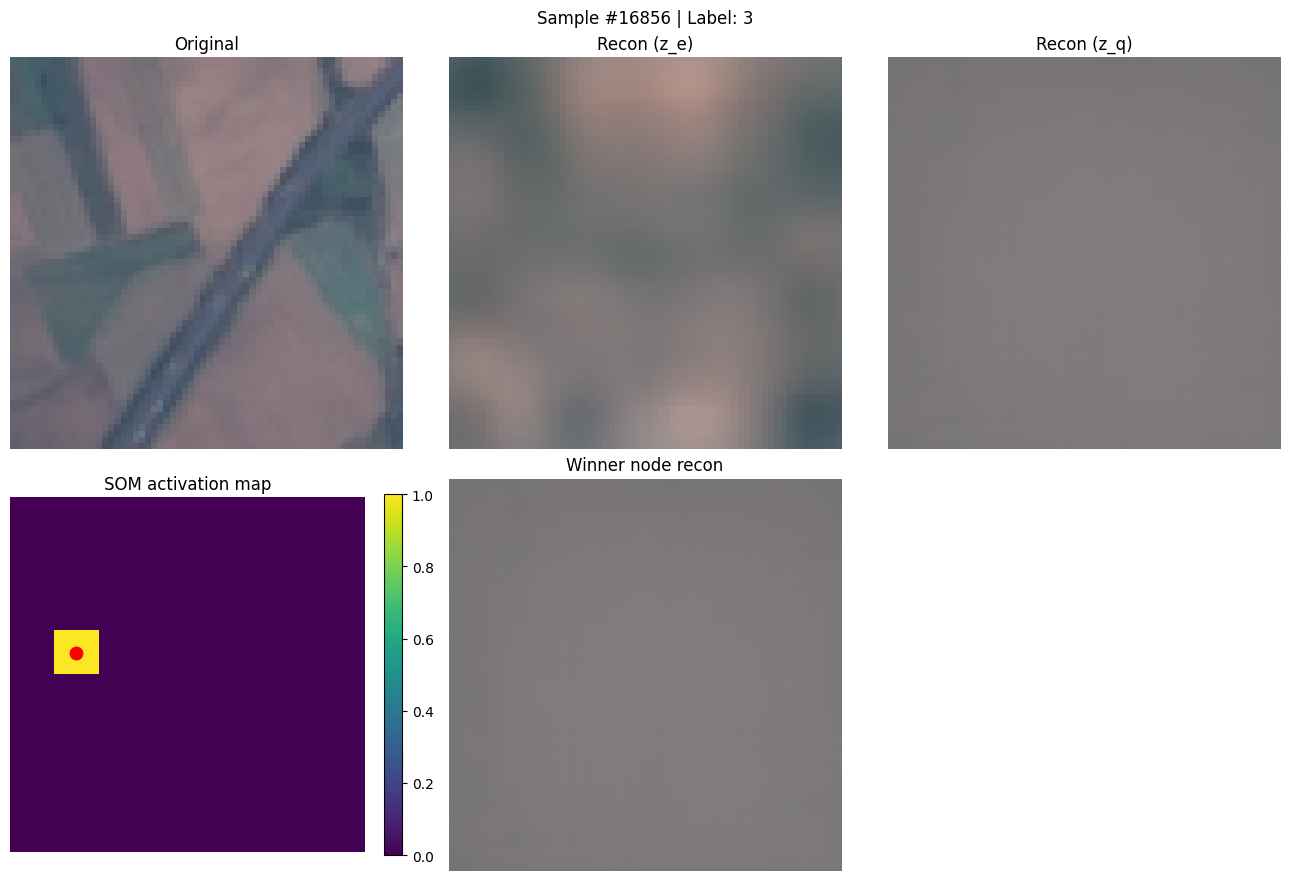

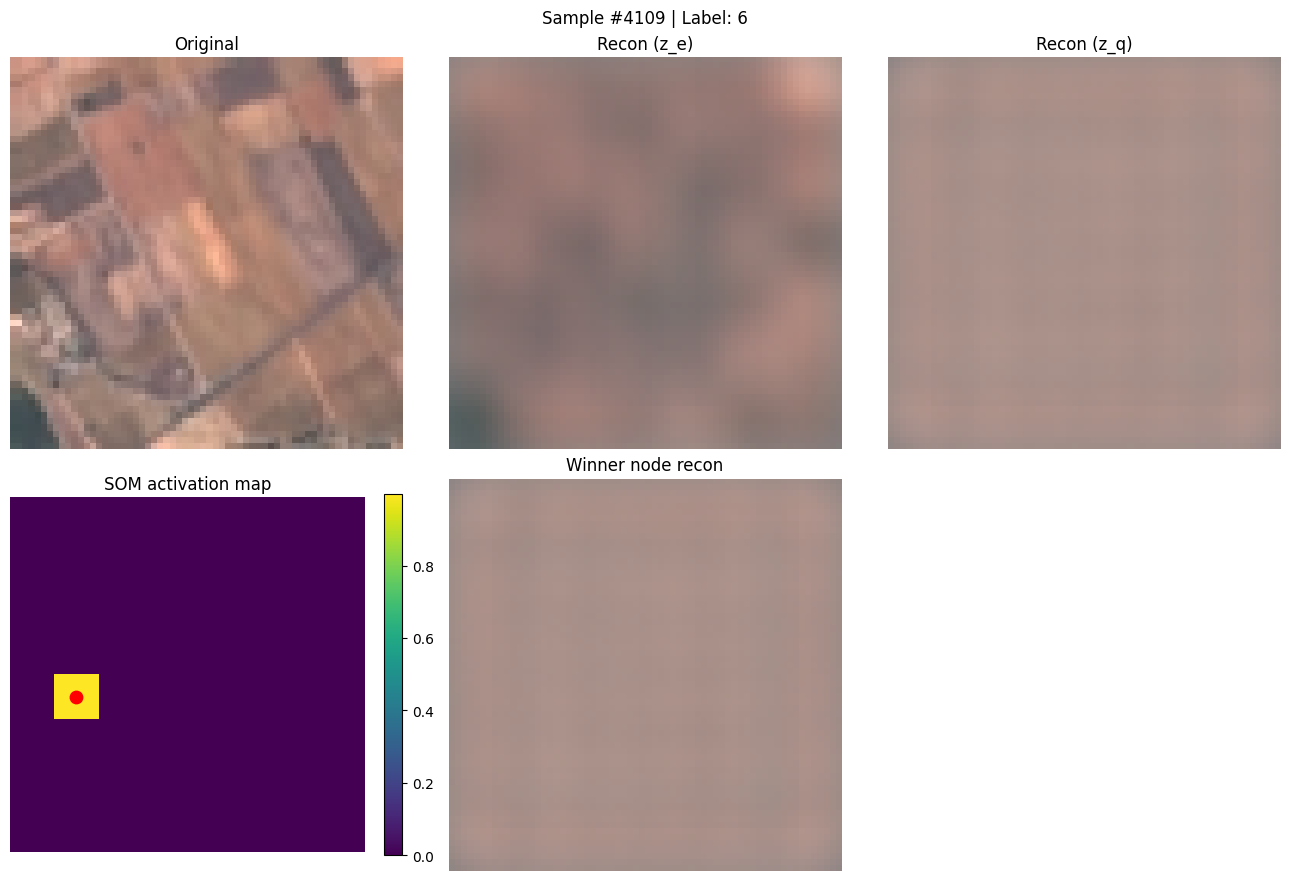

Epoch 40/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 40:
Train: 0.083 | Val: 0.08498075743054234 | NMI: 0.2954


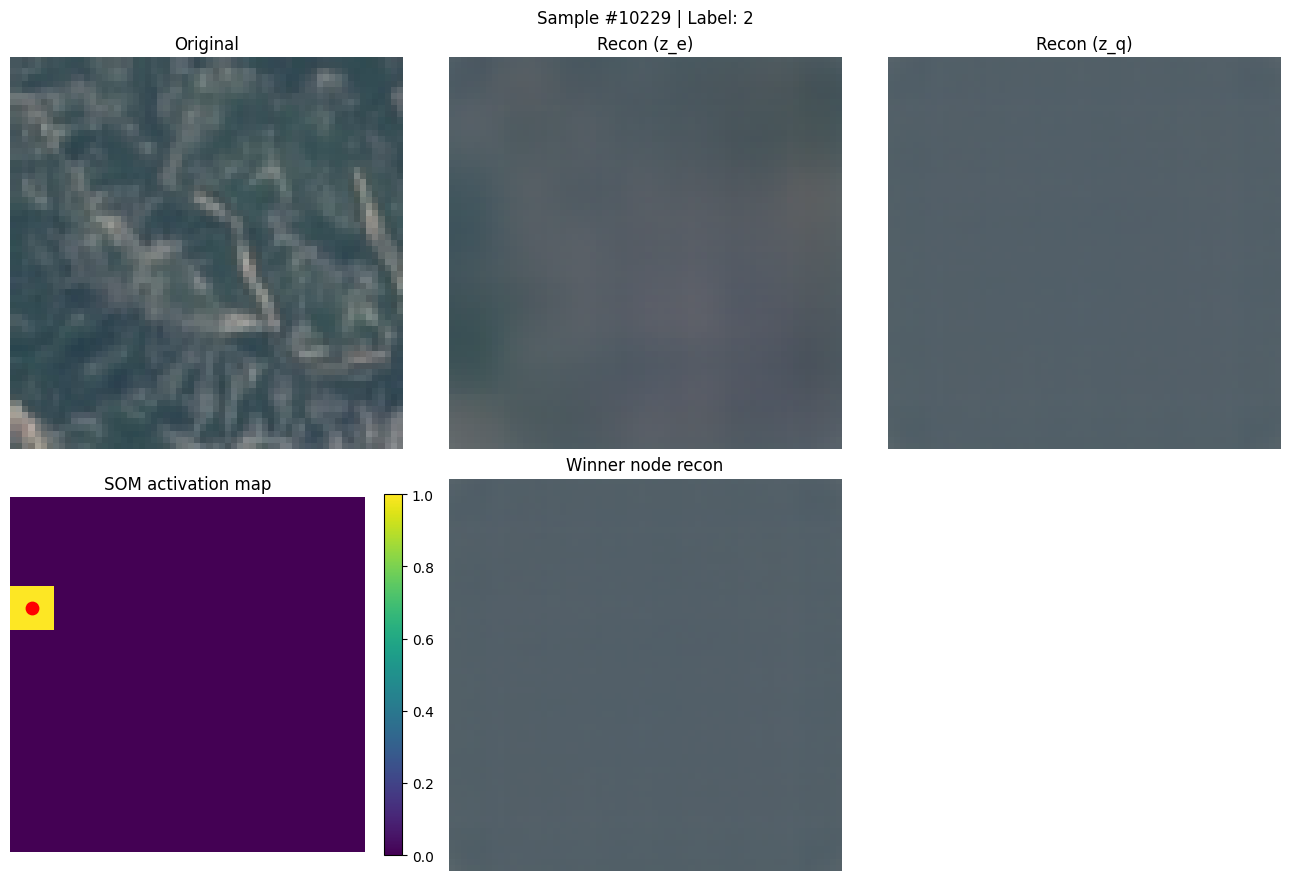

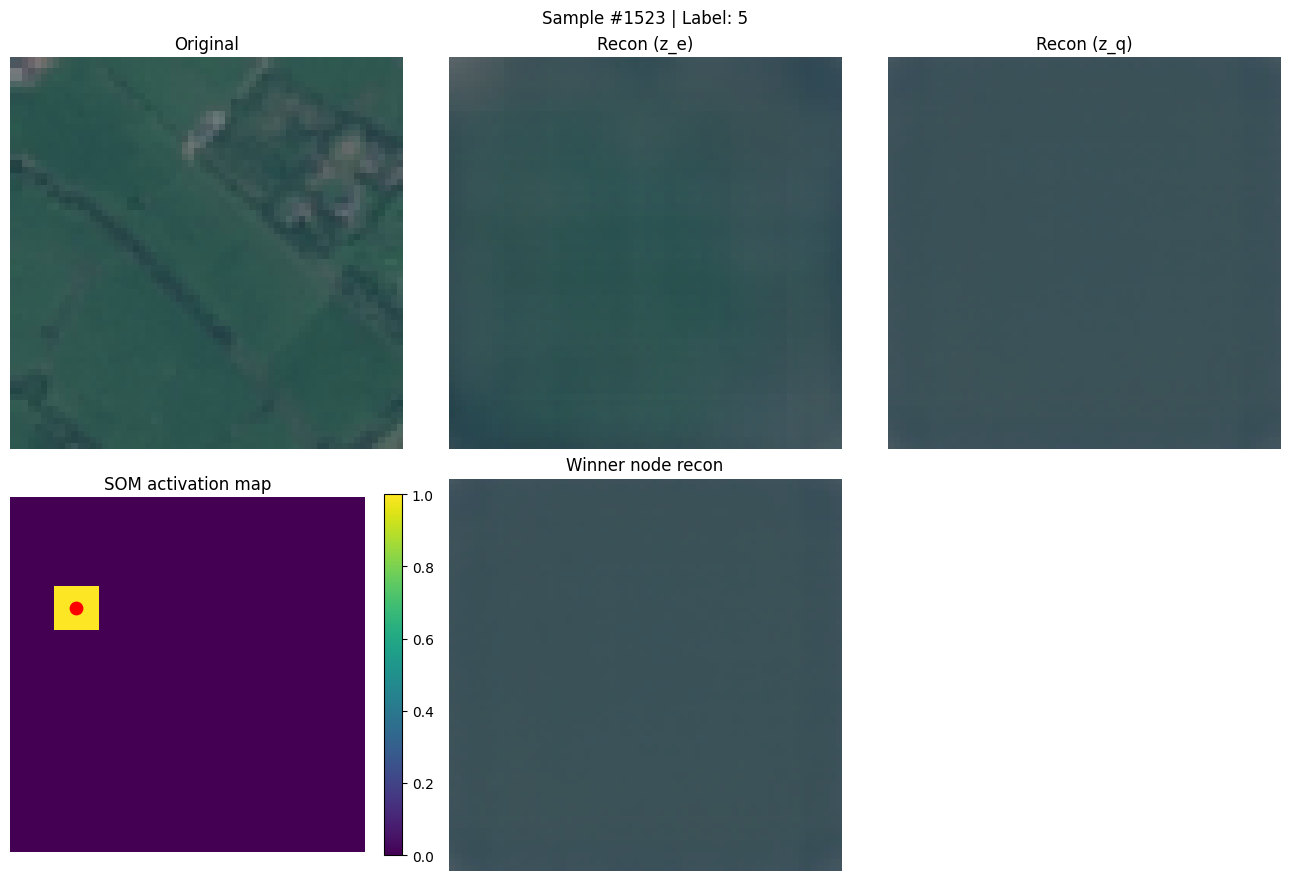

Epoch 41/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 41:
Train: 0.082 | Val: 0.08263461672982504 | NMI: 0.2913


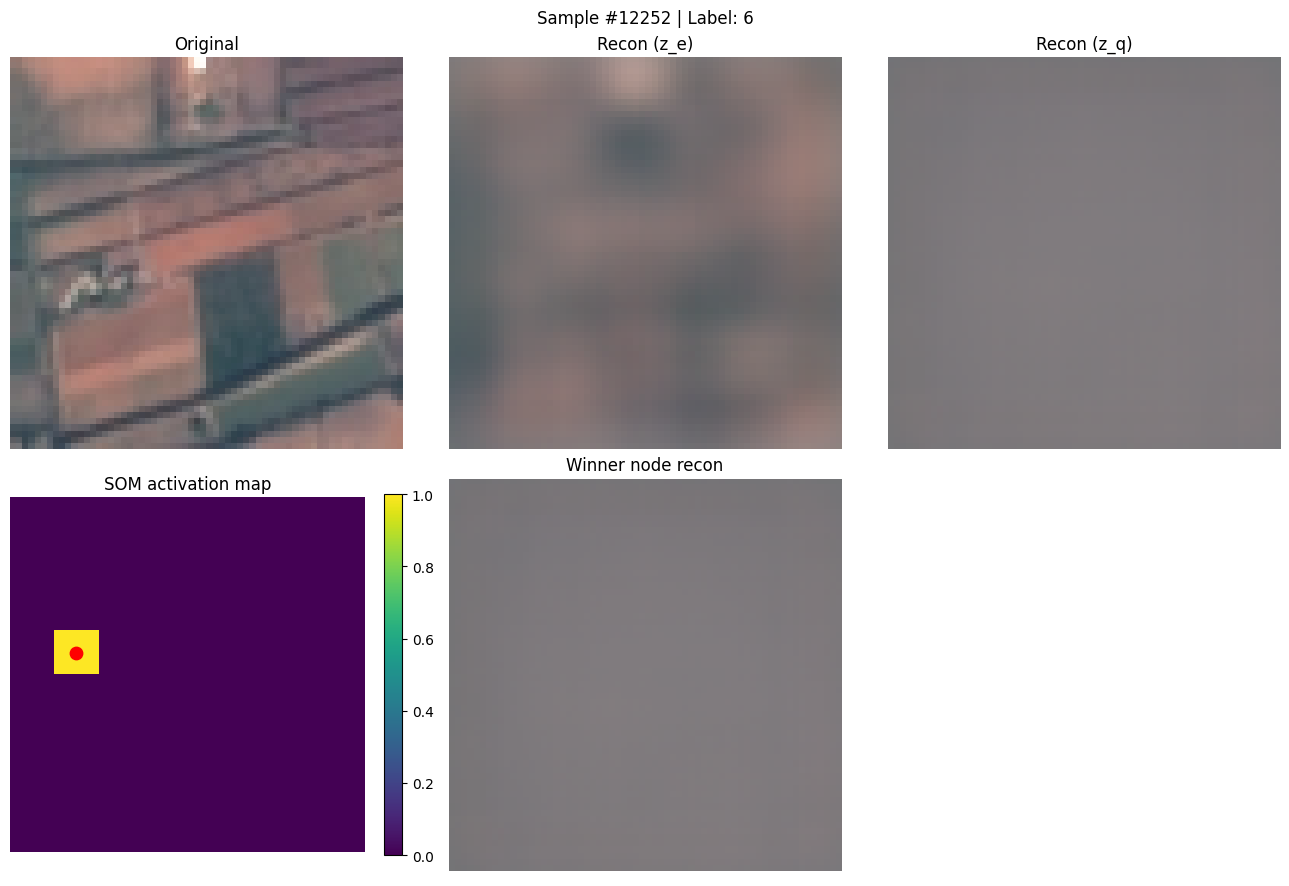

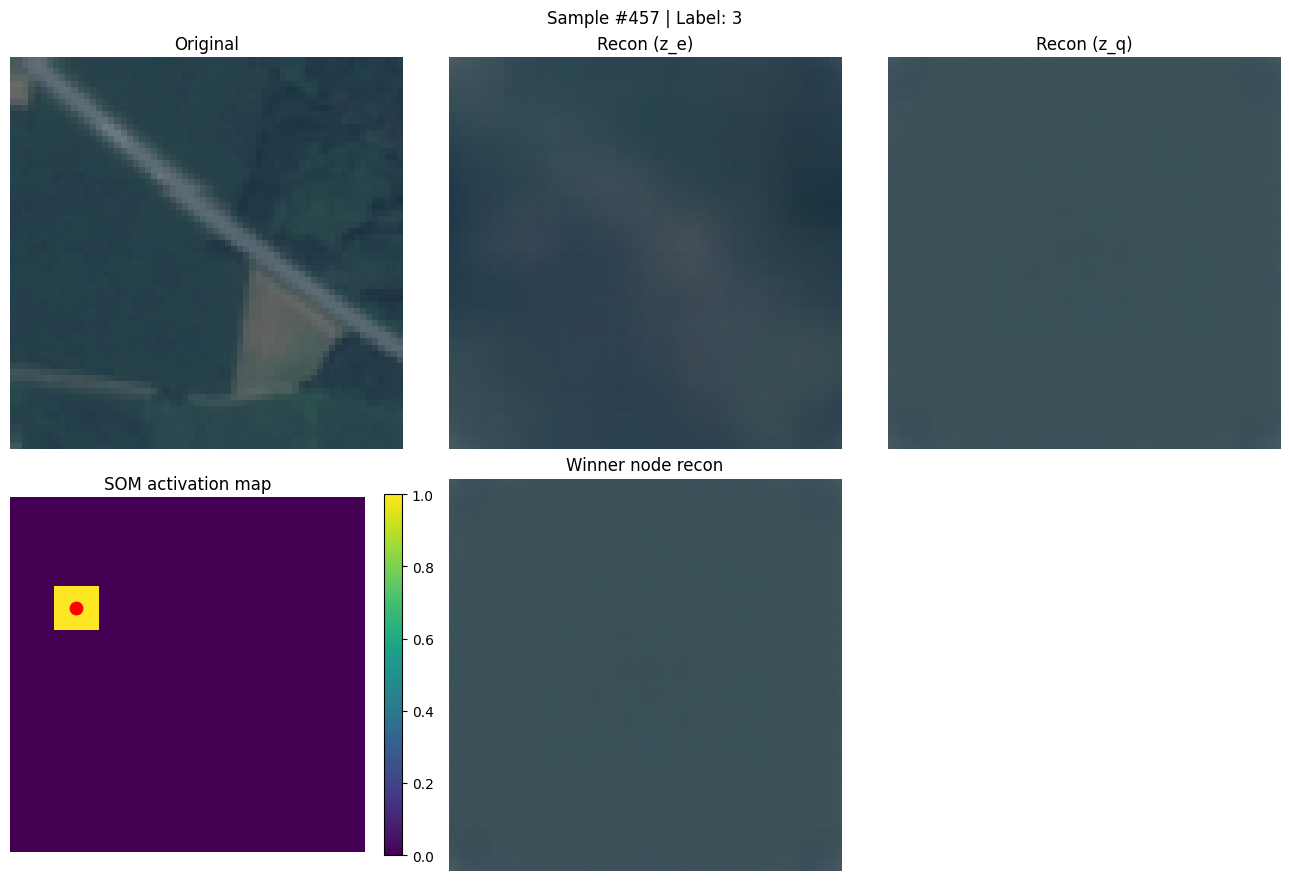

Epoch 42/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 42:
Train: 0.082 | Val: 0.07910111849737722 | NMI: 0.2934


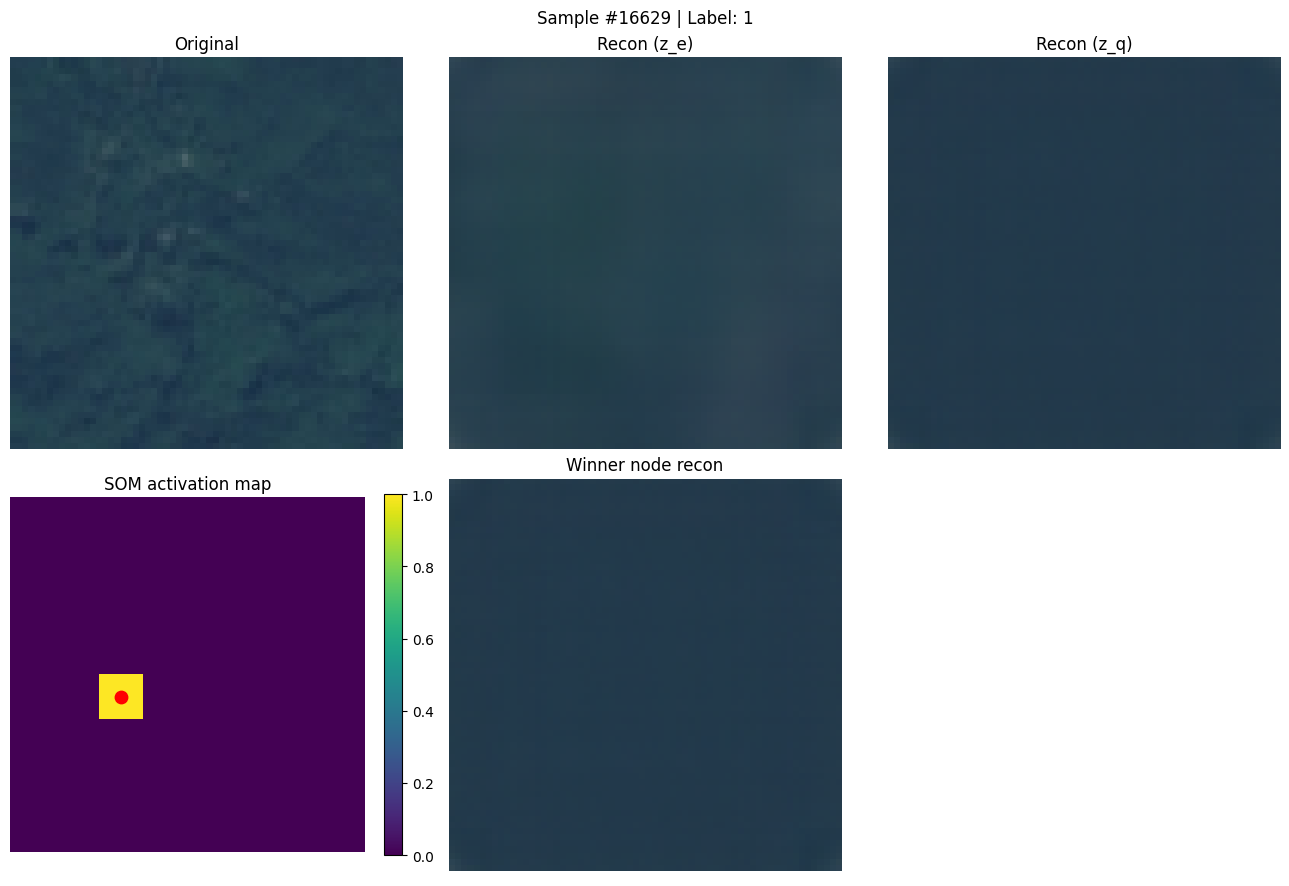

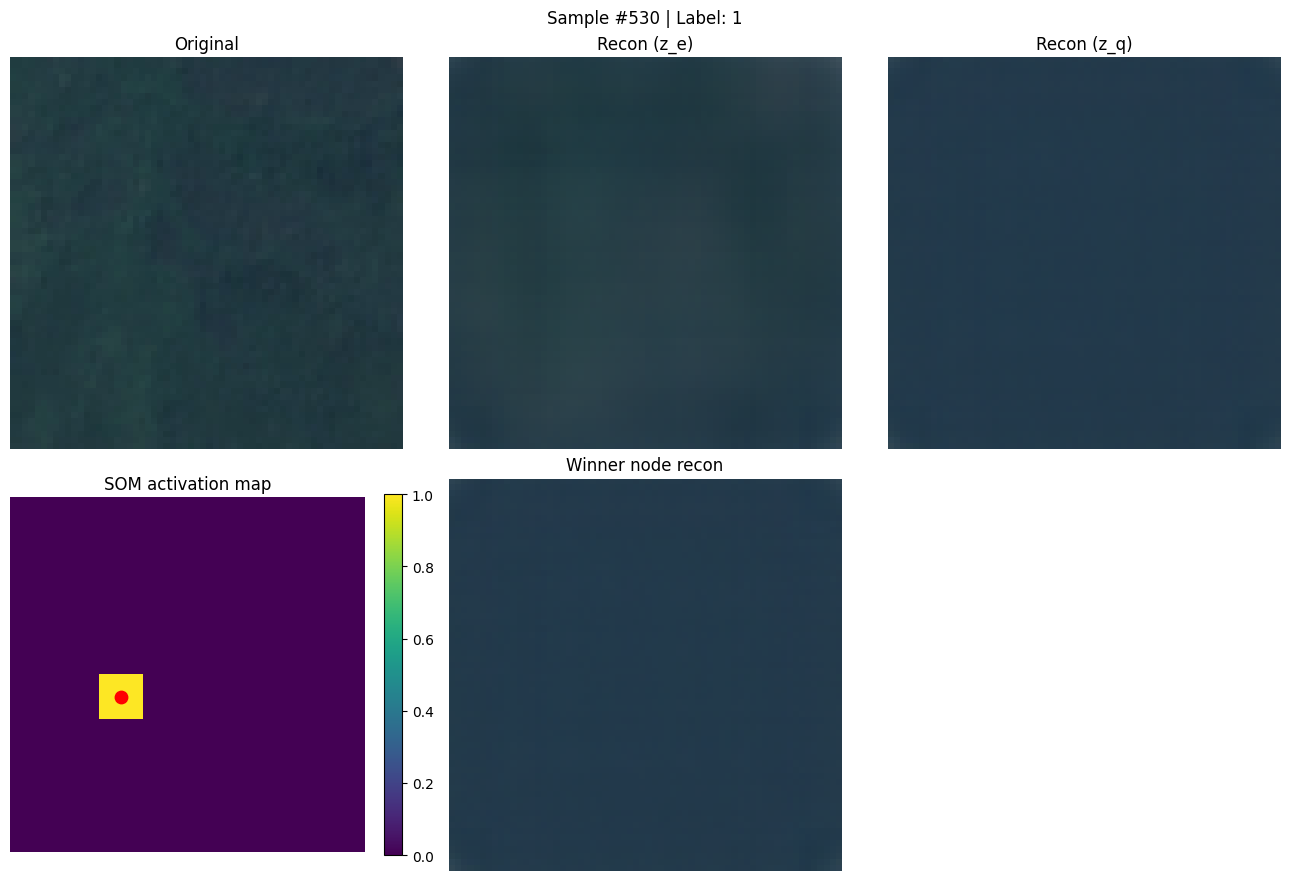

Epoch 43/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 43:
Train: 0.081 | Val: 0.09077271247325941 | NMI: 0.3082


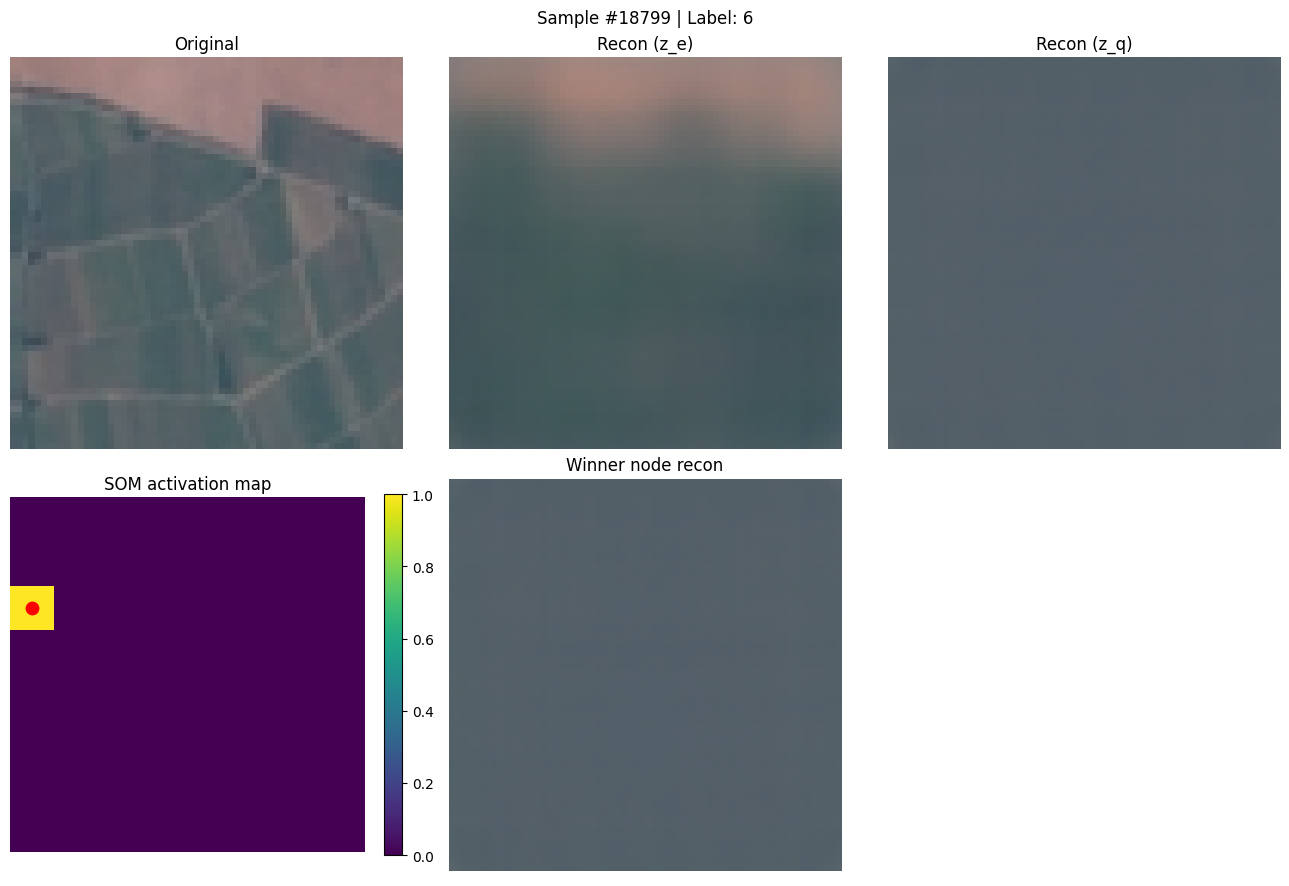

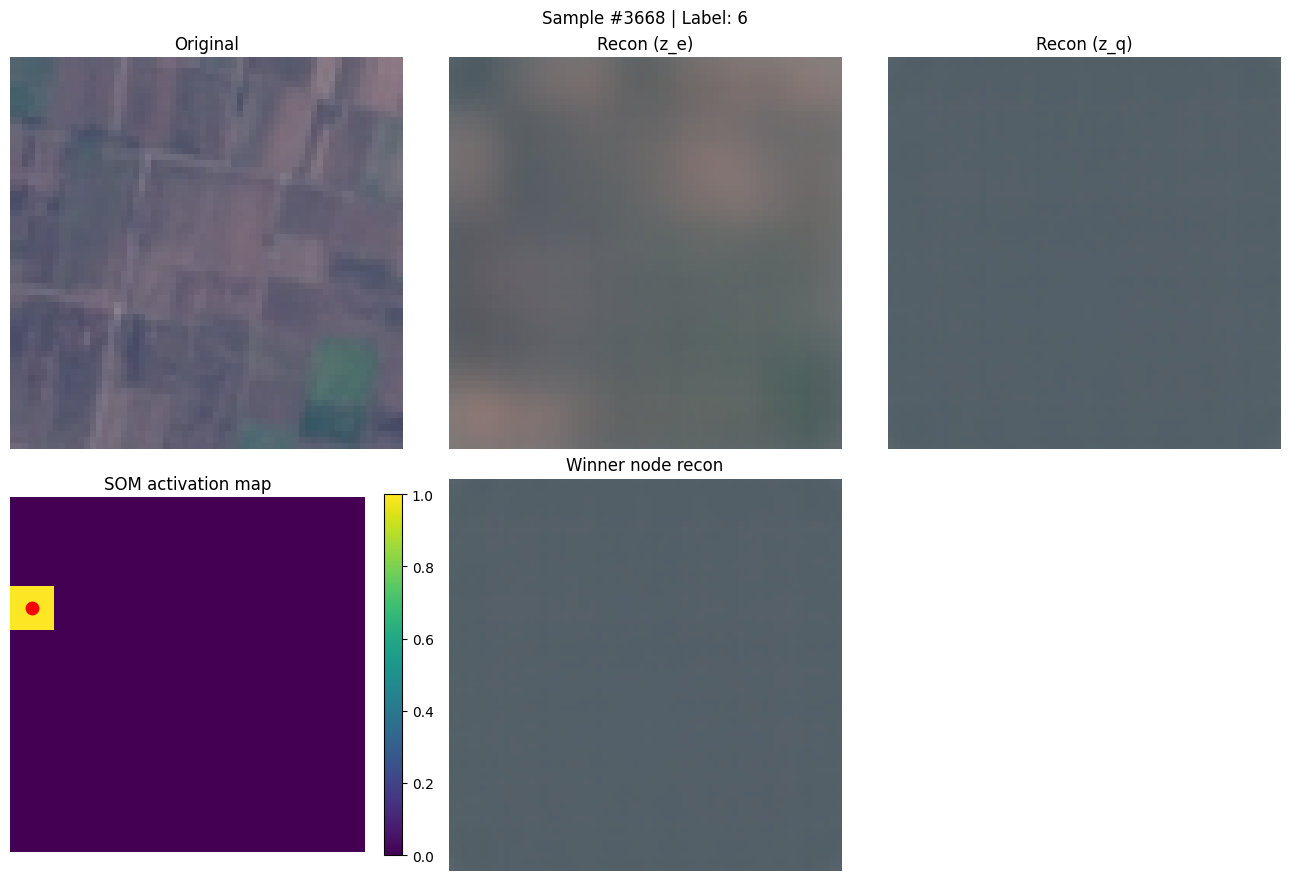

Epoch 44/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 44:
Train: 0.081 | Val: 0.07765761520280394 | NMI: 0.2982


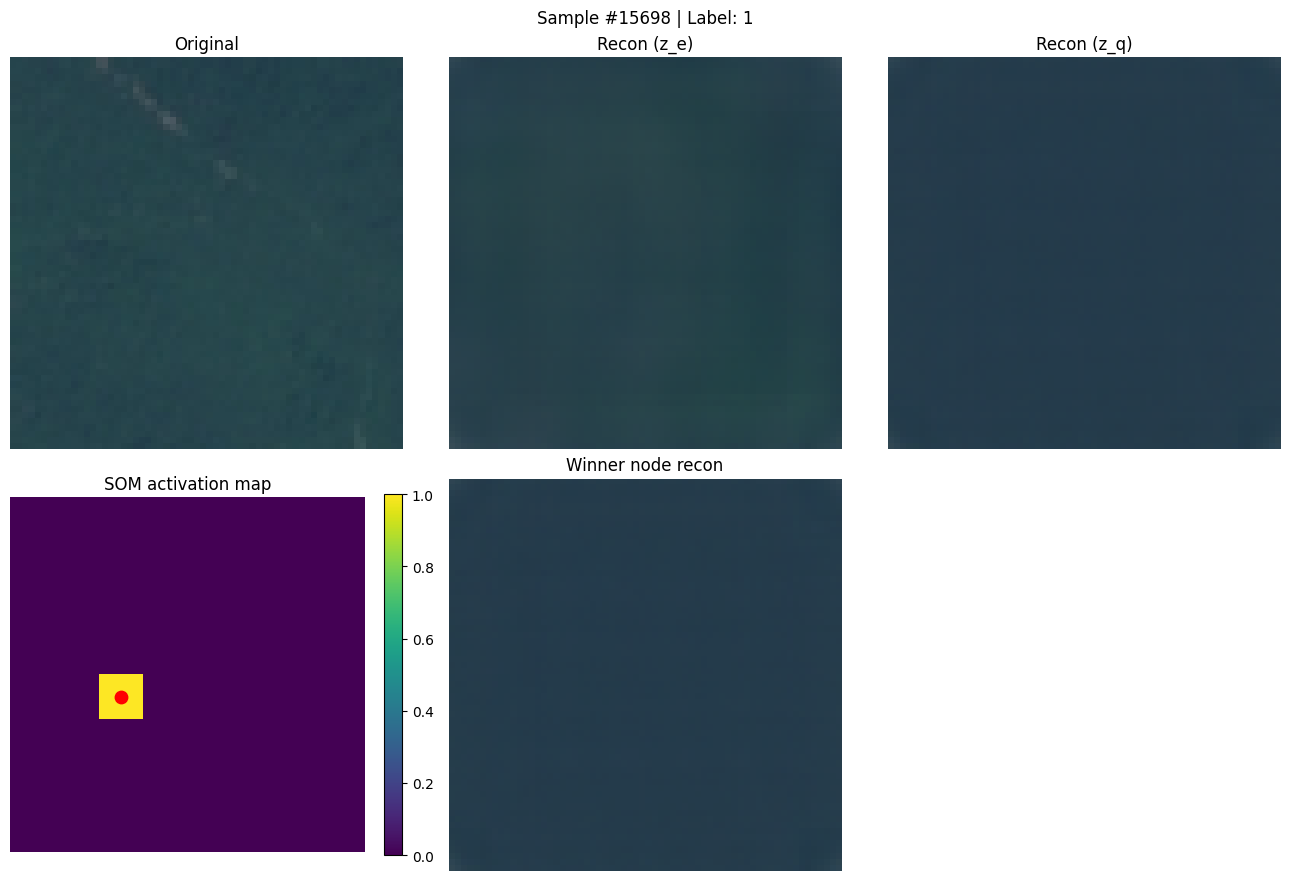

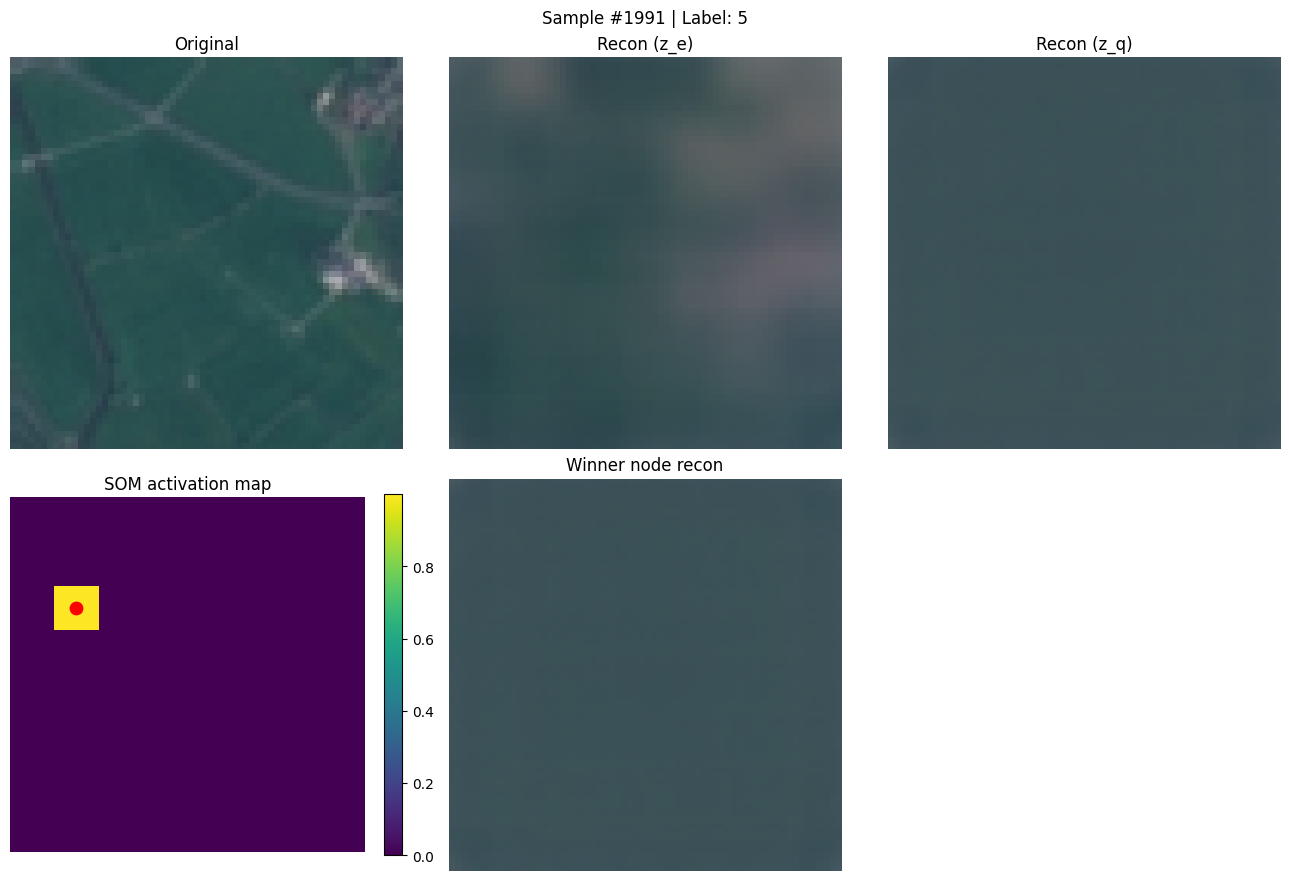

Epoch 45/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 45:
Train: 0.080 | Val: 0.08184069750267406 | NMI: 0.2997


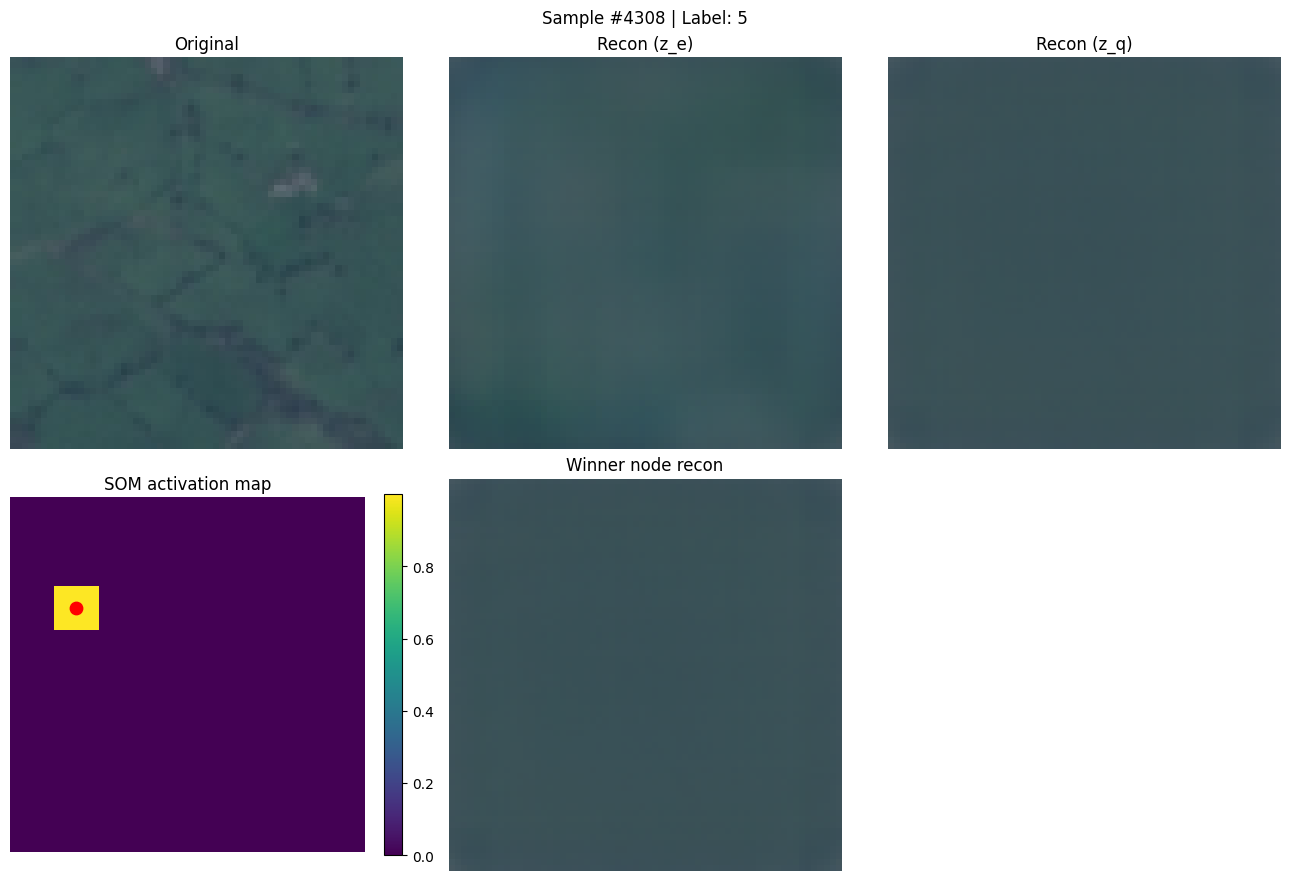

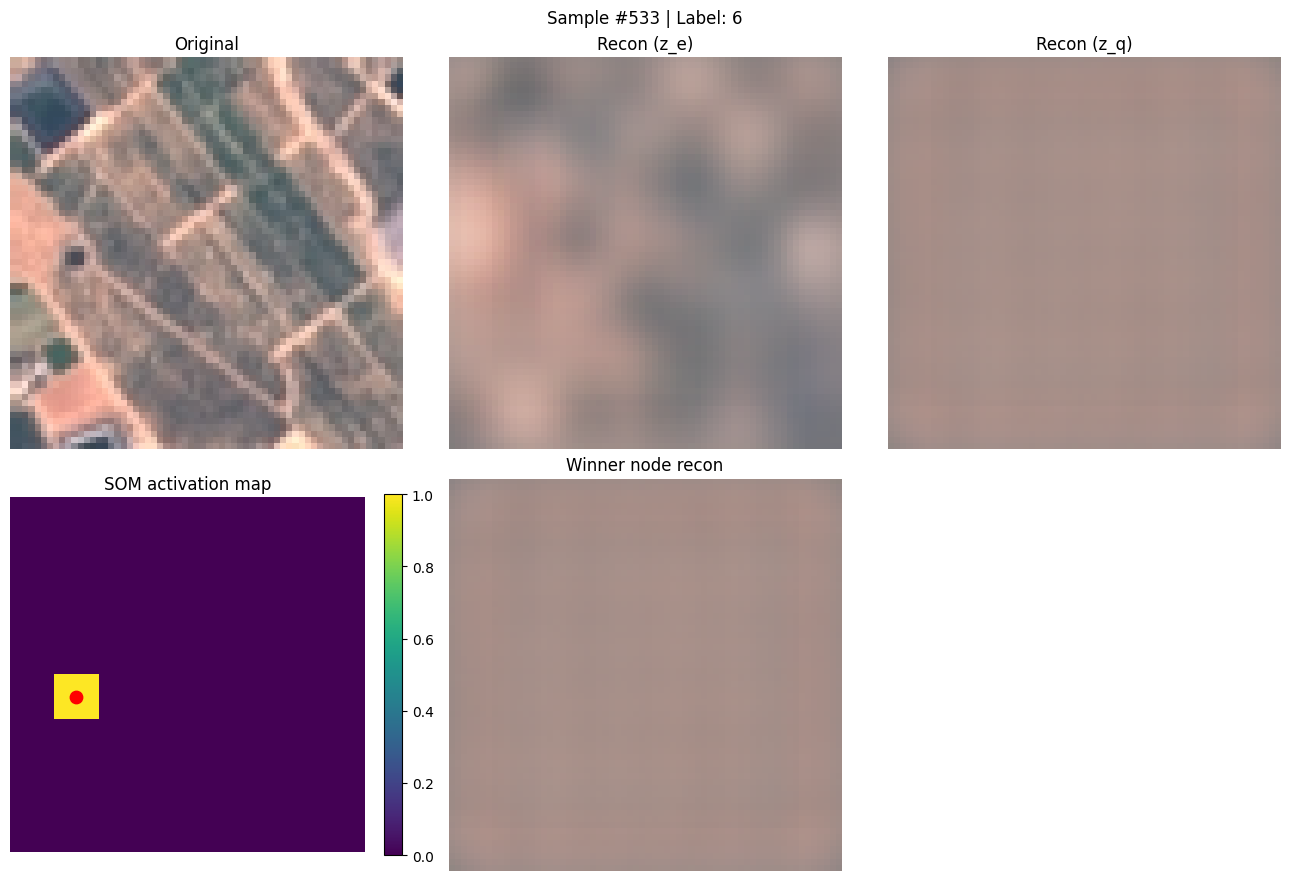

Epoch 46/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 46:
Train: 0.082 | Val: 0.07933913465849189 | NMI: 0.3034


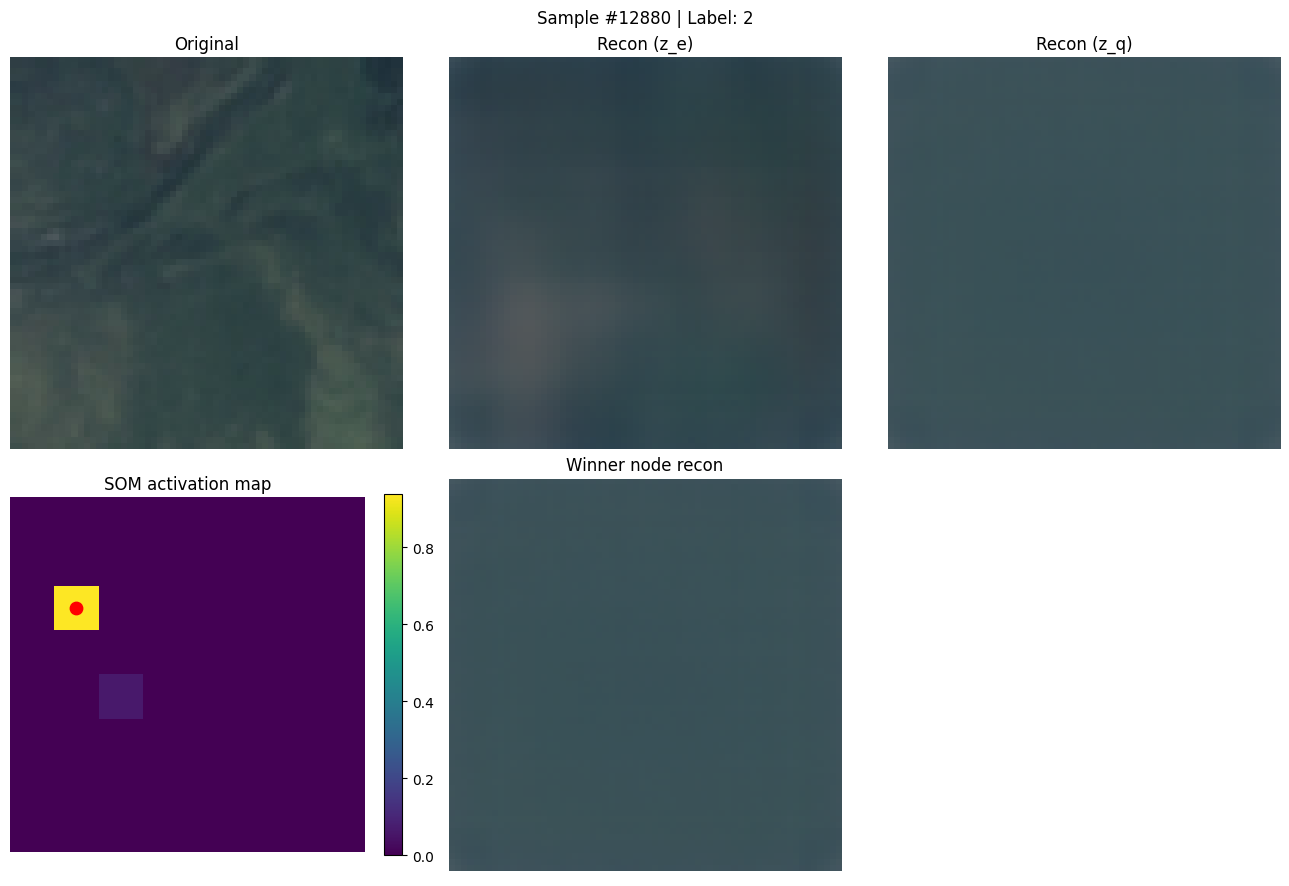

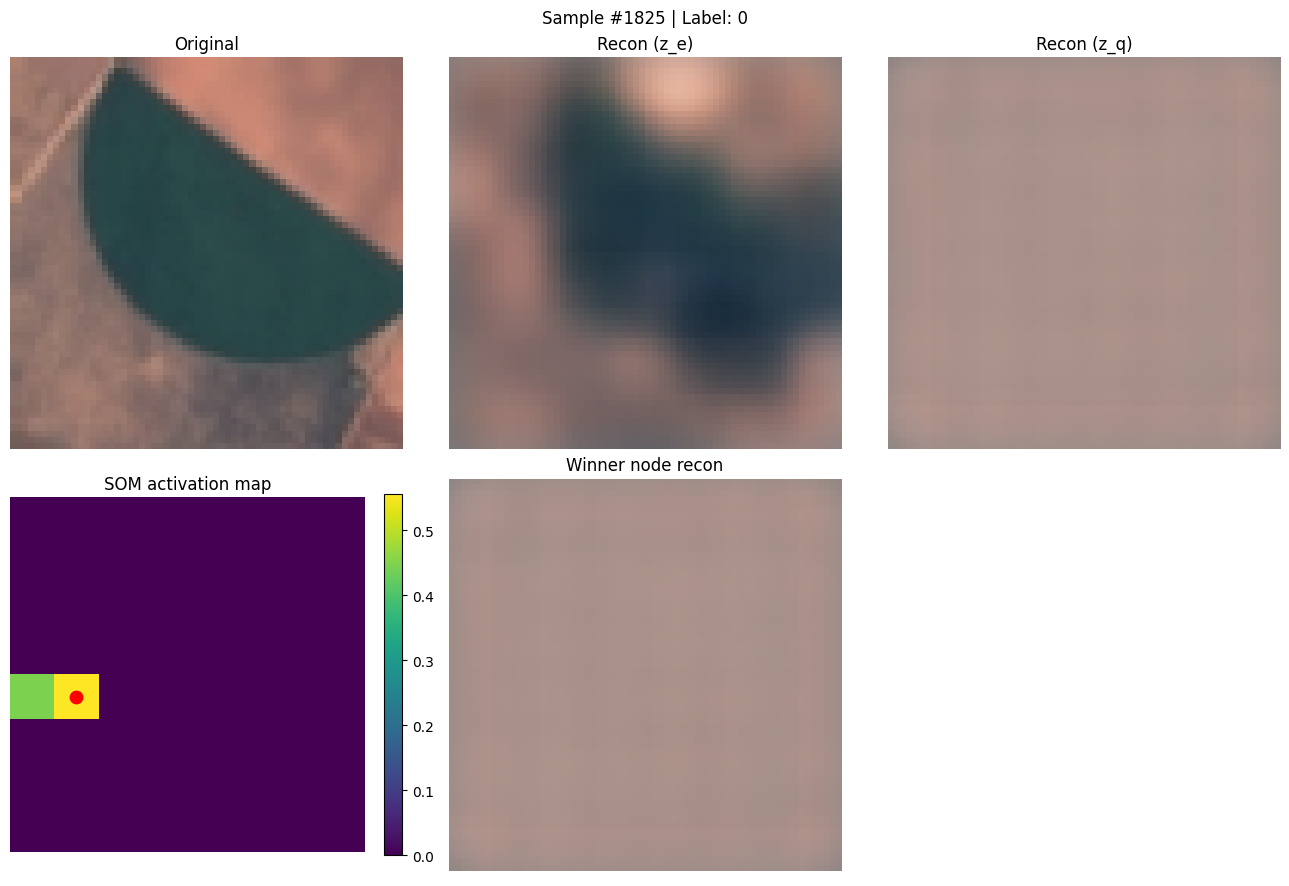

Epoch 47/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 47:
Train: 0.080 | Val: 0.08142461523760197 | NMI: 0.2899


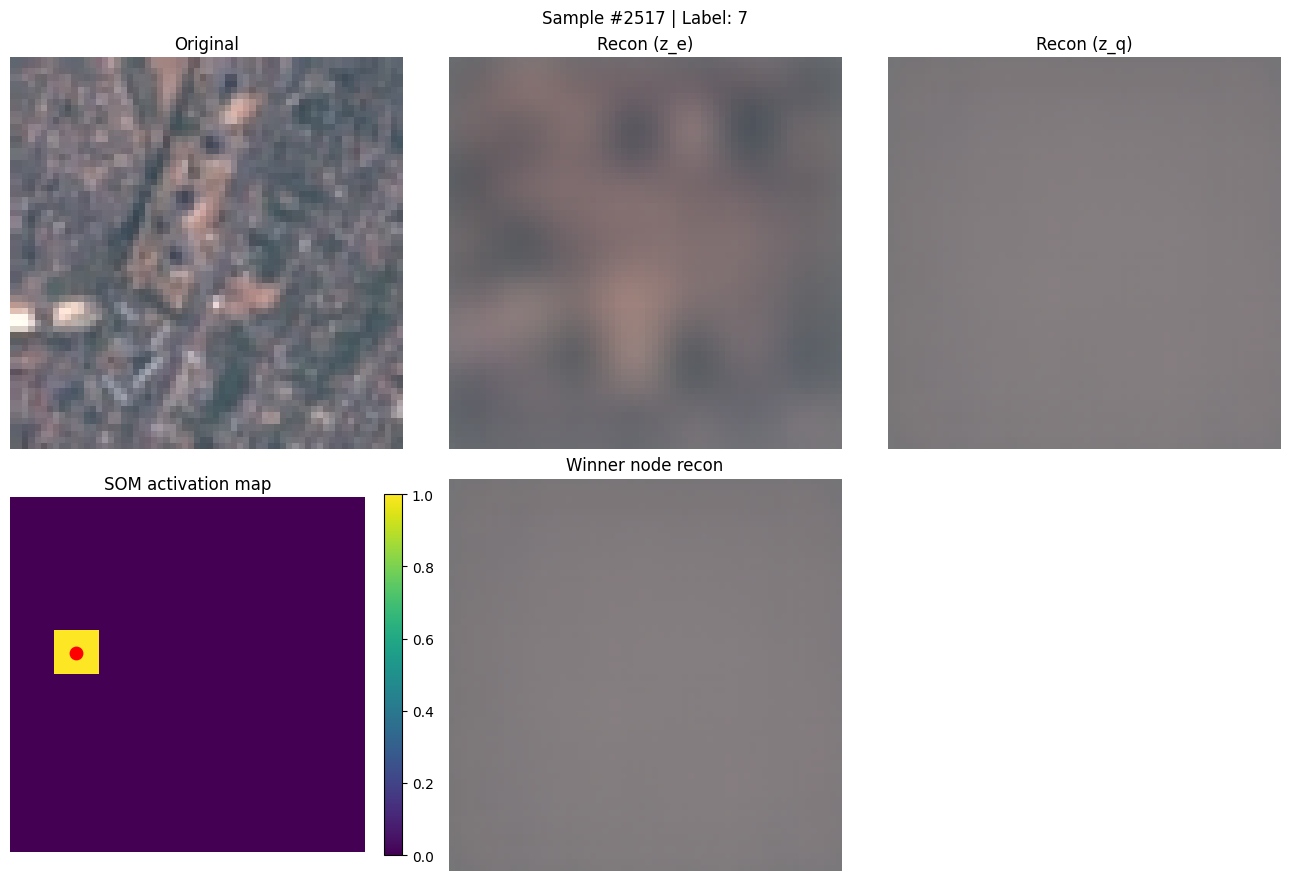

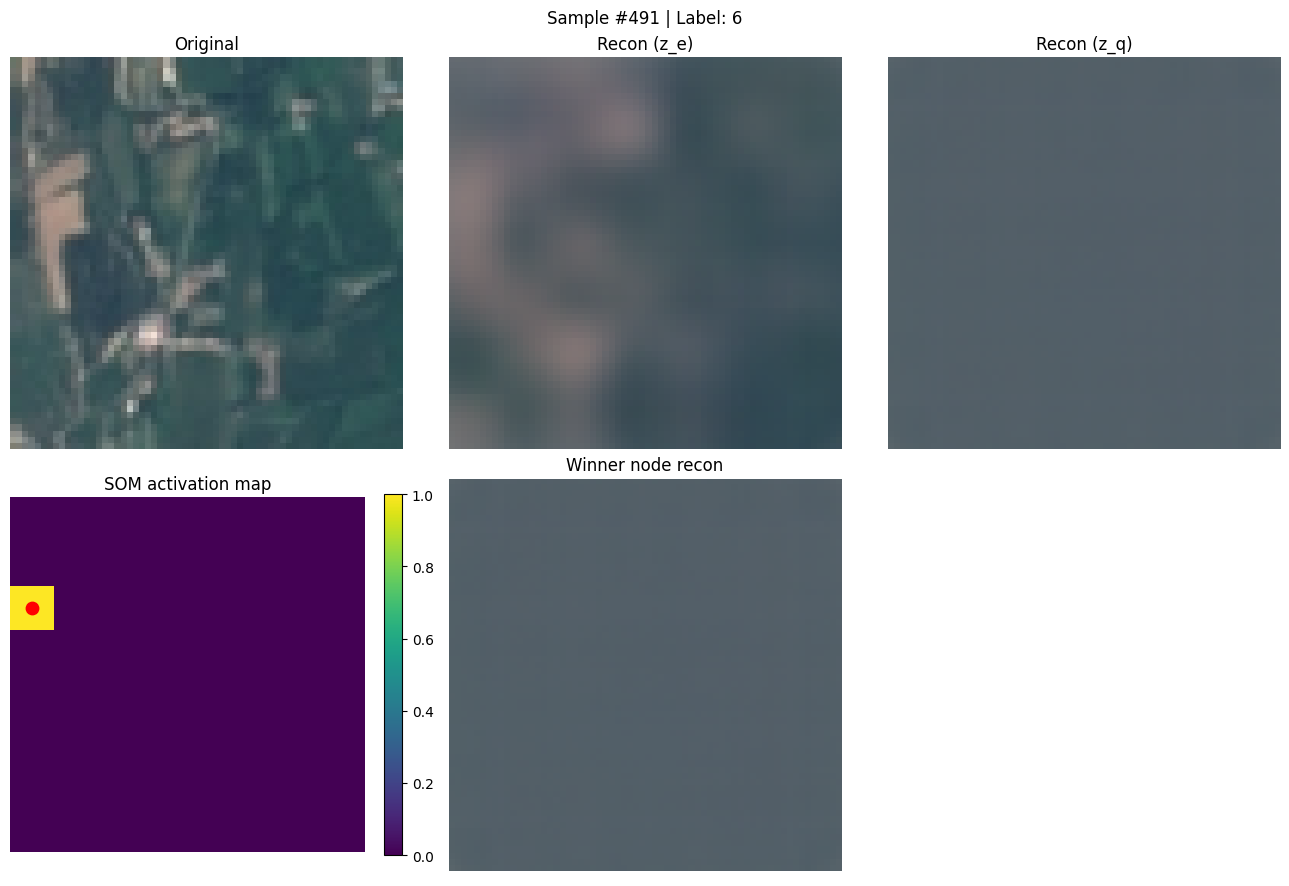

Epoch 48/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 48:
Train: 0.080 | Val: 0.08052755926930627 | NMI: 0.3030


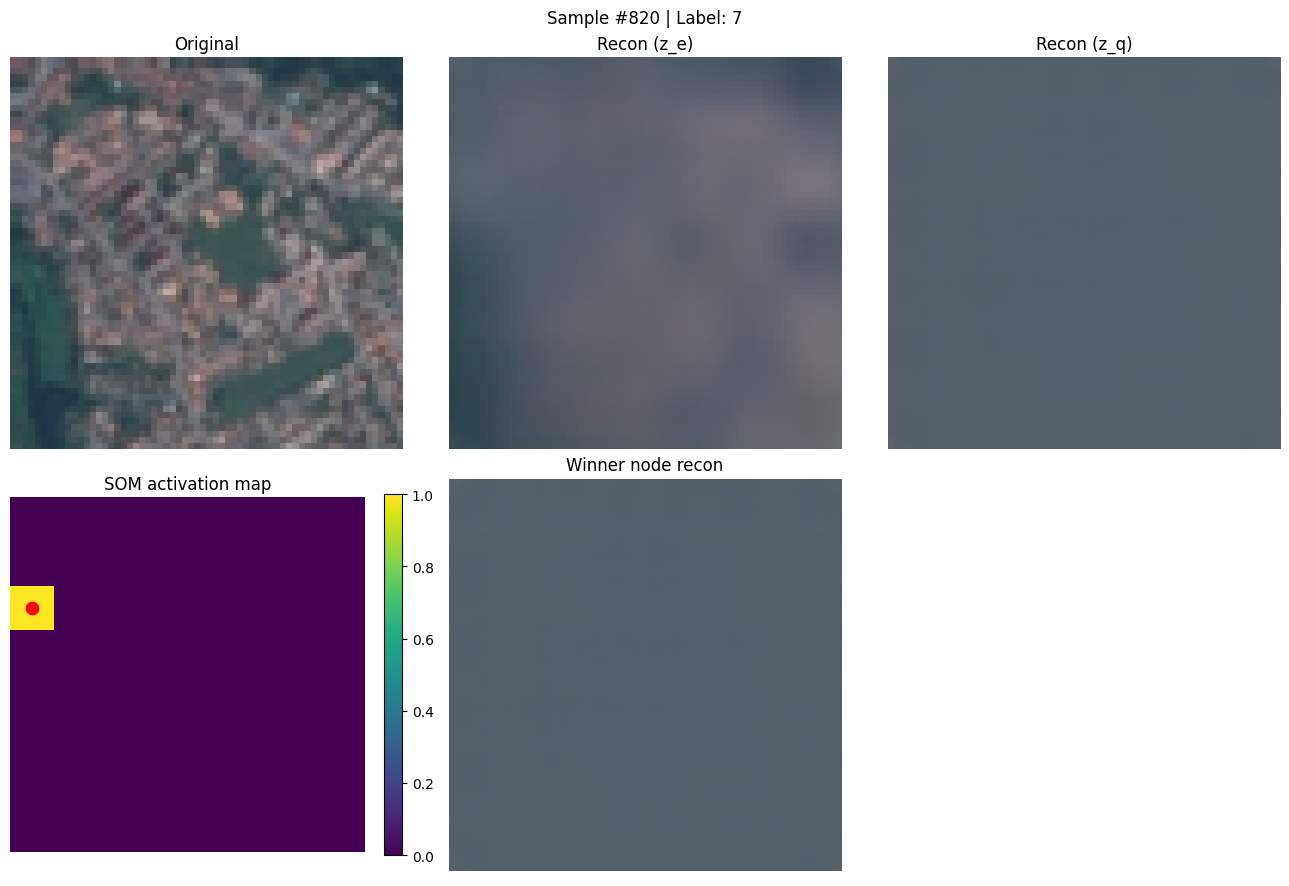

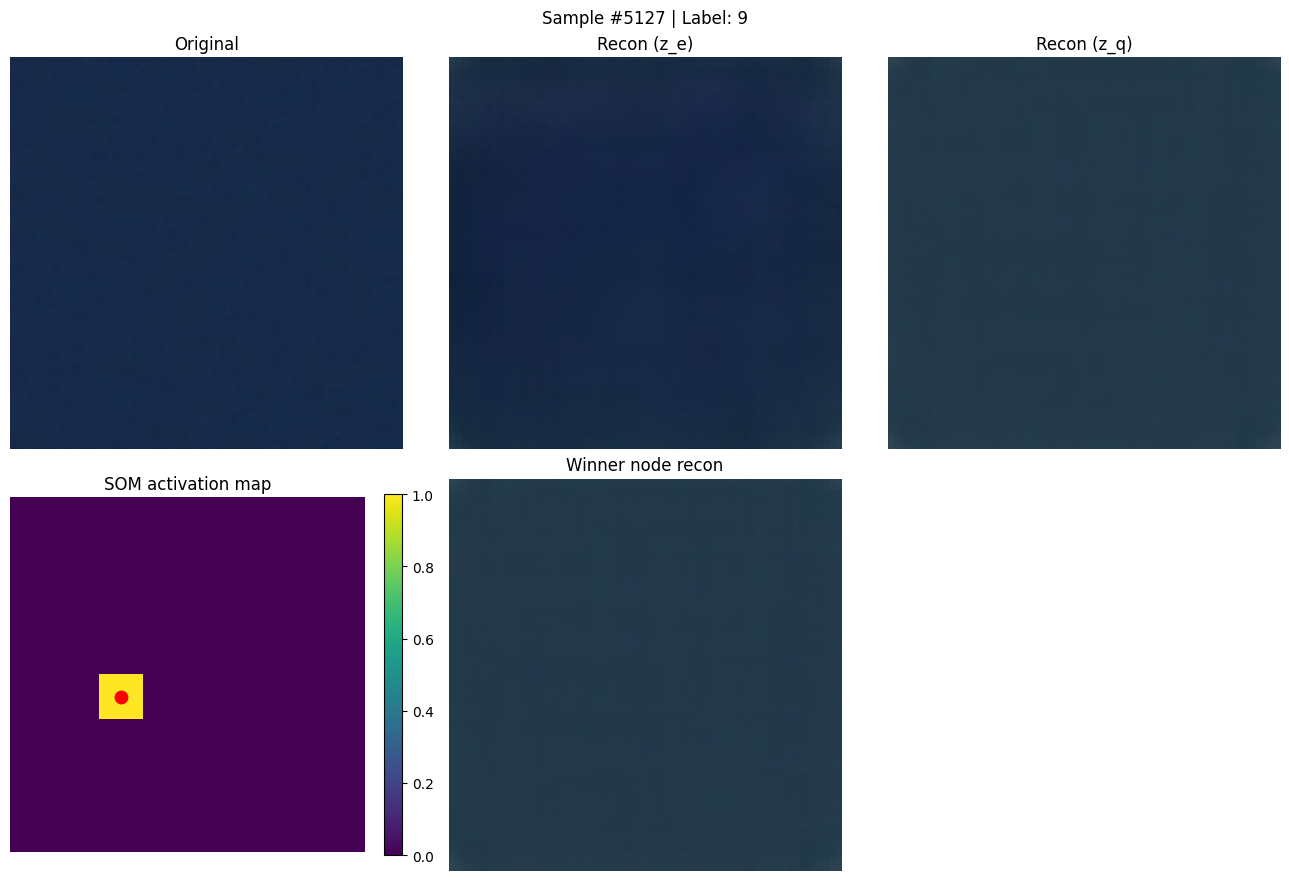

Epoch 49/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 49:
Train: 0.079 | Val: 0.08263715980357902 | NMI: 0.2899


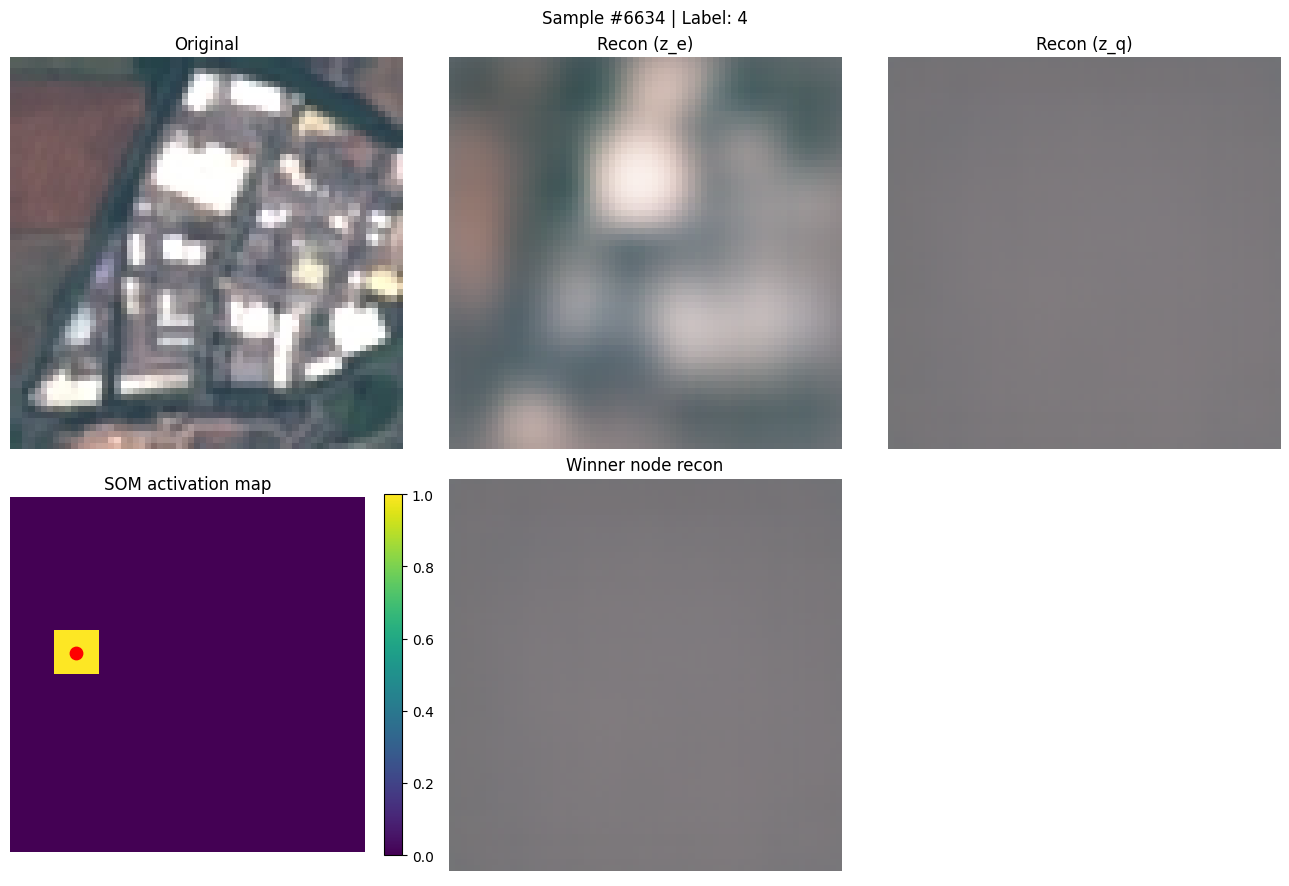

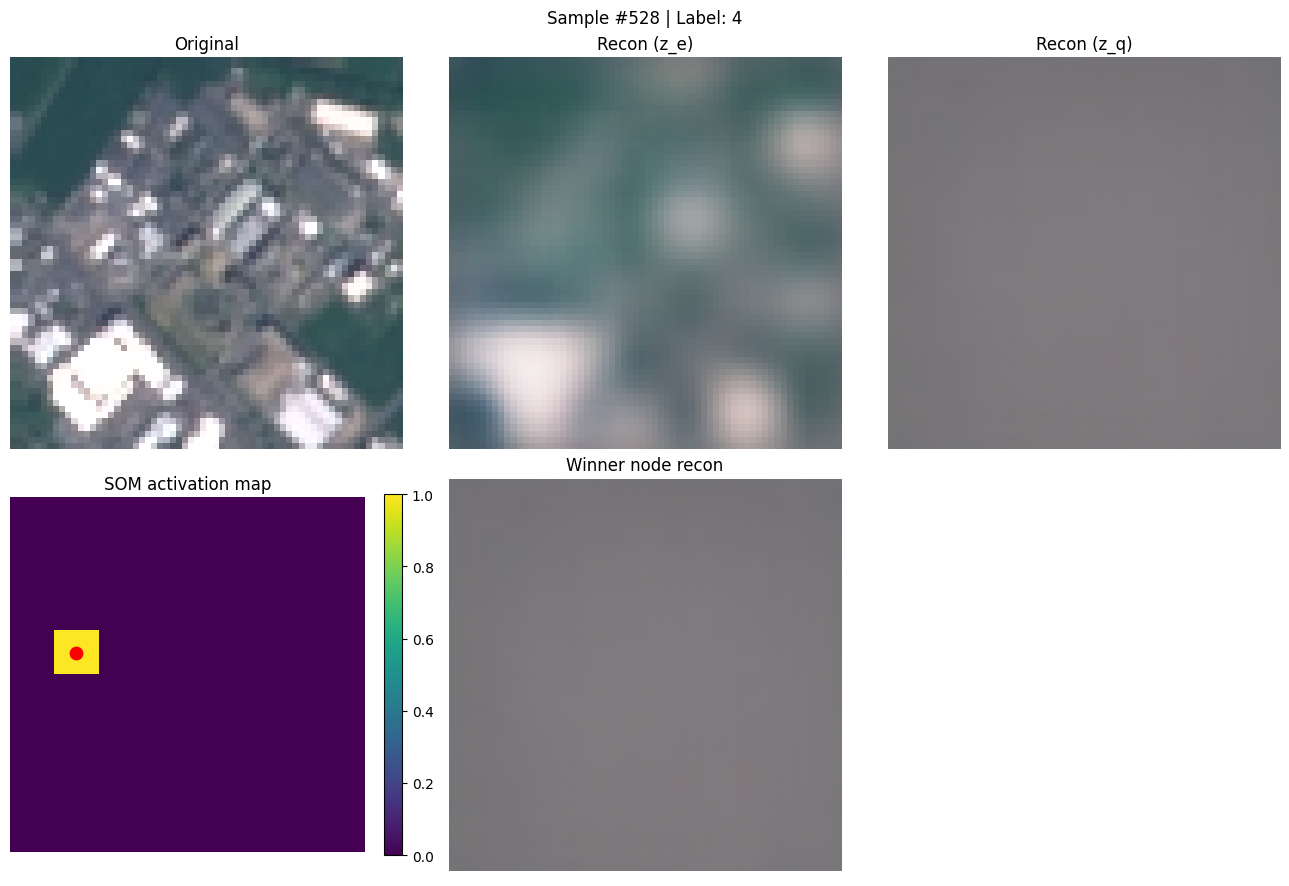

Epoch 50/50 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Summary Epoch 50:
Train: 0.079 | Val: 0.07816973207301872 | NMI: 0.3023


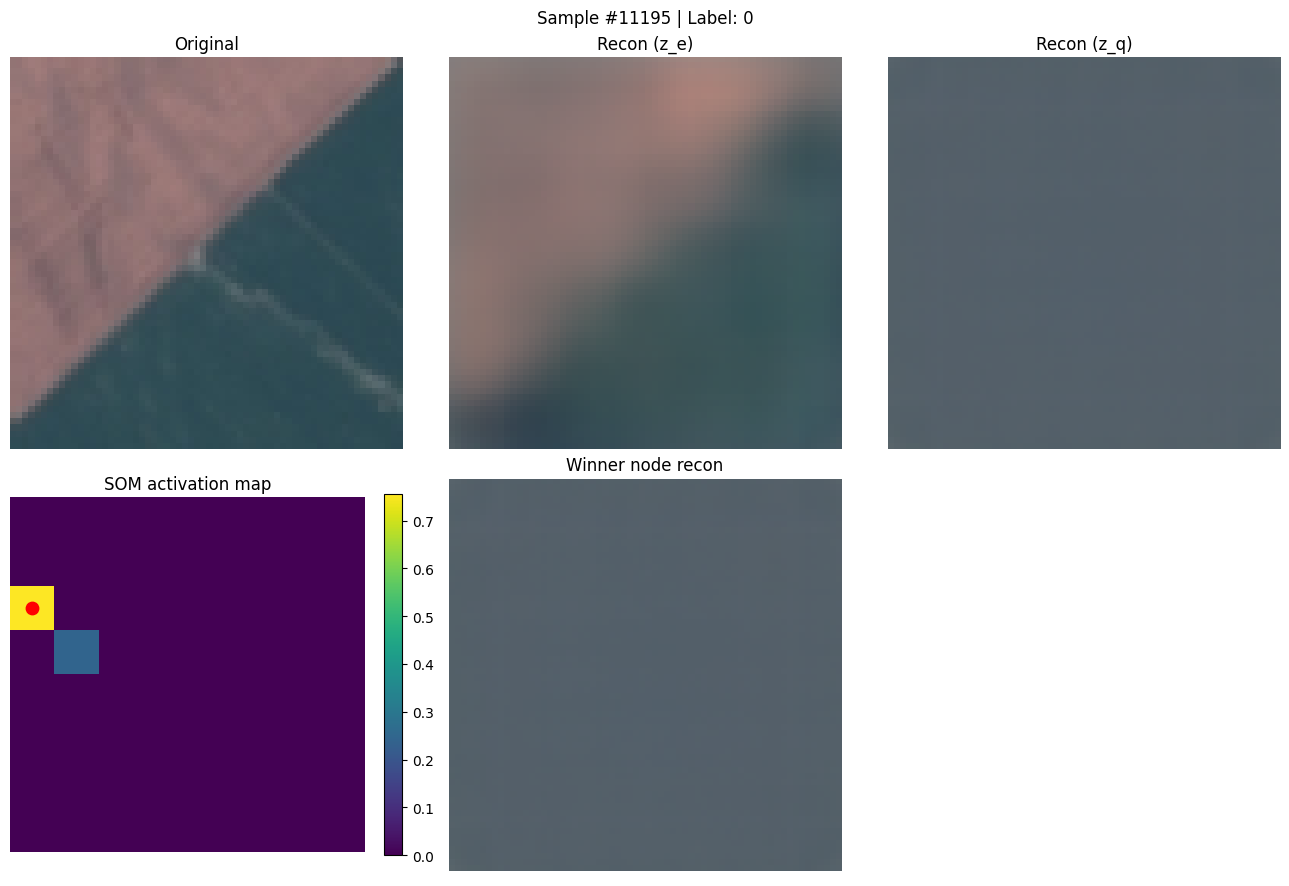

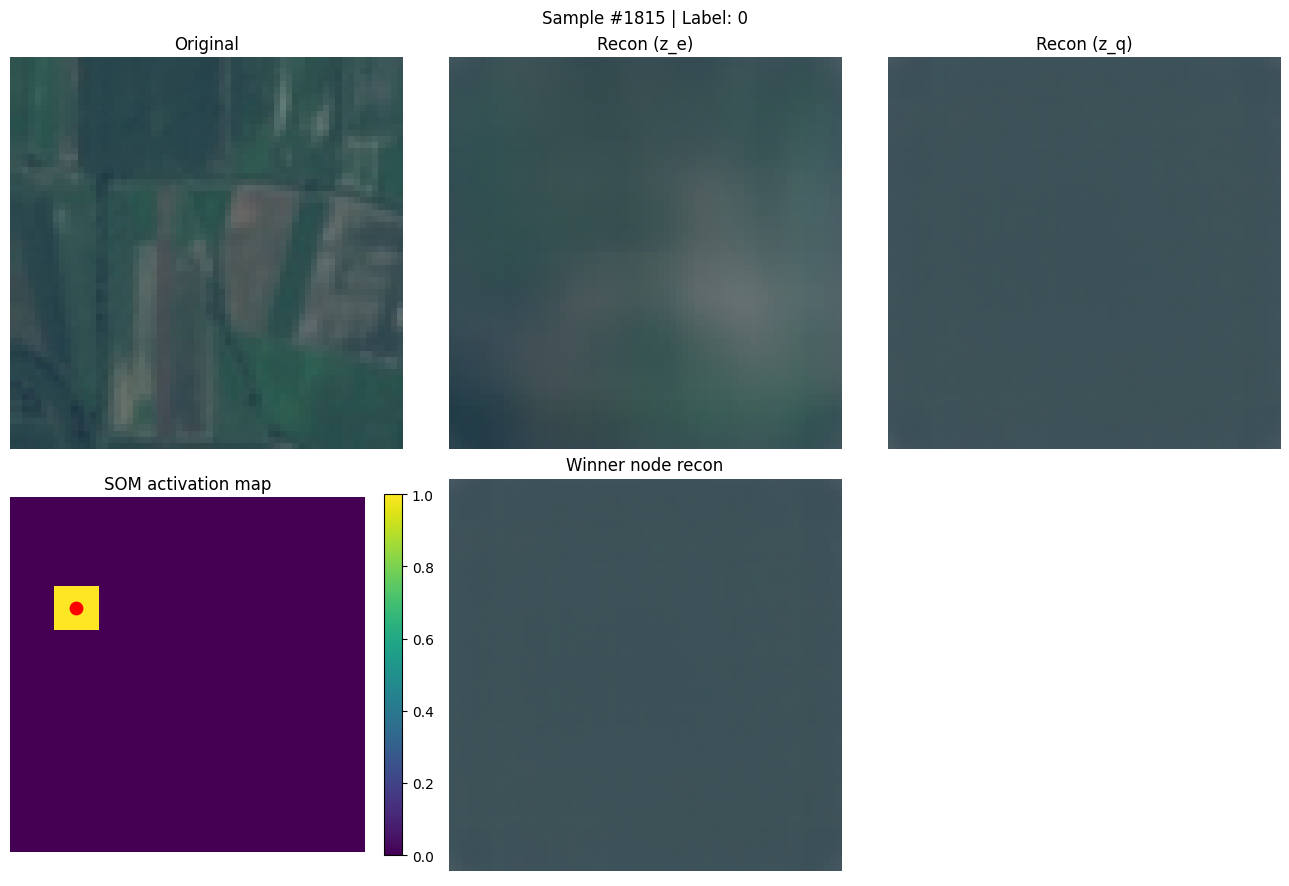

In [18]:
# Запуск обучения
history = train_som_vae(
    model=model, 
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    optimizer=optimizer, 
    device=device, 
    epochs=epochs, 
    batch_size=batch_size, 
    alpha=alpha, 
    beta=beta
)

## Training Results Visualization

KeyError: 'train_acc'

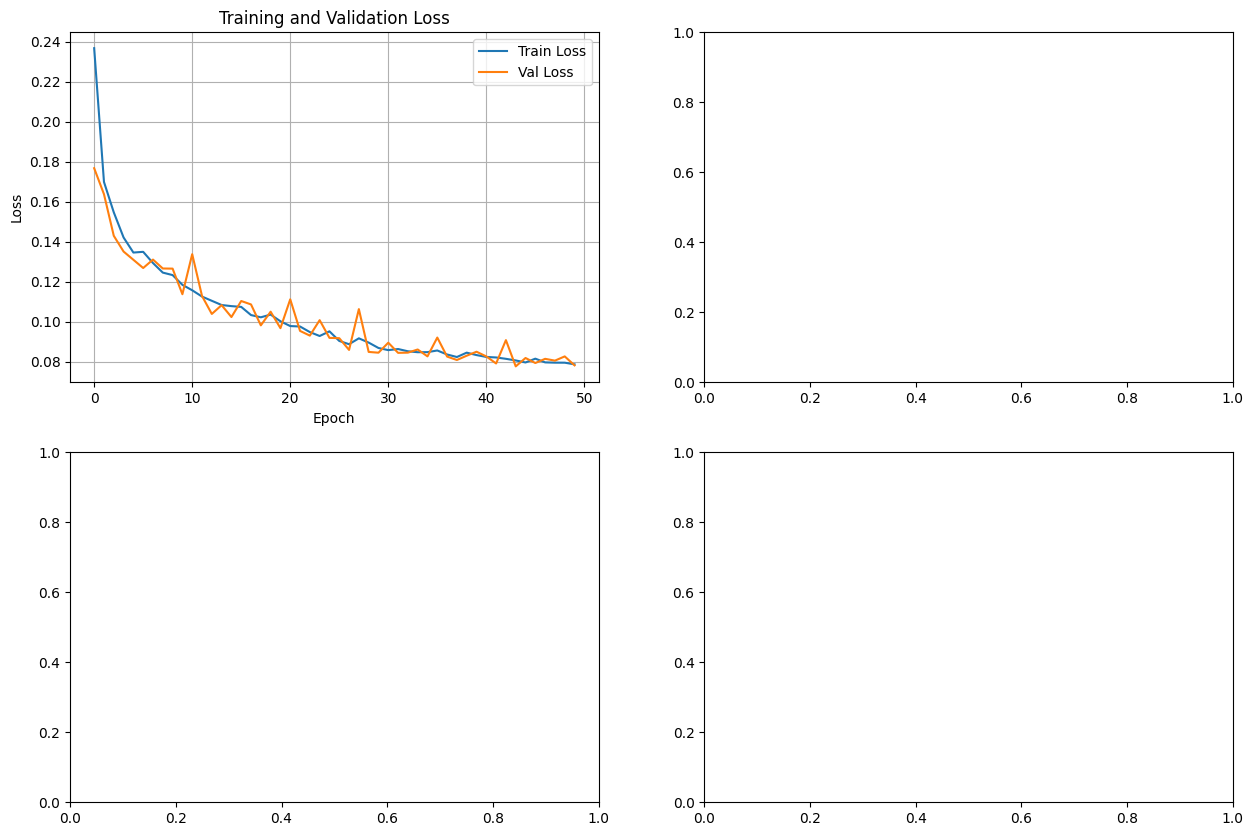

In [19]:
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train Acc')
axes[0, 1].plot(history['val_acc'], label='Val Acc')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True)

# NMI
axes[1, 0].plot(history['nmi'], label='NMI', color='purple')
axes[1, 0].set_title('Normalized Mutual Information')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('NMI Score')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Combined metrics
axes[1, 1].plot(history['val_acc'], label='Val Acc', color='blue')
axes[1, 1].plot(history['nmi'], label='NMI', color='purple')
axes[1, 1].set_title('Validation Metrics')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print(f"Final Results:")
print(f"Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Validation Accuracy: {history['val_acc'][-1]:.2f}%")
print(f"Final NMI: {history['nmi'][-1]:.4f}")

In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

def analyze_latent_similarity(z_e, z_q, show=True):
    """
    z_e, z_q: [1, C, H, W]
    """
    z_e = z_e.detach().cpu()
    z_q = z_q.detach().cpu()

    # --- flatten ---
    ze_flat = z_e.view(1, -1)
    zq_flat = z_q.view(1, -1)

    # --- Метрики ---
    mse = F.mse_loss(z_q, z_e).item()
    l2 = torch.norm(ze_flat - zq_flat, dim=1).item()
    cos = F.cosine_similarity(ze_flat, zq_flat).item()

    # --- Spatial error map ---
    spatial_err = ((z_e - z_q) ** 2).mean(dim=1)[0]  # [H, W]

    # --- Channel-wise error ---
    channel_err = ((z_e - z_q) ** 2).mean(dim=(2, 3))[0]  # [C]

    if show:
        fig, axs = plt.subplots(1, 3, figsize=(14, 4))

        # spatial
        im0 = axs[0].imshow(spatial_err, cmap="inferno")
        axs[0].set_title("Spatial MSE (8×8)")
        plt.colorbar(im0, ax=axs[0])

        # channels
        axs[1].plot(channel_err.numpy())
        axs[1].set_title("Channel-wise MSE")
        axs[1].set_xlabel("Channel")
        axs[1].set_ylabel("Error")

        # summary text
        axs[2].axis("off")
        axs[2].text(0.05, 0.7, f"MSE: {mse:.6f}", fontsize=14)
        axs[2].text(0.05, 0.5, f"L2 norm: {l2:.4f}", fontsize=14)
        axs[2].text(0.05, 0.3, f"Cos sim: {cos:.4f}", fontsize=14)

        plt.tight_layout()
        plt.show()

    return {
        "mse": mse,
        "l2": l2,
        "cosine": cos,
        "spatial_err": spatial_err,
        "channel_err": channel_err
    }

def analyze_random(model, dataset, device="cuda"):
    model.eval()

    # --- 1. Случайный пример ---
    idx = random.randint(0, len(dataset) - 1)

    sample = dataset[idx]
    if isinstance(sample, tuple):
        x = sample[0]
        label = sample[1] if len(sample) > 1 else None
    else:
        x = sample
        label = None

    x = x.unsqueeze(0).to(device)

    # --- 2. Прогон через модель ---
    with torch.no_grad():
        x_hat_e, x_hat_q, z_e, z_q, indices, logits = model(x)

    return analyze_latent_similarity(z_e, z_q)

In [ ]:
analyze_random(model, val_dataset)